In [1]:
import pandas as pd, numpy as np
import itertools
import re
import warnings

import statsmodels.api as sm
import statsmodels.formula.api as smf
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines.statistics import multivariate_logrank_test
from lifelines.statistics import proportional_hazard_test
from linearmodels.panel import PanelOLS
from scipy.stats.mstats import winsorize
from scipy.stats import ks_2samp
from scipy.stats import chi2
from itertools import combinations

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")

## TXT to XLSX

In [4]:
# data = "filename.txt"
# data = pd.read_csv(data, delimiter='|')
# data.to_excel("filename.xlsx",index=False)

## For Creating Final data

In [5]:
# data = pd.read_excel("filname.xlsx")
# data = data.melt(id_vars=["Company Name"], var_name="Year", value_name="variable name").sort_values(by=["Company Name","Year"])
# data["Year"] = pd.to_datetime(data["Year"], errors='coerce').dt.year
# data.to_excel("filename.xlsx", index=False)

In [6]:
# x = ['ICR','Debt','Interest Expense','NPM','PBIT','change in sales','Total Assets']
# for i in x:
#     data = f"txt/{i}.txt"
#     data = pd.read_csv(data, delimiter='|').reset_index()
#     data.columns = data.iloc[4,:]
#     data = data.iloc[6:,1:]
#     data.rename(columns={np.nan:"Company Name"},inplace=True)
#     data = data.melt(id_vars=["Company Name"], var_name="Year", value_name=f"{i}").sort_values(by=["Company Name","Year"])
#     data["Year"] = pd.to_datetime(data["Year"], errors='coerce').dt.year
#     data.to_excel(f"Excel files/final/{i}.xlsx",index=False, engine="openpyxl")

## Processing Data

In [7]:
# Company_Name             = pd.read_excel("Excel Files/final/Company Name.xlsx")
# Interest_Expenses        = pd.read_excel("Excel Files/final/Interest Expense.xlsx")
# Sales                    = pd.read_excel("Excel Files/final/change in sales.xlsx")
# Debt                     = pd.read_excel("Excel Files/final/Debt.xlsx")
# NPM                      = pd.read_excel("Excel Files/final/NPM.xlsx")
# Total_Assets             = pd.read_excel('Excel Files/final/Total Assets.xlsx')
# Prime_Rate               = pd.read_excel("Excel Files/final/Structure of Interest Rates.xlsx",sheet_name="New Format",skiprows=9)
# PBIT                     = pd.read_excel('Excel Files/final/PBIT.xlsx')
# NIC                      = pd.read_excel('Excel Files/final/NIC code.xlsx')
# listing_group            = pd.read_excel('Excel Files/final/listing group.xlsx')
# MC                       = pd.read_excel('Excel Files/final/MV.xlsx')

In [8]:
# #Processing Prime Lending Rate Data

# Prime_Rate = Prime_Rate[[1,7]].rename(columns = {1:"Year",7:"Prime Lending Rate"}).iloc[0:24,].sort_values(by="Year")
# Prime_Rate.loc[0, 'Year'] = '2024-25'
# Prime_Rate['Year'] = Prime_Rate['Year'].str.split('-',expand = True)[0].astype(int)
# Prime_Rate['PLR min'] = Prime_Rate['Prime Lending Rate'].str.split('-',expand = True)[0].astype(float)
# Prime_Rate = Prime_Rate[['Year','PLR min']]

## Creating a Common Dataframe

In [9]:
# years = list(range(2001, 2024))
# data = pd.DataFrame()
# data['Company Name'] = np.tile(Company_Name['Company Name'].values, len(years))
# data['Year'] = np.tile(years, len(data['Company Name']))[:len(data['Company Name'])]
# data = data.sort_values(["Company Name","Year"])

In [10]:
# data = data.merge(NIC, on=['Company Name'],how='left')
# data.drop(['Company Code','NIC code'],axis=1,inplace=True)
# data = data.merge(listing_group, on=['Company Name'],how='left')
# data = data.merge(Prime_Rate, on=[ "Year"], how='left')
# data = data.merge(NPM, on=['Company Name', "Year"], how='left')
# data = data.merge(Sales, on=['Company Name', "Year"], how='left')
# data = data.merge(Interest_Expenses, on=['Company Name', "Year"], how='left')
# data = data.merge(Debt, on=['Company Name', "Year"], how='left')
# data = data.merge(Total_Assets, on =['Company Name','Year'],how='left')
# data = data.merge(PBIT, on =['Company Name','Year'],how='left')
# data = data.merge(MC, on =['Company Name','Year'],how='left')

In [11]:
# data.rename(columns={'three digit NIC code':'NIC code'},inplace=True)

In [12]:
# data.to_csv('Data.csv',index=False)

In [13]:
# data = pd.read_csv('Data.csv')
# data.shape

## Creating Variables

In [14]:
# data.dropna(subset=['NPM', 'Interest Expense','change in sales', 'Debt','Total Assets','PBIT'], how='all',inplace=True)

# data['Avg_Debt']         =  data.groupby("Company Name")['Debt'].transform(lambda x: (x + x.shift(1)) / 2).round(2)
# data['Interest rate']    =  ((data['Interest Expense'] / data['Avg_Debt']) * 100).round(2)
# data['Debt to Assets']   =  (data['Debt'] / data['Total Assets'])
# data['Leverage Median']  =  data.groupby(['NIC code'])['Debt to Assets'].transform('median')
# data['NPM Median']       =  data.groupby(['NIC code'])['NPM'].transform('median')
# data['Debt Growth']      =  data.groupby("Company Name")['Debt'].transform(lambda x: (x - x.shift(1)) / x.shift(1) * 100).round(2)
# data['Sales Growth']     =  data['change in sales']
# data['ICR']              = (data['PBIT'] / data['Interest Expense'])
# data['Interest Gap']         = (data['Interest rate'] - data['PLR min'])
  
# shift_cols = ['ICR', 'NPM', 'Debt to Assets', 'Debt Growth', 
#               'Interest rate','Sales Growth' ,'Leverage Median',"NPM Median",'PLR min']
                            
# for col in shift_cols:
#     data[f'{col} t-1'] = data.groupby("Company Name")[col].shift(1)

# data.shape

In [15]:
# data.to_excel('Final Variable Data.xlsx',index=False)

In [2]:
data = pd.read_csv('Final Variable Data.csv')
data['Year'] = pd.to_datetime(data['Year'], format='%Y').dt.year
data.shape

(507332, 30)

In [3]:
data['Company Name'].nunique()

41235

In [4]:
data.dropna(subset=['NPM', 'Interest Expense','change in sales', 'Debt','Total Assets','PBIT'], how='any',inplace=True)

In [5]:
data['Company Name'].nunique()

30895

In [6]:
data.shape

(288687, 30)

In [7]:
data['EDR'] = (data['PBIT'] / data['Debt'])
data['EDR'].replace([np.inf, -np.inf], np.nan, inplace=True)
data['EDR'] = data['EDR']

## Weak Definition

In [8]:
data['CHK Criteria'] = data.apply(lambda row: 'Zombie' if row['Interest rate'] < row['PLR min'] else 'Healthy', axis=1)
data['ICR Criteria'] = data.apply(lambda row: 'Zombie' if ((row['ICR'] < 1) ) else 'Healthy', axis=1)
data['NPM Criteria'] = data.apply(lambda row: 'Zombie' if ((row['NPM'] < row['NPM Median']) ) else 'Healthy', axis=1)
data['Leverage Criteria'] = data.apply(lambda row:'Zombie' if row['Debt to Assets'] > row['Leverage Median'] else "Healthy", axis=1)
data['Debt Growth Criteria'] = data.apply(lambda row: 'Zombie' if row['Debt Growth'] > 0 else 'Healthy', axis=1)
data['Sales Growth Criteria'] = data.apply(lambda row: 'Zombie' if row['Sales Growth'] < 0 else 'Healthy', axis=1)

In [9]:
Relaxed = data.copy()
Relaxed['Zombie'] = Relaxed.apply(
    lambda row: 'Zombie' if (
        row['Debt Growth Criteria'] == 'Zombie' and
        row['NPM Criteria'] == 'Zombie' and
        row['ICR Criteria'] == 'Zombie' and
        row['Leverage Criteria'] == 'Zombie'
    ) else 'Healthy',axis=1)
Result = Relaxed[['Company Name','Year','Zombie']]

In [10]:
(Result['Zombie']=='Zombie').sum()

26792

In [11]:
x=(Result['Zombie']=='Zombie').sum()
y=(Result['Zombie']).count()
print('% of Zombies in Entire dataset :',round((x/y)*100,2))

% of Zombies in Entire dataset : 9.28


In [12]:
yearly_counts = Result.groupby('Year')['Company Name'].nunique().reset_index(name='Total')
zombie_counts = Result[Result['Zombie'] == 'Zombie'].groupby('Year').size().reset_index(name='Zombie_Count')
yearly_stats = yearly_counts.merge(zombie_counts, on='Year', how='left')
yearly_stats['Zombie_Count'] = yearly_stats['Zombie_Count'].fillna(0).astype(int)
yearly_stats['Zombie_Percentage'] = ((yearly_stats['Zombie_Count'] / yearly_stats['Total']) * 100).round(3)
yearly_stats = yearly_stats.iloc[1:,]
Relaxed_results = yearly_stats
Relaxed_results

,Year,Total,Zombie_Count,Zombie_Percentage
1,2002,5421,920,16.971
2,2003,6457,819,12.684
3,2004,6887,755,10.963
4,2005,7733,682,8.819
5,2006,8390,675,8.045
6,2007,8831,752,8.515
7,2008,9317,1003,10.765
8,2009,9833,874,8.888
9,2010,10227,786,7.686
10,2011,10339,979,9.469


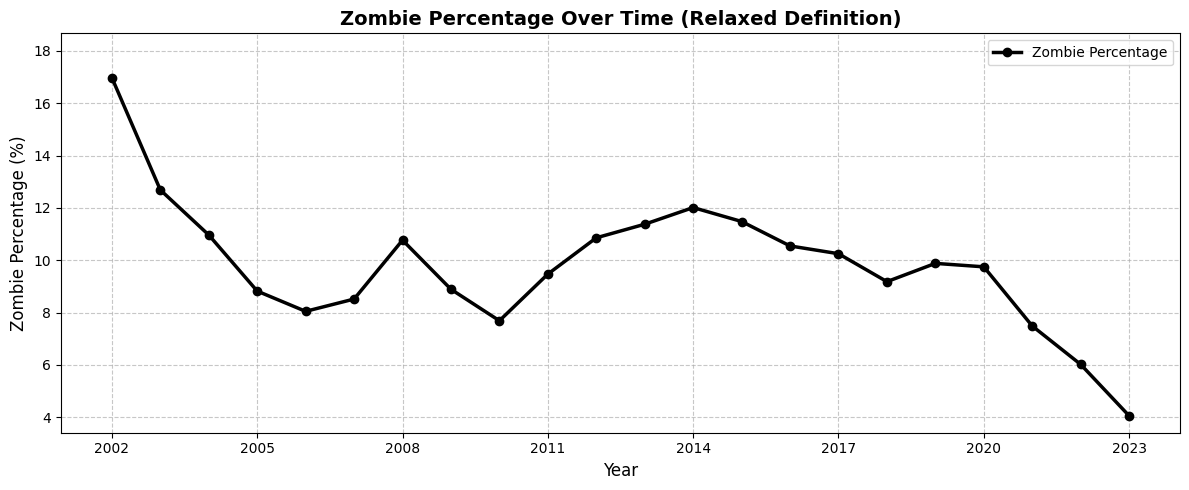

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
# Plot with styling
Relaxed_results.plot(x='Year', y='Zombie_Percentage', ax=ax, linewidth=2.5, marker='o', markersize=6,color='black',legend=False)

# Format x-axis
Relaxed_results['Year'] = Relaxed_results['Year'].astype(int)
ax.set_xticks(Relaxed_results['Year'][::3])
ax.set_xticklabels(Relaxed_results['Year'][::3], rotation=0, fontsize=10)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Y-axis limit and label
y_max = Relaxed_results['Zombie_Percentage'].max()
ax.set_ylim(top=y_max * 1.1)
ax.set_ylabel('Zombie Percentage (%)', fontsize=12)

# Title and x-label
ax.set_title('Zombie Percentage Over Time (Relaxed Definition)', fontsize=14, weight='bold')
ax.set_xlabel('Year', fontsize=12)

# Improve layout and legend
ax.legend(['Zombie Percentage'], loc='upper right', fontsize=10)

# Save with higher quality
plt.tight_layout()
# plt.savefig('Images/Relaxed_Definition_Results.tiff', dpi=1000, bbox_inches='tight')
plt.show()

## Semi-Strong Definition

In [26]:
Semi_Restricted = data.copy()
Semi_Restricted['Zombie'] = Semi_Restricted.apply(
    lambda row: 'Zombie' if (
        row['Debt Growth Criteria'] == 'Zombie' and
        row['Sales Growth Criteria'] == 'Zombie' and
        row['NPM Criteria'] == 'Zombie' and
        row['ICR Criteria'] == 'Zombie' and
        row['Leverage Criteria'] == 'Zombie'
    ) else 'Healthy',axis=1)
Result = Semi_Restricted[['Company Name','Year','Zombie']]

In [27]:
(Result['Zombie']=='Zombie').sum()

12319

In [28]:
x=(Result['Zombie']=='Zombie').sum()
y=(Result['Zombie']).count()
print('% of Zombies in Entire dataset :',round((x/y)*100,2))

% of Zombies in Entire dataset : 4.27


In [29]:
yearly_counts = Result.groupby('Year').size().reset_index(name='Total')
zombie_counts = Result[Result['Zombie'] == 'Zombie'].groupby('Year').size().reset_index(name='Zombie_Count')
yearly_stats = yearly_counts.merge(zombie_counts, on='Year', how='left')
yearly_stats['Zombie_Count'] = yearly_stats['Zombie_Count'].fillna(0).astype(int)
yearly_stats['Zombie_Percentage'] = ((yearly_stats['Zombie_Count'] / yearly_stats['Total']) * 100).round(3)
yearly_stats = yearly_stats.iloc[1:,]
Semi_Restricted_results = yearly_stats
yearly_stats

,Year,Total,Zombie_Count,Zombie_Percentage
1,2002,5421,476,8.781
2,2003,6457,434,6.721
3,2004,6887,308,4.472
4,2005,7733,296,3.828
5,2006,8390,261,3.111
6,2007,8831,305,3.454
7,2008,9317,403,4.325
8,2009,9833,344,3.498
9,2010,10227,275,2.689
10,2011,10339,362,3.501


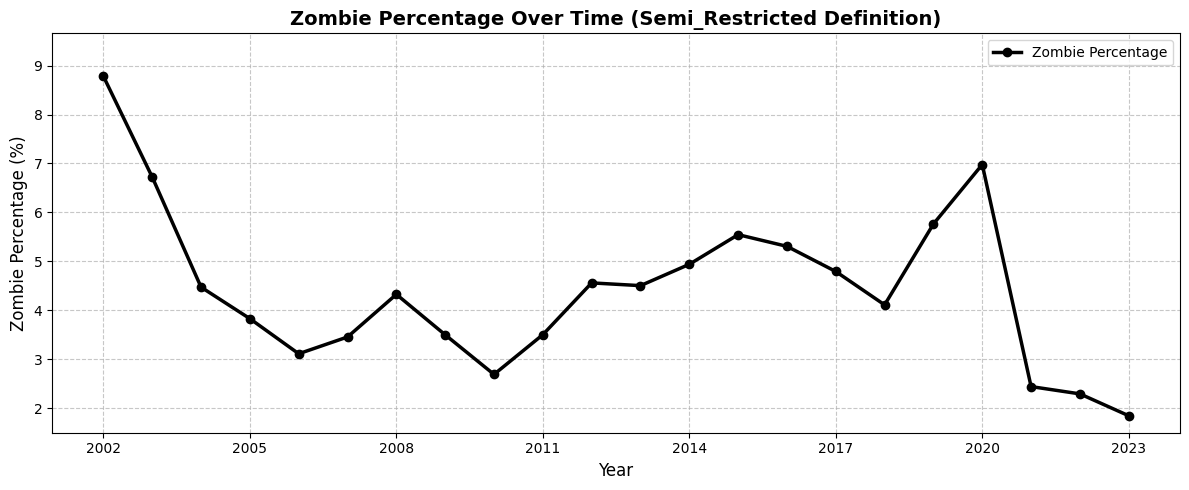

In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
# Plot with styling
Semi_Restricted_results.plot(x='Year', y='Zombie_Percentage', ax=ax, linewidth=2.5, marker='o', markersize=6,color='black',legend=False)

# Format x-axis
Semi_Restricted_results['Year'] = Semi_Restricted_results['Year'].astype(int)
ax.set_xticks(Semi_Restricted_results['Year'][::3])
ax.set_xticklabels(Semi_Restricted_results['Year'][::3], rotation=0, fontsize=10)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Y-axis limit and label
y_max = Semi_Restricted_results['Zombie_Percentage'].max()
ax.set_ylim(top=y_max * 1.1)
ax.set_ylabel('Zombie Percentage (%)', fontsize=12)

# Title and x-label
ax.set_title('Zombie Percentage Over Time (Semi_Restricted Definition)', fontsize=14, weight='bold')
ax.set_xlabel('Year', fontsize=12)

# Improve layout and legend
ax.legend(['Zombie Percentage'], loc='upper right', fontsize=10)

# Save with higher quality
plt.tight_layout()
# plt.savefig('Images/Semi_Restricted_Definition_Results.tiff', dpi=1000, bbox_inches='tight')
plt.show()

## Asha Rai

In [31]:
Asha_Rai = data.copy()
Asha_Rai['Zombie'] = Asha_Rai.apply(
    lambda row: 'Zombie' if (
        row['Debt Growth Criteria'] == 'Zombie' and
        row['ICR Criteria'] == 'Zombie' and
        row['Leverage Criteria'] == 'Zombie'
    ) else 'Healthy',axis=1)
Result = Asha_Rai[['Company Name','Year','Zombie']]

In [32]:
(Result['Zombie']=='Zombie').sum()

27242

In [33]:
x=(Result['Zombie']=='Zombie').sum()
y=(Result['Zombie']).count()
print('% of Zombies in Entire dataset :',round((x/y)*100,2))

% of Zombies in Entire dataset : 9.44


In [34]:
yearly_counts = Result.groupby('Year')['Company Name'].nunique().reset_index(name='Total')
zombie_counts = Result[Result['Zombie'] == 'Zombie'].groupby('Year').size().reset_index(name='Zombie_Count')
yearly_stats = yearly_counts.merge(zombie_counts, on='Year', how='left')
yearly_stats['Zombie_Count'] = yearly_stats['Zombie_Count'].fillna(0).astype(int)
yearly_stats['Zombie_Percentage'] = ((yearly_stats['Zombie_Count'] / yearly_stats['Total']) * 100).round(3)
yearly_stats = yearly_stats.iloc[1:,]
Asha_Rai_results = yearly_stats
Asha_Rai_results

,Year,Total,Zombie_Count,Zombie_Percentage
1,2002,5421,925,17.063
2,2003,6457,824,12.761
3,2004,6887,761,11.050
4,2005,7733,690,8.923
5,2006,8390,686,8.176
6,2007,8831,770,8.719
7,2008,9317,1016,10.905
8,2009,9833,888,9.031
9,2010,10227,804,7.862
10,2011,10339,998,9.653


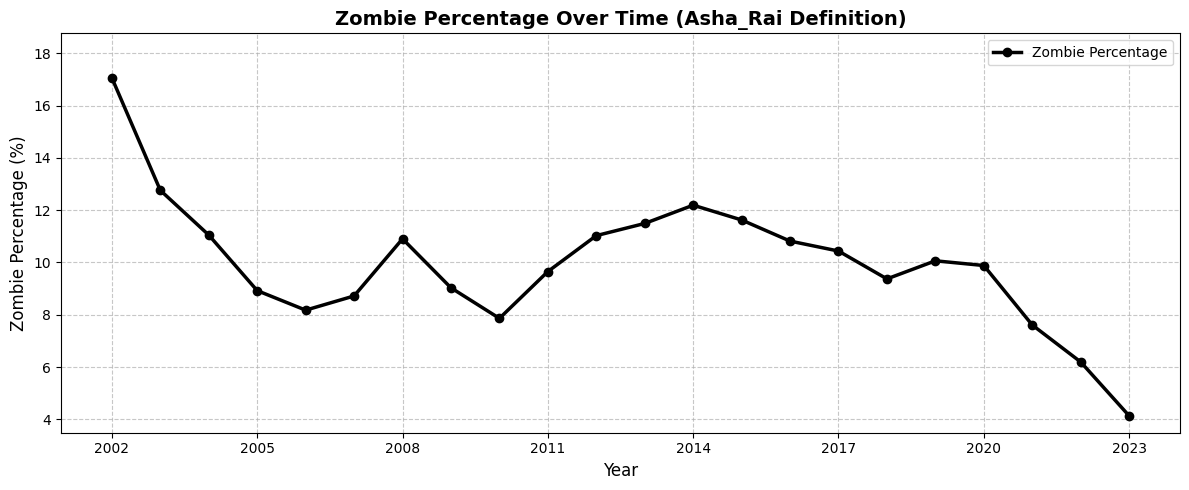

In [35]:
fig, ax = plt.subplots(figsize=(12, 5))
# Plot with styling
Asha_Rai_results.plot(x='Year', y='Zombie_Percentage', ax=ax, linewidth=2.5, marker='o', markersize=6,color='black',legend=False)

# Format x-axis
Asha_Rai_results['Year'] = Asha_Rai_results['Year'].astype(int)
ax.set_xticks(Asha_Rai_results['Year'][::3])
ax.set_xticklabels(Asha_Rai_results['Year'][::3], rotation=0, fontsize=10)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Y-axis limit and label
y_max = Asha_Rai_results['Zombie_Percentage'].max()
ax.set_ylim(top=y_max * 1.1)
ax.set_ylabel('Zombie Percentage (%)', fontsize=12)

# Title and x-label
ax.set_title('Zombie Percentage Over Time (Asha_Rai Definition)', fontsize=14, weight='bold')
ax.set_xlabel('Year', fontsize=12)

# Improve layout and legend
ax.legend(['Zombie Percentage'], loc='upper right', fontsize=10)

# Save with higher quality
plt.tight_layout()
# plt.savefig('Images/Asha_Rai_Definition_Results.tiff', dpi=1000, bbox_inches='tight')
plt.show()

## Strong Definition

In [36]:
data['CHK Criteria'] = data.apply(lambda row: 'Zombie' if ((row['Interest rate'] < row['PLR min'])&(row['Interest rate t-1'] < row['PLR min t-1'])) else 'Healthy', axis=1)
data['ICR Criteria'] = data.apply(lambda row: 'Zombie' if ((row['ICR'] < 1) & (row['ICR t-1'] < 1) ) else 'Healthy', axis=1)
data['Leverage Criteria'] = data.apply(lambda row:'Zombie' if ((row['Debt to Assets'] > row['Leverage Median']) & (row['Debt to Assets t-1'] > row['Leverage Median t-1'])) else "Healthy", axis=1)
data['NPM Criteria'] = data.apply(lambda row: 'Zombie' if ((row['NPM'] < row['NPM Median']) & (row['NPM t-1'] < row['NPM Median t-1']) ) else 'Healthy', axis=1)
data['Debt Growth Criteria'] = data.apply(lambda row: 'Zombie' if ((row['Debt Growth'] > 0) & (row['Debt Growth t-1'] > 0)) else 'Healthy', axis=1)
data['Sales Growth Criteria'] = data.apply(lambda row: 'Zombie' if ((row['Sales Growth'] < 0) & (row['Sales Growth t-1'] < 0)) else 'Healthy', axis=1)

In [37]:
Restricted = data.copy()
Restricted['Zombie'] = Restricted.apply(
    lambda row: 'Zombie' if (
        row['Debt Growth Criteria'] == 'Zombie' and
        row['Sales Growth Criteria'] == 'Zombie' and
        row['NPM Criteria'] == 'Zombie' and
        row['ICR Criteria'] == 'Zombie' and
        row['Leverage Criteria'] == 'Zombie'
    ) else 'Healthy',axis=1)
Result = Restricted[['Company Name','Year','Zombie']]

In [38]:
(Result['Zombie']=='Zombie').sum()

2641

In [39]:
x=(Result['Zombie']=='Zombie').sum()
y=(Result['Zombie']).count()
print('% of Zombies in Entire dataset :',round((x/y)*100,2))

% of Zombies in Entire dataset : 0.91


In [40]:
yearly_counts = Result.groupby('Year').size().reset_index(name='Total')
zombie_counts = Result[Result['Zombie'] == 'Zombie'].groupby('Year').size().reset_index(name='Zombie_Count')
yearly_stats = yearly_counts.merge(zombie_counts, on='Year', how='left')
yearly_stats['Zombie_Percentage'] = ((yearly_stats['Zombie_Count'] / yearly_stats['Total']) * 100).round(3)
yearly_stats = yearly_stats.iloc[1:,]
Restricted_results = yearly_stats
Restricted_results

,Year,Total,Zombie_Count,Zombie_Percentage
1,2002,5421,NaN,NaN
2,2003,6457,138.0,2.137
3,2004,6887,100.0,1.452
4,2005,7733,59.0,0.763
5,2006,8390,56.0,0.667
6,2007,8831,56.0,0.634
7,2008,9317,57.0,0.612
8,2009,9833,63.0,0.641
9,2010,10227,46.0,0.450
10,2011,10339,46.0,0.445


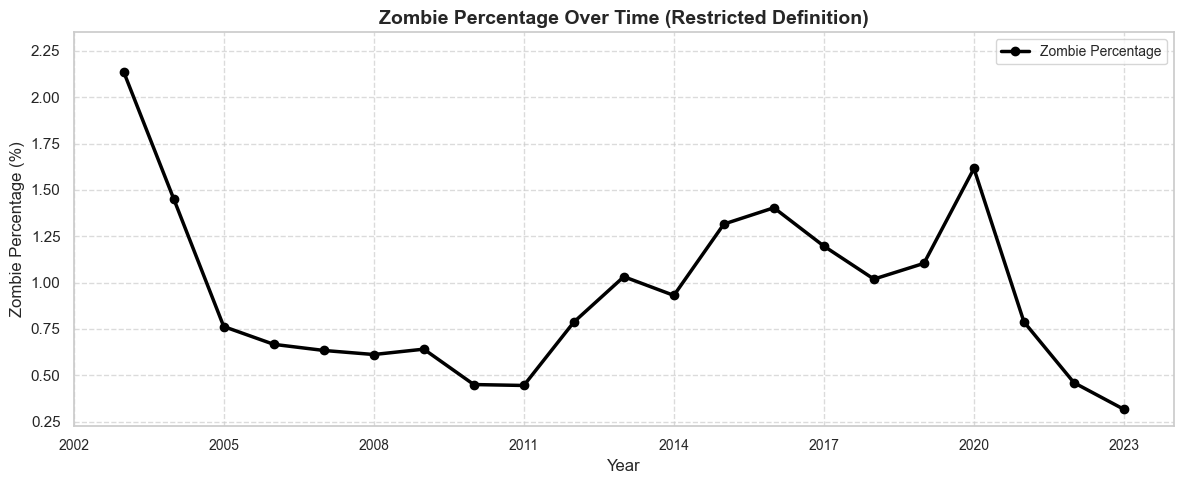

In [178]:
fig, ax = plt.subplots(figsize=(12, 5))
# Plot with styling
Restricted_results.plot(x='Year', y='Zombie_Percentage', ax=ax, linewidth=2.5, marker='o', markersize=6,color='black',legend=False)

# Format x-axis
Restricted_results['Year'] = Restricted_results['Year'].astype(int)
ax.set_xticks(Restricted_results['Year'][::3])
ax.set_xticklabels(Restricted_results['Year'][::3], rotation=0, fontsize=10)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Y-axis limit and label
y_max = Restricted_results['Zombie_Percentage'].max()
ax.set_ylim(top=y_max * 1.1)
ax.set_ylabel('Zombie Percentage (%)', fontsize=12)

# Title and x-label
ax.set_title('Zombie Percentage Over Time (Restricted Definition)', fontsize=14, weight='bold')
ax.set_xlabel('Year', fontsize=12)

# Improve layout and legend
ax.legend(['Zombie Percentage'], loc='upper right', fontsize=10)

# Save with higher quality
plt.tight_layout()
# plt.savefig('Images/Restricted_Definition_Results.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [23]:
crosstab = Relaxed_results[['Year','Zombie_Percentage']]
crosstab.rename(columns={'Zombie_Percentage':'Weak'},inplace=True)
crosstab = crosstab.merge(Semi_Restricted_results[['Year','Zombie_Percentage']],on='Year',how='left')
crosstab.rename(columns={'Zombie_Percentage':'Semi-Strong'},inplace=True)
crosstab = crosstab.merge(Restricted_results[['Year','Zombie_Percentage']],on='Year',how='left')
crosstab.rename(columns={'Zombie_Percentage':'Strong'},inplace=True)
crosstab.to_excel('Crosstab Results.xlsx',index=False)

Exception ignored in: <function ZipFile.__del__ at 0x0000019592BF8860>
Traceback (most recent call last):
  File "C:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\zipfile.py", line 1870, in __del__
    self.close()
  File "C:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\zipfile.py", line 1872, in close
    def close(self):

KeyboardInterrupt: 


NameError: name 'Relaxed_results' is not defined

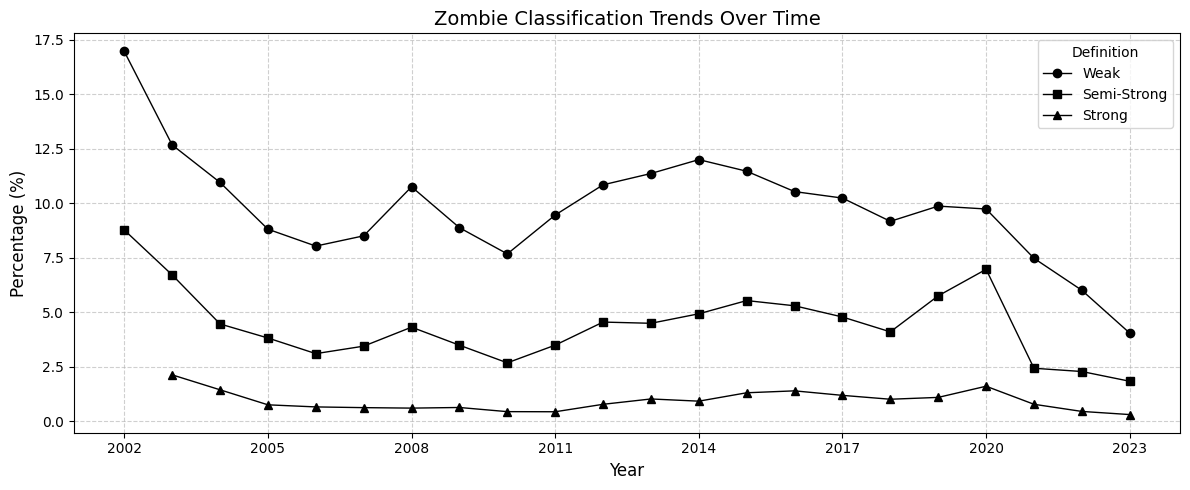

In [43]:
# Convert 'Year' column to integer
crosstab['Year'] = crosstab['Year'].astype(int)

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 5))

# Define marker styles for each category
styles = {
    'Weak': 'o',             # Circle
    'Semi-Strong': 's',     # Square
    'Strong': '^'           # Triangle
}

# Plot each line with black color and unique marker
for category, marker in styles.items():
    ax.plot(crosstab['Year'], crosstab[category],
            color='black', marker=marker, linestyle='-', linewidth=1,
            markersize=6, label=category)

# Format x-axis
ax.set_xticks(crosstab['Year'][::3])
ax.set_xticklabels(crosstab['Year'][::3], rotation=0, fontsize=10)

# Add grid
ax.grid(True, linestyle='--', alpha=0.6)

# Set labels and title
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_title('Zombie Classification Trends Over Time', fontsize=14)

# Add legend with custom font size
ax.legend(loc='upper right', fontsize=10, title="Definition")

# Save and show
plt.tight_layout()
plt.savefig('Images/Crosstab_Results.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [44]:
data['Weak']          = Relaxed['Zombie']
data['Semi_Strong']  = Semi_Restricted['Zombie']
data['Strong']       = Restricted['Zombie']

## Objective 2 - Sources of Funds

## Processing Debt Data

In [45]:
# df = "txt/final/Borrowings.txt"
# df = pd.read_csv(df, delimiter='|',skiprows=4)
# df = df.iloc[:,1:]
# df.iloc[0,0] = np.nan

# #Extract metadata rows and actual data
# periods = df.iloc[0, 1:].values         # Row 0, excluding first column
# borrow_types = df.iloc[1, 1:].values    # Row 1, excluding first column

# #Slice the actual data starting from row 2
# data = df.iloc[2:, :].reset_index(drop=True)
# data.columns = ['Company Name'] + [f'col_{i}' for i in range(1, len(data.columns))]

# # Melt the DataFrame to long format
# data_long = data.melt(id_vars='Company Name', var_name='col_index', value_name='Value')

# # Add 'Period' and 'Borrowing Type' using the original row info
# data_long['Period'] = data_long['col_index'].str.extract(r'(\d+)').astype(int)[0].apply(lambda x: periods[x-1])
# data_long['Borrowing Type'] = data_long['col_index'].str.extract(r'(\d+)').astype(int)[0].apply(lambda x: borrow_types[x-1])

# # Extract Year from Period (e.g., "Dec 2024" → 2024)
# data_long['Year'] = data_long['Period'].str.extract(r'(\d{4})')

# # Pivot to wide format
# reshaped = data_long.pivot_table(index=['Company Name', 'Year'],
#                                   columns='Borrowing Type',
#                                   values='Value',
#                                   aggfunc='first').reset_index()

# # Clean up
# reshaped.columns.name = None  # Remove pivot level name
# reshaped.columns = [re.sub(r'\s*\(Old Sch\. VI\)', '', col) if isinstance(col, str) else col for col in reshaped.columns]

In [46]:
# reshaped.to_excel('Borrowings Data.xlsx',index=False)

In [47]:
Debt_data     = pd.read_excel('Borrowings Data.xlsx')
Debt_data     = Debt_data.merge(data[['Company Name','Year','Weak','Semi_Strong']],on=['Company Name','Year'],how='left')
Debt_data_Semi_Restricted = Debt_data.groupby("Company Name").filter(lambda x: not all(x["Semi_Strong"] == "Healthy"))

In [48]:
zombie_years = Debt_data[Debt_data['Semi_Strong'] == 'Zombie']

zombie_years_prev = zombie_years.copy()
zombie_years_prev['Year'] = zombie_years_prev['Year'] - 1

zombie_and_prev_years = pd.concat([zombie_years, zombie_years_prev]).drop_duplicates(subset=['Company Name', 'Year'])

Debt_data_Semi_Restricted = Debt_data.merge(
    zombie_and_prev_years[['Company Name', 'Year']],
    on=['Company Name', 'Year'],
    how='inner'
)

In [49]:
# zombie_firms = Debt_data_Semi_Restricted
# zombie_firms = zombie_firms[(zombie_firms['Year'] > 2001) & (zombie_firms['Year'] < 2024)]

# # Group by Year and calculate the mean for each borrowing type
# category_share = zombie_firms.groupby('Year')[['Borrowing from banks', 'Borrowing from financial institutions', 
#     'Borrowings syndicated across banks & institutions','Borrowings from RBI', 'Borrowings from central & state govt', 
#     'Inter-corporate loans','Loans from promoters, directors and shareholders','Deferred credit', 'Sub-ordinated debt']].mean()

# # Normalize to get the percentage contribution of each borrowing type
# category_share_percentage = category_share.div(category_share.sum(axis=1), axis=0) * 100

# # Create the 100% stacked bar plot
# category_share_percentage.plot(kind='bar', stacked=True, figsize=(20, 7))

# # Set title and labels
# plt.title("Annual Borrowing Contribution to Zombie Firms")
# plt.ylabel("Percentage Contribution (%)")
# plt.xlabel("Year")

# # Customize legend
# plt.legend(
#     bbox_to_anchor=(0.5, -0.25), 
#     loc='center', 
#     ncol=5, 
#     labels=['Borrowing from banks','Borrowing from financial institutions', 'Borrowings syndicated across banks & institutions',
#             'Borrowings from RBI','Borrowings from central & state govt', 'Inter-corporate loans', 
#         'Loans from promoters, directors and shareholders','Deferred credit', 'Sub-ordinated debt'])

# # Display the grid and layout
# plt.tight_layout()
# plt.grid(True, axis='y')

# # Save the plot
# plt.savefig('Images/Semi-Restricted Borrowings Individual Share.tiff', dpi=1000, bbox_inches='tight')

# # Show the plot
# plt.show()

In [50]:
# zombie_firms = Debt_data_Semi_Restricted
# zombie_firms = zombie_firms[(zombie_firms['Year'] > 2001) & (zombie_firms['Year']<2024)]

# # Categorize borrowings
# zombie_firms['Institutional'] = zombie_firms[['Borrowing from banks', 'Borrowing from financial institutions', 
#                                                'Borrowings syndicated across banks & institutions']].sum(axis=1)

# zombie_firms['Government'] = zombie_firms[['Borrowings from RBI', 'Borrowings from central & state govt']].sum(axis=1)

# zombie_firms['Corporate'] = zombie_firms[['Inter-corporate loans', 
#                                           'Loans from promoters, directors and shareholders']].sum(axis=1)

# zombie_firms['Other'] = zombie_firms[['Deferred credit', 'Sub-ordinated debt']].sum(axis=1)

# # Total borrowings
# zombie_firms['Total_Borrowings'] = zombie_firms[['Institutional', 'Government', 'Corporate', 'Other']].sum(axis=1)

# # Percentage contribution
# for col in ['Institutional', 'Government', 'Corporate', 'Other']:
#     zombie_firms[col + ' %'] = (zombie_firms[col] / zombie_firms['Total_Borrowings']) * 100

# # Group by Year and calculate mean % contribution for stacked chart
# category_share = zombie_firms.groupby('Year')[['Institutional %', 'Government %', 
#                                              'Corporate %', 'Other %']].mean()

# # Plot
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
# category_share.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)
# plt.title("Annualized Borrowing Contribution to Zombie Firms")
# plt.ylabel("Percentage Contribution")
# plt.xlabel("Year")
# plt.legend(bbox_to_anchor=(0.5, -0.25), loc='center',ncol=4)
# plt.tight_layout()
# plt.grid(True, axis='y')
# plt.savefig('Images/Semi-Restricted Borrowings_Categories.tiff', dpi=1000, bbox_inches='tight')
# plt.show()

## Processing Bank Relationship Data

In [51]:
# all_data = []
# x = ['bankers1','bankers2','bankers3','bankers4','bankers5']

# for i in x:
#     data = f"txt/final/bankers/{i}.txt"
#     data = pd.read_csv(data, delimiter='|').reset_index()
#     data.columns = data.iloc[1,:]
#     data = data.iloc[2:,1:]
#     data["Year"] = pd.to_datetime(data["Date"], errors='coerce').dt.year
#     data = data[['Company Name','Year',' Banker Name']]
#     all_data.append(data)
    
# combined = pd.concat(all_data, ignore_index=True)
# combined.sort_values(by=["Company Name", "Year"], inplace=True) 
# combined.to_csv('Bankers Relation.csv',index=False)

In [52]:
Bank_data = pd.read_csv("Bankers Relation.csv")

In [53]:
bank_count_dataset = Bank_data.groupby(['Company Name', 'Year'])[' Banker Name'].nunique().reset_index()
bank_count_dataset.rename(columns={' Banker Name': 'Number of Banks'}, inplace=True)
bank_count_dataset.head(5)

,Company Name,Year,Number of Banks
0,1 To 1 Help.Net Pvt. Ltd.,2006,1
1,1 To 1 Help.Net Pvt. Ltd.,2007,1
2,1 To 1 Help.Net Pvt. Ltd.,2008,1
3,1 To 1 Help.Net Pvt. Ltd.,2009,1
4,1 To 1 Help.Net Pvt. Ltd.,2010,2


## Processing Promoter Holding Data

In [54]:
# files = {
#     "Promoter holding": "txt/final/promoter holding.csv",
#     "Promoter pledging": "txt/final/promoter pledging.csv"
# }

# dfs = []

# for col_name, file_path in files.items():
#     df = pd.read_csv(file_path, delimiter='|', skiprows=5)
#     df = df.iloc[1:, 1:]  # skip first unnamed column, and first data row
#     df.rename(columns={'Unnamed: 1': 'Company Name'}, inplace=True)
#     df = df.melt(id_vars=["Company Name"], var_name="Year", value_name=col_name)
#     df["Year"] = pd.to_datetime(df["Year"], errors='coerce').dt.year
#     dfs.append(df)

# # Now merge on Company Name and Year
# final_df = dfs[0].merge(dfs[1], on=["Company Name", "Year"], how='outer')
# final_df = final_df.sort_values(by=["Company Name", "Year"])

# # Drop duplicates keeping the last one
# final_df = final_df.drop_duplicates(subset=["Company Name", "Year"], keep='first').reset_index(drop=True)
# final_df = final_df.dropna(subset=['Promoter holding','Promoter pledging'],how='all')
# final_df.to_excel('Promoter Data.xlsx')

In [55]:
# Promoter_data = pd.read_excel('Promoter Data.xlsx')

## Calculating the Annual Debt Percentage

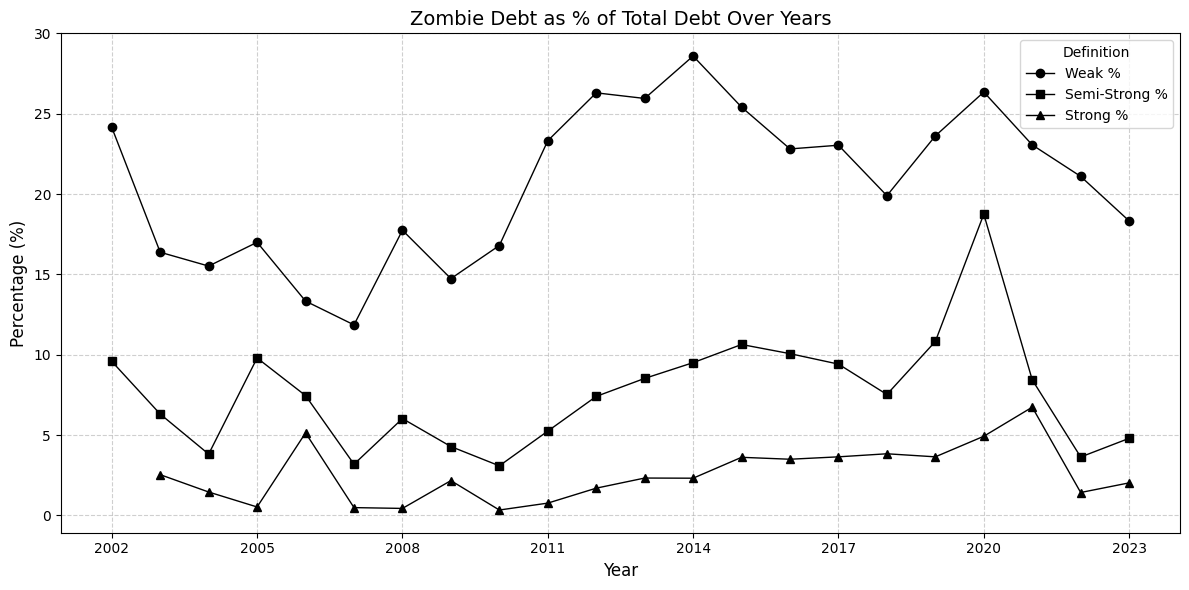

In [56]:
# Prepare the Debt_results DataFrame
Annual_debt = data.groupby('Year')['Debt'].sum()
Debt_results = pd.DataFrame(Annual_debt)

Relaxed_Zombie_debt = Relaxed[Relaxed['Zombie'] == "Zombie"].groupby('Year')['Debt'].sum()
Relaxed_Debt_Percent = ((Relaxed_Zombie_debt / Annual_debt) * 100).round(2)

Semi_Restricted_Zombie_debt = Semi_Restricted[Semi_Restricted['Zombie'] == "Zombie"].groupby('Year')['Debt'].sum()
Semi_Restricted_Debt_Percent = ((Semi_Restricted_Zombie_debt / Annual_debt) * 100).round(2)

Restricted_Zombie_debt = Restricted[Restricted['Zombie'] == "Zombie"].groupby('Year')['Debt'].sum()
Restricted_Debt_Percent = ((Restricted_Zombie_debt / Annual_debt) * 100).round(2)

Debt_results['Weak'] = Relaxed_Zombie_debt
Debt_results['Weak %'] = Relaxed_Debt_Percent
Debt_results['Semi-Strong'] = Semi_Restricted_Zombie_debt
Debt_results['Semi-Strong %'] = Semi_Restricted_Debt_Percent
Debt_results['Strong'] = Restricted_Zombie_debt
Debt_results['Strong %'] = Restricted_Debt_Percent
Debt_results = Debt_results[Debt_results.index > 2001]

# Plotting with black lines and different markers
plt.figure(figsize=(12, 6))

# Marker styles
styles = {
    'Weak %': 'o',            # Circle
    'Semi-Strong %': 's',    # Square
    'Strong %': '^'          # Triangle
}

for label, marker in styles.items():
    plt.plot(Debt_results.index, Debt_results[label],
             color='black', marker=marker, linestyle='-', linewidth=1,
             markersize=6, label=label)

plt.title('Zombie Debt as % of Total Debt Over Years', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
xticks = np.arange(2002, 2024, 3)
plt.xticks(xticks)
plt.legend(title="Definition", fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Images/Debt taken over by zombies.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [57]:
Debt_results['Weak %'].mean()

20.69636363636364

In [58]:
Debt_results['Semi-Strong %'].mean()

7.654545454545455

In [59]:
Debt_results['Strong %'].mean()

2.5533333333333337

## Calculating the Annual Total Assets Percentage

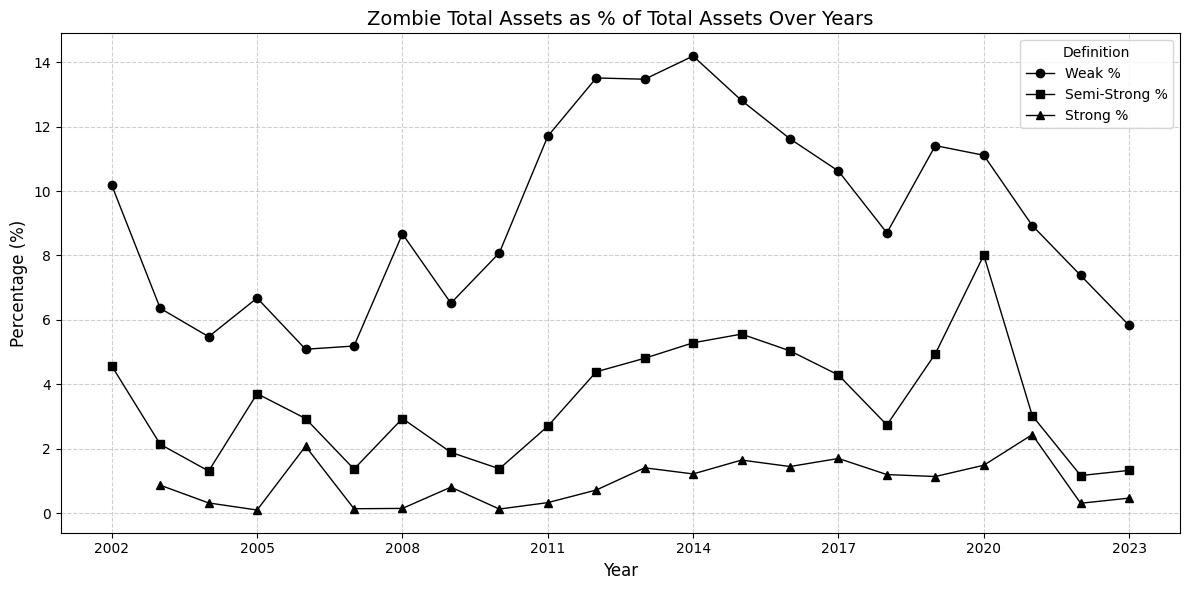

In [60]:
# Aggregate total assets
Annual_Total_Assets = data.groupby('Year')['Total Assets'].sum()
Total_Assets_results = pd.DataFrame(Annual_Total_Assets)

# Calculate zombie asset shares
Relaxed_Zombie_Total_Assets = Relaxed[Relaxed['Zombie'] == "Zombie"].groupby('Year')['Total Assets'].sum()
Relaxed_Total_Assets_Percent = ((Relaxed_Zombie_Total_Assets / Annual_Total_Assets) * 100).round(2)

Semi_Restricted_Zombie_Total_Assets = Semi_Restricted[Semi_Restricted['Zombie'] == "Zombie"].groupby('Year')['Total Assets'].sum()
Semi_Restricted_Total_Assets_Percent = ((Semi_Restricted_Zombie_Total_Assets / Annual_Total_Assets) * 100).round(2)

Restricted_Zombie_Total_Assets = Restricted[Restricted['Zombie'] == "Zombie"].groupby('Year')['Total Assets'].sum()
Restricted_Total_Assets_Percent = ((Restricted_Zombie_Total_Assets / Annual_Total_Assets) * 100).round(2)

# Combine results
Total_Assets_results['Weak'] = Relaxed_Zombie_Total_Assets
Total_Assets_results['Weak %'] = Relaxed_Total_Assets_Percent
Total_Assets_results['Semi-Strong'] = Semi_Restricted_Zombie_Total_Assets
Total_Assets_results['Semi-Strong %'] = Semi_Restricted_Total_Assets_Percent
Total_Assets_results['Strong'] = Restricted_Zombie_Total_Assets
Total_Assets_results['Strong %'] = Restricted_Total_Assets_Percent

Total_Assets_results = Total_Assets_results[Total_Assets_results.index > 2001]

# Plotting
plt.figure(figsize=(12, 6))

# Marker styles
styles = {
    'Weak %': 'o',            # Circle
    'Semi-Strong %': 's',    # Square
    'Strong %': '^'          # Triangle
}

# Plot each line in black with different marker
for label, marker in styles.items():
    plt.plot(Total_Assets_results.index, Total_Assets_results[label],
             color='black', marker=marker, linestyle='-', linewidth=1,
             markersize=6, label=label)

plt.title('Zombie Total Assets as % of Total Assets Over Years', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(np.arange(2002, 2024, 3))
plt.legend(title="Definition", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Images/Total_Assets taken over by zombies.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [61]:
Total_Assets_results['Weak %'].mean()

9.251363636363637

In [62]:
Total_Assets_results['Semi-Strong %'].mean()

3.4345454545454546

In [63]:
Total_Assets_results['Strong %'].mean()

0.9585714285714284

## Zombie matrices

In [64]:
# # Prepare year range
# years = sorted(Semi_Restricted['Year'].unique())
# continuation_matrix = pd.DataFrame(0, index=years, columns=years)
# recovery_matrix = pd.DataFrame(0, index=years, columns=years)
# exit_matrix = pd.DataFrame(0, index=years, columns=years)

# # Process each firm
# for company, group in Semi_Restricted.groupby('Company Name'):
#     group = group.sort_values('Year').reset_index(drop=True)
#     zombie_start = None

#     for i in range(len(group)):
#         year = group.loc[i, 'Year']
#         status = group.loc[i, 'Zombie']

#         if status == 'Zombie':
#             if zombie_start is None:
#                 zombie_start = year  # Start of zombie spell

#         else:  # Healthy
#             if zombie_start is not None:
#                 recovery_year = year

#                 # Record recovery
#                 if zombie_start in years and recovery_year in years:
#                     recovery_matrix.loc[zombie_start, recovery_year] += 1

#                 # Record continuation if it lasted multiple years
#                 zombie_years = list(range(zombie_start, recovery_year))
#                 for y in zombie_years:
#                     if y in years:
#                         continuation_matrix.loc[zombie_start, y] += 1

#                 zombie_start = None  # Reset

#     # Handle firms that remain zombie at end of data
#     if zombie_start is not None:
#         last_year = group.loc[len(group)-1, 'Year']
#         exit_year = last_year + 1

#         # Add continuation years
#         for y in range(zombie_start, last_year + 1):
#             if y in years:
#                 continuation_matrix.loc[zombie_start, y] += 1

#         # Add exit if exit_year is valid
#         if exit_year in years:
#             exit_matrix.loc[zombie_start, exit_year] += 1

# # Clean matrices (keep upper triangle)
# mask = np.triu(np.ones(continuation_matrix.shape), k=0).astype(bool)
# continuation_matrix = continuation_matrix.where(mask).fillna("")
# recovery_matrix = recovery_matrix.where(mask).fillna("")
# exit_matrix = exit_matrix.where(mask).fillna("")

# # Optional: Remove years before 2002
# continuation_matrix = continuation_matrix.loc[continuation_matrix.index > 2001, continuation_matrix.columns > 2001]
# recovery_matrix = recovery_matrix.loc[recovery_matrix.index > 2001, recovery_matrix.columns > 2001]
# exit_matrix = exit_matrix.loc[exit_matrix.index > 2001, exit_matrix.columns > 2001]

In [65]:
# results_df = pd.DataFrame(index=continuation_matrix.index)
# results_df.index.name = 'Year'
# results_df = results_df.reset_index()

# results_df['Count of Zombie'] = [continuation_matrix.loc[year, year] if year in continuation_matrix.columns else 0
#     for year in results_df['Year']]

# results_df['Recovery'] = [recovery_matrix.loc[year].apply(pd.to_numeric, errors='coerce').sum()
#     if year in recovery_matrix.index else 0
#     for year in results_df['Year']]

# results_df['Exit'] = [exit_matrix.loc[year].apply(pd.to_numeric, errors='coerce').sum()
#     if year in exit_matrix.index else 0
#     for year in results_df['Year']]

# results_df['Difference'] = (results_df['Recovery'] + results_df['Exit']) - results_df['Count of Zombie']

# with pd.ExcelWriter("matrices.xlsx", engine='openpyxl') as writer:
#     continuation_matrix.to_excel(writer, sheet_name='Continuation')
#     recovery_matrix.to_excel(writer, sheet_name='Recovery')
#     exit_matrix.to_excel(writer, sheet_name='Exit')
#     results_df.to_excel(writer, sheet_name='Results', index=False)

## Analysis Data

In [66]:
Analysis_data = pd.read_excel('Analysis Data.xlsx')

# NIC = pd.read_excel('Excel files/final/NIC code.xlsx')
# Current_Ratio = pd.read_excel('Excel files/final/Current Ratio.xlsx')
# Debttoequity = pd.read_excel('Excel files/final/debt to equity.xlsx')
# ROE = pd.read_excel('Excel files/final/ROE.xlsx')
# Working_Capital = pd.read_excel('Excel files/final/Working Capital.xlsx')
# Retained_Earnings = pd.read_excel('Excel files/final/Retained Earnings.xlsx')
# Sales = pd.read_excel('Excel files/final/Sales.xlsx')
# Cashflow = pd.read_excel('Excel files/final/cashflow.xlsx')
# Capex = pd.read_excel('Excel files/final/capex.xlsx')

In [67]:
# Analysis_data.to_excel('Analysis Data.xlsx', index=False)

In [68]:
Analysis_data[['ICR', 'Debt Growth']] = Analysis_data[['ICR', 'Debt Growth']].replace([np.inf, -np.inf], np.nan)

In [69]:
# Analysis_data = Analysis_data.merge(NIC[['Company Name','three digit NIC code']],on=['Company Name'],how='left')
# Analysis_data = Analysis_data.merge(Current_Ratio[['Company Name','Year','current ratio']],on=['Company Name','Year'],how='left')
# Analysis_data = Analysis_data.merge(Debttoequity[['Company Name','Year','debt to equity']],on=['Company Name','Year'],how='left')
# Analysis_data = Analysis_data.merge(ROE[['Company Name','Year','ROE']],on=['Company Name','Year'],how='left')
# Analysis_data = Analysis_data.merge(Cashflow,on=['Company Name','Year'],how='left')
# Analysis_data = Analysis_data.merge(Capex,on=['Company Name','Year'],how='left')

# Analysis_data = Analysis_data.merge(data[['Company Name','Year','PBIT']],on=['Company Name','Year'],how='left')
# Analysis_data = Analysis_data.merge(Working_Capital,on=['Company Name','Year'],how='left')
# Analysis_data = Analysis_data.merge(Retained_Earnings,on=['Company Name','Year'],how='left')
# Analysis_data = Analysis_data.merge(Sales,on=['Company Name','Year'],how='left')
# Analysis_data = Analysis_data.merge(data[['Company Name','Year','MV']],on=['Company Name','Year'],how='left')
Analysis_data = Analysis_data.merge(data[['Company Name','Year','EDR','Weak','Strong']],on=['Company Name','Year'],how='left')
# Analysis_data = Analysis_data.merge(data[['Company Name','Year','Interest Gap']],on=['Company Name','Year'],how='left')
# Analysis_data = Analysis_data.merge(Asset_Disposal[['Company Name','Year','Asset Disposal']],on=['Company Name','Year'],how='left')

# Analysis_data.dropna(subset=['Incorporation Year'],how='any',inplace=True)
# Analysis_data = Analysis_data[Analysis_data['Incorporation Year']<=2018]
# Analysis_data['Age'] = (Analysis_data['Year'] - Analysis_data['Incorporation Year']).astype(int)
# Analysis_data = Analysis_data[Analysis_data['Age']>0]
# Analysis_data['Age'] = np.log(Analysis_data['Age'])
# Analysis_data['capex'] = -Analysis_data['capex']

# Analysis_data['debt to equity'] = (Analysis_data['debt to equity'].shift(1))
# Analysis_data['ROE'] = (Analysis_data['ROE'].shift(1))
# Analysis_data['Subsidized Credit'] = (((Analysis_data['Interest Gap']<0).astype(int)).shift(1))
# Analysis_data['ROA'] =  (((Analysis_data['PBIT'] / Analysis_data['Total Assets'])).shift(1))
# Analysis_data['Subsidized Credit'] = Analysis_data['Subsidy']

In [70]:
Analysis_data['listed firm'] = (Analysis_data['MV'].notna()).astype(int)

In [71]:
# Count number of years per firm
firm_counts = Analysis_data.groupby('Company Name')['Year'].nunique()

# Filter firms with at least 5 years of Analysis_data
eligible_firms = firm_counts[firm_counts >= 5].index

# Subset the original Analysis_dataframe
Analysis_data = Analysis_data[Analysis_data['Company Name'].isin(eligible_firms)]

In [72]:
# Calculate Tobin's Q for firms with complete data, but keep all rows in Analysis_data
Analysis_data['Tobins_q'] = Analysis_data.apply(
    lambda row: ((row['MV'] + row['Debt']) / row['Total Assets']) if pd.notna(row['MV']) and pd.notna(row['Debt']) and pd.notna(row['Total Assets']) else np.nan,
    axis=1
)

# Shift the 'Tobins_q' column by 1 period for the previous period's value
Analysis_data['Tobins_q'] = Analysis_data['Tobins_q'].shift(1)

## Altman Z Score

In [73]:
def compute_z_score(row):
    if row[['Working Capital', 'Retained Earnings', 'PBIT', 'MV', 'sales', 'Total Assets']].isnull().any():
        return np.nan
    return (
        1.2 * (row['Working Capital'] / row['Total Assets']) +
        1.4 * (row['Retained Earnings'] / row['Total Assets']) +
        3.3 * (row['PBIT'] / row['Total Assets']) +
        0.6 * (row['MV'] / row['Total Assets']) +
        1.0 * (row['sales'] / row['Total Assets'])
    )

Analysis_data['Altman Z Score'] = Analysis_data.apply(compute_z_score, axis=1)

## Taking Lag of Variables

In [74]:
Analysis_data['Number of Banks'] = Analysis_data['Number of Banks'].shift(1)
Analysis_data['Number of Banks'] = Analysis_data['Number of Banks'].fillna(0)

Analysis_data['Promoter pledging'] = Analysis_data['Promoter pledging'].shift(1)
Analysis_data['Promoter pledging'] = Analysis_data['Promoter pledging'].fillna(0)

In [75]:
# List of funding variables
funding_vars = ['Borrowing from banks', 'Borrowing from financial institutions','Borrowings from RBI','Deferred credit', 
                'Borrowings from central & state govt','Borrowings syndicated across banks & institutions',
                'Inter-corporate loans', 'Loans from promoters, directors and shareholders','Equity']

# Create lagged variables by company
for col in funding_vars:
    Analysis_data[f'{col}_lag1'] = Analysis_data.groupby('Company Name')[col].shift(1)

# Create lagged Total Assets
Analysis_data['Total Assets_lag1'] = Analysis_data.groupby('Company Name')['Total Assets'].shift(1)

# Compute share columns (lagged variable / lagged total assets)
for col in funding_vars:
    lagged = f'{col}_lag1'
    share_col = f'{lagged}_share'
    Analysis_data[share_col] = (Analysis_data[lagged] / Analysis_data['Total Assets_lag1'].replace(0, np.nan))*100
    Analysis_data[share_col] = Analysis_data[share_col].fillna(0)

In [76]:
len(Analysis_data)

269320

In [77]:
share_columns = [ 'Borrowing from banks_lag1_share','Borrowing from financial institutions_lag1_share',
                'Borrowings from RBI_lag1_share','Borrowings from central & state govt_lag1_share',
                'Borrowings syndicated across banks & institutions_lag1_share','Deferred credit_lag1_share',
                 'Inter-corporate loans_lag1_share','Loans from promoters, directors and shareholders_lag1_share',
                  'Equity_lag1_share']

In [78]:
len(Analysis_data[Analysis_data['Zombie']==1])

11424

In [79]:
Analysis_data['Asset Disposal'] = ((Analysis_data['Asset Disposal'] / Analysis_data['Total Assets']).shift(1)) *100
Analysis_data['cashflow'] = ((Analysis_data['cashflow'] / Analysis_data['Total Assets']).shift(1)) * 100
Analysis_data['capex'] = ((Analysis_data['capex'] / Analysis_data['Total Assets']).shift(1)) * 100
Analysis_data['ROA'] = Analysis_data['ROA']*100

## Winsorizing the Data

In [80]:
cols_to_drop = ['Year','Age','Incorporation Year','ICR','Zombie','Number of Banks','three digit NIC code']

# Step 1: Select numeric columns but EXCLUDE Year and any ID variables
numeric_cols = Analysis_data.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop([cols_to_drop], errors='ignore')

# Step 2: Winsorize each numeric column
for col in numeric_cols:
    lower = Analysis_data[col].quantile(0.01)
    upper = Analysis_data[col].quantile(0.99)
    Analysis_data[col] = Analysis_data[col].clip(lower, upper)

In [81]:
len(Analysis_data)

269320

In [82]:
share_columns = ['Borrowing from banks_lag1_share','Borrowing from financial institutions_lag1_share',
    'Borrowings from RBI_lag1_share','Borrowings from central & state govt_lag1_share','Deferred credit_lag1_share',
    'Borrowings syndicated across banks & institutions_lag1_share','Inter-corporate loans_lag1_share',
    'Loans from promoters, directors and shareholders_lag1_share','Equity_lag1_share']

In [83]:
len(Analysis_data[Analysis_data['Zombie']==1])

11424

## creating Primary Sources

In [84]:
funding_columns = ['Borrowing from banks_lag1_share','Borrowing from financial institutions_lag1_share',
    'Borrowings from RBI_lag1_share','Borrowings from central & state govt_lag1_share',
    'Borrowings syndicated across banks & institutions_lag1_share','Deferred credit_lag1_share',
    'Inter-corporate loans_lag1_share','Loans from promoters, directors and shareholders_lag1_share','Equity_lag1_share']

# Step 1: Find the column (funding source) with the max value
Analysis_data['Primary_Source'] = Analysis_data[funding_columns].idxmax(axis=1)

# Step 2: Find the corresponding value for that column
max_values = Analysis_data[funding_columns].to_numpy().max(axis=1)
Analysis_data['Primary_Source_value'] = max_values

# Step 3: Set Primary_Source to "No Primary Source" if the max share <= 0.5
Analysis_data['Primary_Source'] = np.where(
    Analysis_data['Primary_Source_value'] > 50,
    Analysis_data['Primary_Source'].str.replace('_lag1_share', ''),
    'Other'
)

# Step 4: Drop the helper column if you don't need it
Analysis_data = Analysis_data.drop(columns=['Primary_Source_value'])

# Display result
Analysis_data[['Company Name', 'Year', 'Primary_Source']].head()

,Company Name,Year,Primary_Source
0,1 To 1 Help.Net Pvt. Ltd.,2018,Other
1,1 To 1 Help.Net Pvt. Ltd.,2019,Other
2,1 To 1 Help.Net Pvt. Ltd.,2020,Other
3,1 To 1 Help.Net Pvt. Ltd.,2022,Other
4,1 To 1 Help.Net Pvt. Ltd.,2023,Other


In [85]:
# Define a mapping function
def map_primary_source(x):
    if x == 'Borrowing from banks':
        return 'Borrowing from banks'
    elif x == 'Equity':
        return 'Equity'
    else:
        return 'Other'

# Apply it
Analysis_data['Primary_Source_Category'] = Analysis_data['Primary_Source'].apply(map_primary_source)

In [86]:
Analysis_data['Primary_Borrowing_from_banks'] = Analysis_data['Primary_Source_Category'].apply(lambda x: 1 if x == 'Borrowing from banks' else 0)
Analysis_data['Primary_Equity'] = Analysis_data['Primary_Source_Category'].apply(lambda x: 1 if x == 'Equity' else 0)

## Creating Business Group Dummy

In [87]:
Business_Group = pd.read_csv('Excel files/final/Company Group.csv')
Analysis_data = Analysis_data.merge(Business_Group,on=['Company Name'],how='left')
# Create 'Group Dummy' column: 1 if 'Ownership group' contains 'group', else 0
Analysis_data['Group Dummy'] = Analysis_data['Ownership group'].str.contains(r'\bgroup\b', case=False, na=False).astype(int)

## Creating Industry Group

In [88]:
# Classification function
def classify_nic(nic):
    try:
        code = int(nic)
    except:
        return "Invalid"

    if 11 <= code <= 32:
        return "Agriculture and Allied"
    elif 51 <= code <= 99:
        return "Mining and Quarrying"
    elif 101 <= code <= 332:
        return "Manufacturing"
    elif 450 <= code <= 479:
        return "Construction"
    elif 491 <= code <= 532:
        return "Transport"
    elif 581 <= code <= 639:
        return "IT"
    elif 641 <= code <= 663:
        return "Finance"
    elif 681 <= code <= 829:
        return "Real Estate and Business"
    elif 841 <= code <= 889:
        return "Public Services"
    elif code in list(range(351, 354)) + list(range(360, 391)) + list(range(551, 564)) + list(range(900, 991)):
        return "Others"
    else:
        return "Others"

# Apply classification
Analysis_data['Industry_Group'] = Analysis_data['three digit NIC code'].apply(classify_nic)

# Display result
Analysis_data.head()

,Company Name,Year,Semi_Restricted,Borrowing from banks_lag1_share,Borrowing from financial institutions_lag1_share,Borrowings from RBI_lag1_share,Borrowings from central & state govt_lag1_share,Borrowings syndicated across banks & institutions_lag1_share,Deferred credit_lag1_share,Inter-corporate loans_lag1_share,...,capex,ROA,EDR,Weak,Strong,listed firm,Tobins_q,Ownership group,Group Dummy,Industry_Group
0,1 To 1 Help.Net Pvt. Ltd.,2018,Healthy,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0.510504,Healthy,Healthy,0,NaN,Private (Indian),0,Real Estate and Business
1,1 To 1 Help.Net Pvt. Ltd.,2019,Healthy,28.333333,0.0,0.0,0.0,0.0,0.0,0.0,...,0.357143,14.464286,0.971129,Healthy,Healthy,0,NaN,Private (Indian),0,Real Estate and Business
2,1 To 1 Help.Net Pvt. Ltd.,2020,Healthy,21.140553,0.0,0.0,0.0,0.0,0.0,0.0,...,0.230415,21.313364,1.283912,Healthy,Healthy,0,NaN,Private (Indian),0,Real Estate and Business
3,1 To 1 Help.Net Pvt. Ltd.,2022,Healthy,21.246649,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,27.278820,24.307692,Healthy,Healthy,0,NaN,Private (Indian),0,Real Estate and Business
4,1 To 1 Help.Net Pvt. Ltd.,2023,Healthy,1.709776,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219202,38.157303,24.307692,Healthy,Healthy,0,NaN,Private (Indian),0,Real Estate and Business


In [89]:
# Step 1: Function to calculate zombie share
def calculate_zombie_share(df, definition_col):
    counts = df.groupby(['Industry_Group', df[definition_col]]).size().unstack(fill_value=0)
    
    # Ensure 'Zombie' column exists
    if 'Zombie' not in counts.columns:
        counts['Zombie'] = 0
    
    total = counts.sum(axis=1)
    share_col_name = f'{definition_col}_Zombie_Share_Percentage'
    
    counts[share_col_name] = (counts['Zombie'] / total) * 100
    
    # Only return the share column
    return counts[[share_col_name]]

# Step 2: Compute shares
weak_share = calculate_zombie_share(Analysis_data, 'Weak')
semi_strong_share = calculate_zombie_share(Analysis_data, 'Semi_Restricted')
strong_share = calculate_zombie_share(Analysis_data, 'Strong')

# Step 3: Join all
zombie_share_all = weak_share.join(semi_strong_share, how='outer').join(strong_share, how='outer')

# Step 4: Print column names for debug (optional)
print("Columns in final DataFrame:", zombie_share_all.columns)

# Step 5: Sort if column exists
col_to_sort = 'Semi_Strong_Zombie_Share_Percentage'
if col_to_sort in zombie_share_all.columns:
    zombie_share_all = zombie_share_all.sort_values(by=col_to_sort, ascending=False)

# Show result
zombie_share_all.round(2)

Columns in final DataFrame: Index(['Weak_Zombie_Share_Percentage',
       'Semi_Restricted_Zombie_Share_Percentage',
       'Strong_Zombie_Share_Percentage'],
      dtype='object')


,Weak_Zombie_Share_Percentage,Semi_Restricted_Zombie_Share_Percentage,Strong_Zombie_Share_Percentage
Industry_Group,,,
Agriculture and Allied,7.15,3.38,0.59
Construction,7.95,3.93,0.79
IT,9.32,4.01,0.82
Manufacturing,8.23,4.08,0.94
Mining and Quarrying,12.59,5.59,1.34
Others,10.73,4.90,1.21
Public Services,14.82,4.54,0.86
Real Estate and Business,9.79,4.50,0.88
Transport,14.91,4.54,0.80


## Kolmogrov stats

In [90]:
df = Analysis_data.copy()

# Step 2: Define the variables you want to analyze (the list you provided)
variables = ['Number of Banks', 'Promoter pledging', 'Interest Gap', 'Asset Disposal', 'capex','Primary_Equity',
             'Debt Growth', 'ICR', 'Debt to Assets', 'cashflow', 'EDR','debt to equity','Total Assets',
              'Subsidized Credit','ROE','ROA','Altman Z Score','Tobins_q','Primary_Borrowing_from_banks'] + share_columns

# Step 3: Split the data into zombie and non-zombie firms
# Assuming 'Zombie' column indicates whether the firm is a zombie (1 for zombie, 0 for non-zombie)
non_zombie = df[df['Zombie'] == 0]
zombie = df[df['Zombie'] == 1]

# Step 4: Conduct Kolmogorov-Smirnov tests for each variable
ks_results = []

for var in variables:
    # Ensure there are no NaN values in the columns before performing the test
    non_zombie_var = non_zombie[var].dropna()
    zombie_var = zombie[var].dropna()
    
    # Perform Kolmogorov-Smirnov test
    ks_stat, ks_p_value = ks_2samp(non_zombie_var, zombie_var)
    
    # Append results
    ks_results.append({
        'Variable': var,
        'KS Statistic': ks_stat,
        'P-value': ks_p_value
    })

# Convert results into DataFrame
ks_results_df = pd.DataFrame(ks_results).round(2).sort_values(by='KS Statistic', ascending=False)

In [91]:
desc = Analysis_data[variables + ['Zombie']].groupby('Zombie').describe().astype(float).T.round(3)
mean_only = desc.xs('mean', level=1).rename(columns={0: 'Non-Zombie', 1: 'Zombie'})
mean_only = mean_only.reset_index()

In [92]:
# Merge ks_results_df and mean_only on the correct column names
Kolmogrov_stats = mean_only.merge(ks_results_df, left_on='index', right_on='Variable', how='left')
Kolmogrov_stats = Kolmogrov_stats.round(2).drop('Variable', axis=1).sort_values(by='Non-Zombie', ascending=False)
Kolmogrov_stats

,index,Non-Zombie,Zombie,KS Statistic,P-value
12,Total Assets,5989.00,6007.10,0.06,0.00
6,Debt Growth,36.25,37.31,0.52,0.00
19,Borrowing from banks_lag1_share,17.91,27.57,0.17,0.00
7,ICR,15.27,-4.74,0.81,0.00
15,ROA,6.92,-1.67,0.35,0.00
4,capex,5.36,4.24,0.15,0.00
27,Equity_lag1_share,5.27,3.16,0.04,0.00
14,ROE,4.60,-33.51,0.41,0.00
25,Inter-corporate loans_lag1_share,4.16,10.65,0.16,0.00
26,"Loans from promoters, directors and shareholde...",2.14,3.49,0.04,0.00


In [93]:
# Analysis_data = pd.read_excel('Analysis Data.xlsx')
x = Analysis_data.copy()

# Semi-Restricted

In [94]:
zombie_companies = x.loc[x['Semi_Restricted'] == 'Zombie', 'Company Name'].unique()
zombie_firms_all_years = x[x['Company Name'].isin(zombie_companies)]

# List of target variables
target_columns = [
   'Borrowing from banks_lag1_share','Borrowing from financial institutions_lag1_share',
       'Borrowings from RBI_lag1_share','Borrowings from central & state govt_lag1_share',
       'Borrowings syndicated across banks & institutions_lag1_share','Deferred credit_lag1_share',
    'Inter-corporate loans_lag1_share','Loans from promoters, directors and shareholders_lag1_share',
       'Equity_lag1_share','Number of Banks','Promoter pledging']

# Drop rows where ALL of the above are NaN
zombie_firms_all_years = zombie_firms_all_years.dropna(subset=target_columns, how='all')
zombie_firms_all_years.drop(columns=['Borrowings from RBI'],inplace=True)

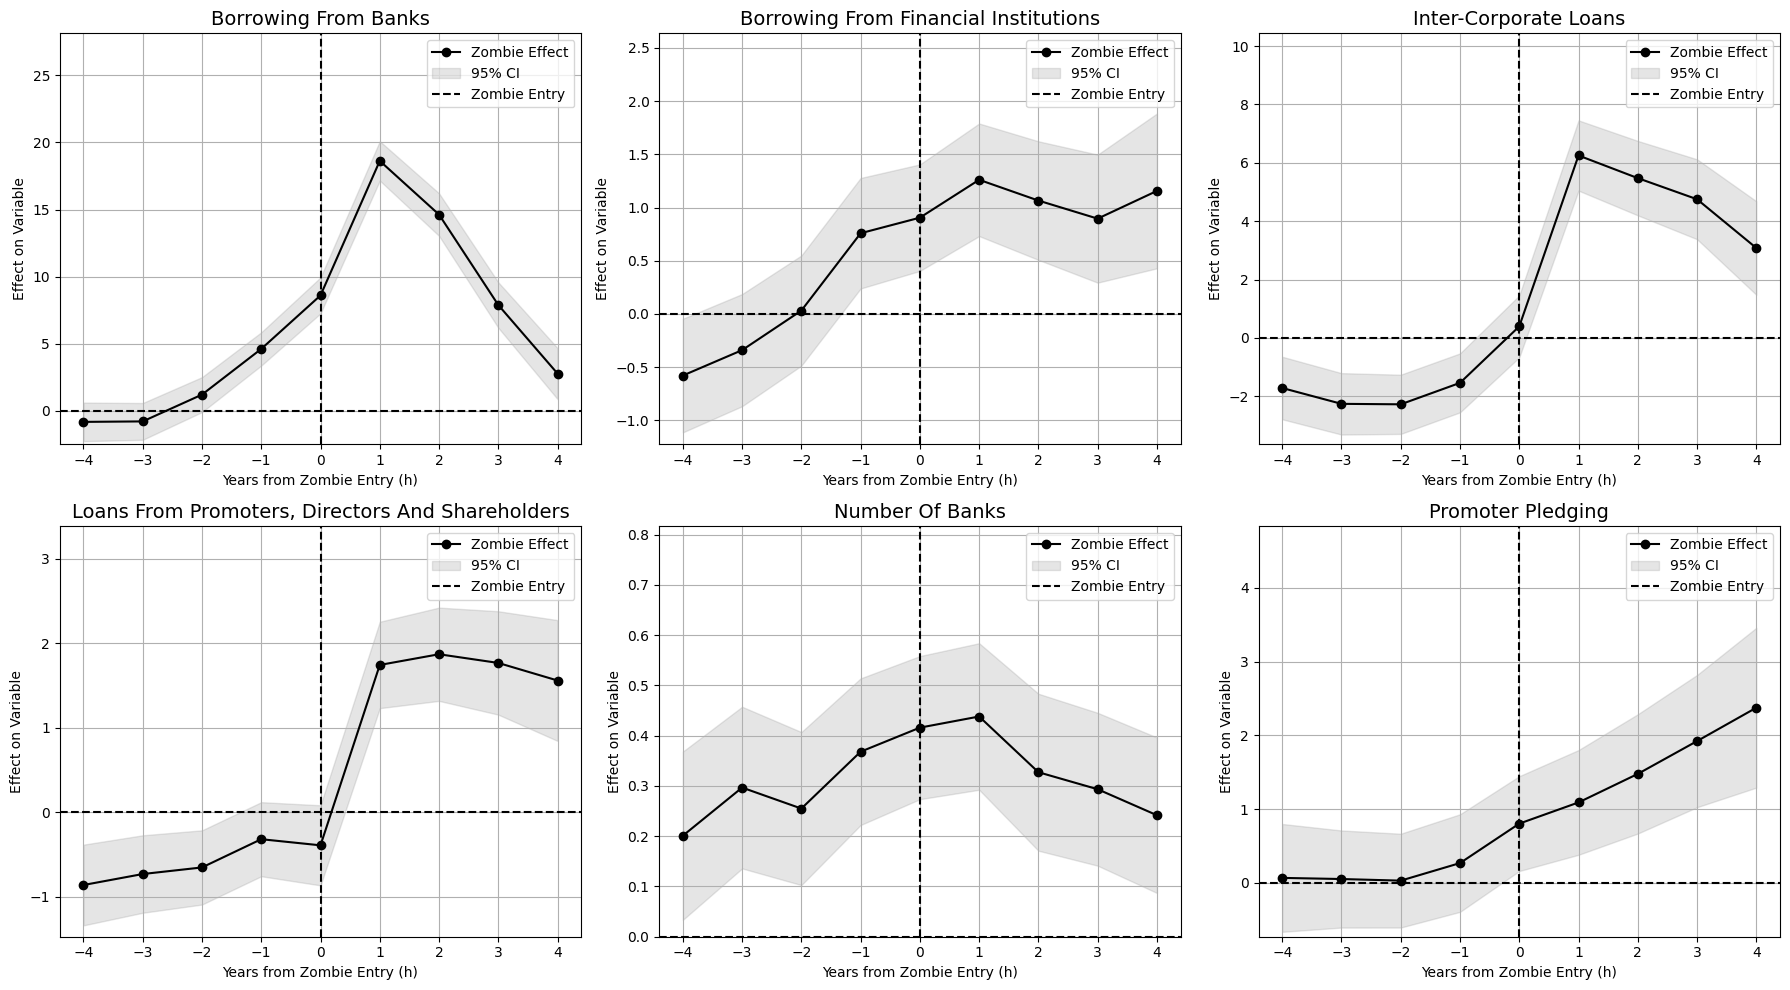

In [95]:
    # === Prepare Data ===
    df = zombie_firms_all_years.copy()
    df['Semi_Restricted_binary'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
    df = df.sort_values(by=['Company Name', 'Year'])
    df['EntryZombie_Semi_Restricted'] = df.groupby('Company Name')['Semi_Restricted_binary'].transform(
        lambda x: (x == 1) & (x.shift(1) == 0)
    ).astype(int)

    # === Analysis Variables ===
    analysis_variables = [
        'Borrowing from banks_lag1_share',
        'Borrowing from financial institutions_lag1_share',
        'Inter-corporate loans_lag1_share',
        'Loans from promoters, directors and shareholders_lag1_share',
        'Number of Banks',
        'Promoter pledging'
    ]

    # === Fixed Effects Local Projection Function ===
    def run_local_projection_fe(df, y_var, zombie_col, entry_col, h_range=range(-4, 5)):
        results = []
        df = df.sort_values(by=['Company Name', 'Year']).copy()
        df = df.set_index(['Company Name', 'Year'])

        for h in h_range:
            df_temp = df.copy()
            lead_col = f'{y_var}_lead_{h}'
            df_temp[lead_col] = df_temp.groupby(level=0)[y_var].shift(-h)
            data = df_temp.dropna(subset=[lead_col]).copy()

            data['OngoingZombie'] = ((data[zombie_col] == 1) & (data[entry_col] == 0)).astype(int)
            X = sm.add_constant(data[[entry_col, 'OngoingZombie']])
            y = data[lead_col]

            try:
                model = PanelOLS(y, X, entity_effects=True, time_effects=True)
                res = model.fit(cov_type='clustered', cluster_entity=True)

                results.append({
                    'h': h,
                    'beta_h': res.params.get(entry_col, np.nan),
                    'gamma_h': res.params.get('OngoingZombie', np.nan),
                    'beta_se': res.std_errors.get(entry_col, np.nan),
                    'gamma_se': res.std_errors.get('OngoingZombie', np.nan),
                    'n_obs': res.nobs
                })
            except Exception as e:
                print(f"Regression failed at h = {h} for {y_var}: {e}")

        return pd.DataFrame(results)

    # === Run for All Variables ===
    def run_local_projection_fe_multiple_vars(df, variables, zombie_col, entry_col, h_range=range(-4, 5)):
        return {
            var: run_local_projection_fe(df, var, zombie_col, entry_col, h_range)
            for var in variables
        }

    lp_results_all_vars = run_local_projection_fe_multiple_vars(
        df=df,
        variables=analysis_variables,
        zombie_col='Semi_Restricted_binary',
        entry_col='EntryZombie_Semi_Restricted'
    )

    # === Plotting Function for Combined Zombie Effect ===
    def plot_local_projection_fe_combined(lp_results, variables, title_prefix=None, save_path='Images/LLP_FE_Borrowings.tiff'):
        n_cols, n_rows = 3, (len(variables) + 2) // 3
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
        axes = axes.flatten()

        for i, var in enumerate(variables):
            result_df = lp_results[var]

            # Combine β_h and γ_h for the zombie effect
            combined_effect = result_df['beta_h'] + result_df['gamma_h']

            # Calculate 95% CI for the combined effect
            lower = combined_effect - 1.96 * (result_df['beta_se'] + result_df['gamma_se'])
            upper = combined_effect + 1.96 * (result_df['beta_se'] + result_df['gamma_se'])

            # Plot the combined effect
            axes[i].plot(result_df['h'], combined_effect, marker='o', label='Zombie Effect', color='black')
            axes[i].fill_between(result_df['h'], lower, upper, color='grey', alpha=0.2, label='95% CI')

            axes[i].axvline(0, color='black', linestyle='--', label='Zombie Entry')
            axes[i].axhline(0, color='black', linestyle='--')
            
            y_max = upper.max()
            y_min = lower.min()
            axes[i].set_ylim(1.1 * y_min if y_min < 0 else 0, 1.4 * y_max if y_max > 0 else 0)
   
            clean_title = var.replace('_lag1_share', '').replace('_', ' ').title()
            axes[i].set_title(f"{title_prefix} {clean_title}" if title_prefix else clean_title, fontsize=14)
            axes[i].set_xlabel("Years from Zombie Entry (h)")
            axes[i].set_ylabel("Effect on Variable")
            axes[i].grid(True)
            axes[i].legend(loc='upper right', fontsize=10)

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.savefig('Images/LLP_FE_Borrowings.tiff', dpi=1000, bbox_inches='tight')
        plt.show()

    # === Run and Plot the Combined Zombie Effect ===
    plot_local_projection_fe_combined(lp_results_all_vars, analysis_variables)

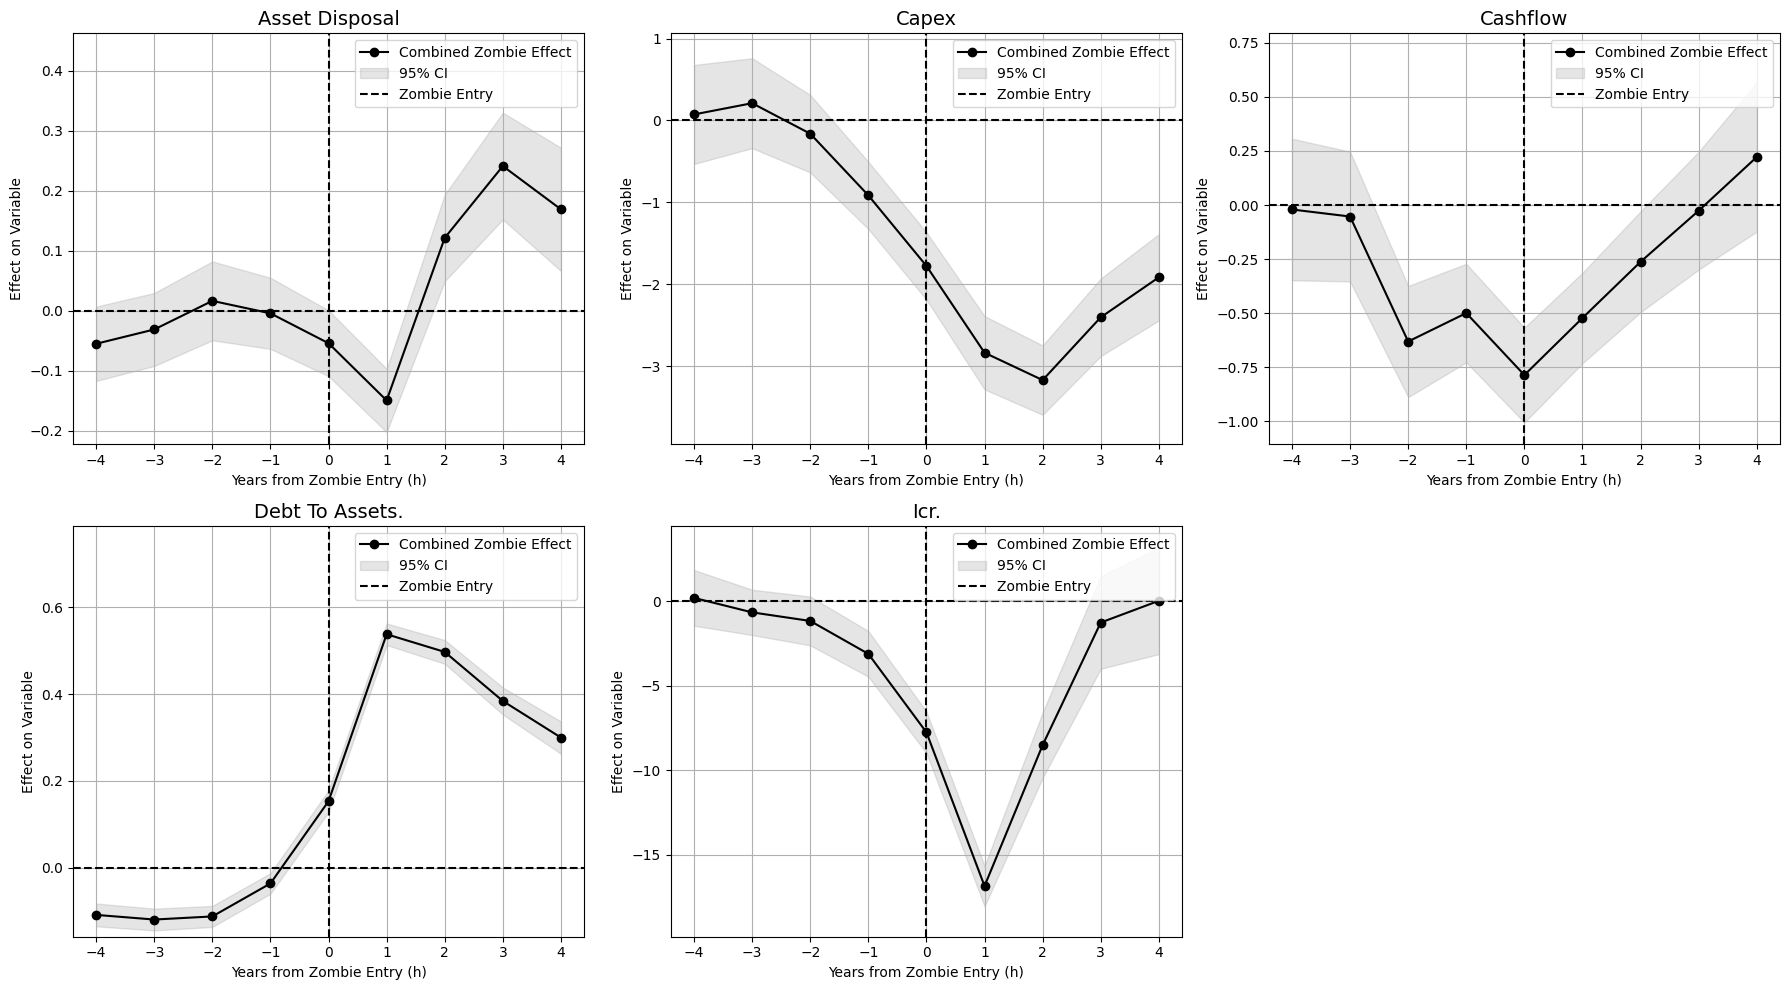

In [96]:
df = zombie_firms_all_years.copy()
df['Semi_Restricted_binary'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df = df.sort_values(by=['Company Name', 'Year'])

df['EntryZombie_Semi_Restricted'] = df.groupby('Company Name')['Semi_Restricted_binary'].transform(
    lambda x: (x == 1) & (x.shift(1) == 0)
).astype(int)

# === Create normalized variables ===
df['ICR.'] = df['ICR'].shift(1).fillna(0)
df['Debt to Assets.'] = df['Debt to Assets'].shift(1).fillna(0)

# === Define variables for local projection ===
analysis_variables = ['Asset Disposal', 'capex', 'cashflow', 'Debt to Assets.', 'ICR.']

# === Fixed Effects Local Projection Function ===
def run_local_projection_fe(df, y_var, zombie_col, entry_col, h_range=range(-4, 5)):
    results = []
    df = df.sort_values(by=['Company Name', 'Year']).copy()
    df = df.set_index(['Company Name', 'Year'])

    for h in h_range:
        df_temp = df.copy()
        lead_col = f'{y_var}_lead_{h}'
        df_temp[lead_col] = df_temp.groupby(level=0)[y_var].shift(-h)
        data = df_temp.dropna(subset=[lead_col]).copy()

        data['OngoingZombie'] = ((data[zombie_col] == 1) & (data[entry_col] == 0)).astype(int)
        X = sm.add_constant(data[[entry_col, 'OngoingZombie']])
        y = data[lead_col]

        try:
            model = PanelOLS(y, X, entity_effects=True, time_effects=True)
            res = model.fit(cov_type='clustered', cluster_entity=True)

            results.append({
                'h': h,
                'beta_h': res.params.get(entry_col, np.nan),
                'gamma_h': res.params.get('OngoingZombie', np.nan),
                'beta_se': res.std_errors.get(entry_col, np.nan),
                'gamma_se': res.std_errors.get('OngoingZombie', np.nan),
                'n_obs': res.nobs
            })
        except Exception as e:
            print(f"Regression failed at h = {h} for {y_var}: {e}")

    return pd.DataFrame(results)

# === Run for All Variables ===
def run_local_projection_fe_multiple_vars(df, variables, zombie_col, entry_col, h_range=range(-4, 5)):
    return {
        var: run_local_projection_fe(df, var, zombie_col, entry_col, h_range)
        for var in variables
    }

lp_results_all_vars = run_local_projection_fe_multiple_vars(
    df=df,
    variables=analysis_variables,
    zombie_col='Semi_Restricted_binary',
    entry_col='EntryZombie_Semi_Restricted'
)

# === Plotting: Entry Effect Only ===
def plot_local_projection_fe(lp_results, variables, save_path='Images/LLP_FE_Characteristics.tiff'):
    n_cols, n_rows = 3, (len(variables) + 2) // 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, var in enumerate(variables):
        result_df = lp_results[var]
        lower = result_df['beta_h'] - 1.96 * result_df['beta_se']
        upper = result_df['beta_h'] + 1.96 * result_df['beta_se']

        axes[i].plot(result_df['h'], result_df['beta_h'], marker='o', label='EntryZombie Effect', color='black')
        axes[i].fill_between(result_df['h'], lower, upper, color='grey', alpha=0.2, label='95% CI')
        axes[i].axvline(0, color='black', linestyle='--', label='Zombie Entry')
        axes[i].axhline(0, color='black', linestyle='--')
            
        y_max = upper.max()
        y_min = lower.min()
        axes[i].set_ylim(1.1 * y_min if y_min < 0 else 0, 2 * y_max if y_max > 0 else 0)          

        clean_title = var.replace('_lag1_share', '').replace('_', ' ').title()
        axes[i].set_title(clean_title, fontsize=14)
        axes[i].set_xlabel("Years from Zombie Entry (h)")
        axes[i].set_ylabel("Effect on Variable")
        axes[i].grid(True)
        axes[i].legend(loc='upper left', fontsize=10)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(save_path, dpi=1000, bbox_inches='tight')
    plt.show()

# === Plotting: Combined Zombie Effect (Entry + Ongoing) ===
def plot_local_projection_fe_combined(lp_results, variables, title_prefix=None, save_path='Images/LLP_FE_Borrowings.tiff'):
    n_cols, n_rows = 3, (len(variables) + 2) // 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, var in enumerate(variables):
        result_df = lp_results[var]
        combined_effect = result_df['beta_h'] + result_df['gamma_h']
        combined_se = np.sqrt(result_df['beta_se']**2 + result_df['gamma_se']**2)

        lower = combined_effect - 1.96 * combined_se
        upper = combined_effect + 1.96 * combined_se

        axes[i].plot(result_df['h'], combined_effect, marker='o', label='Combined Zombie Effect', color='black')
        axes[i].fill_between(result_df['h'], lower, upper, color='grey', alpha=0.2, label='95% CI')
        axes[i].axvline(0, color='black', linestyle='--', label='Zombie Entry')
        axes[i].axhline(0, color='black', linestyle='--')
        
        y_max = upper.max()
        y_min = lower.min()
        axes[i].set_ylim(1.1 * y_min if y_min < 0 else 0, 1.4 * y_max if y_max > 0 else 0) 
        
        clean_title = var.replace('_lag1_share', '').replace('_', ' ').title()
        axes[i].set_title(f"{title_prefix} {clean_title}" if title_prefix else clean_title, fontsize=14)
        axes[i].set_xlabel("Years from Zombie Entry (h)")
        axes[i].set_ylabel("Effect on Variable")
        axes[i].grid(True)
        axes[i].legend(loc='upper right', fontsize=10)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig('Images/LLP_FE_Characteristics.tiff', dpi=1000, bbox_inches='tight')
    plt.show()

# === Plot Both ===
plot_local_projection_fe_combined(lp_results_all_vars, analysis_variables)

In [97]:
Semi_Restricted_Cont      = pd.read_excel('matrices.xlsx',sheet_name='Continuation').set_index('Year')
Semi_Restricted_Recovered = pd.read_excel('matrices.xlsx',sheet_name='Recovery')
Semi_Restricted_Recovered.rename(columns={'Unnamed: 0':"Year"},inplace=True)
Semi_Restricted_Recovered = Semi_Restricted_Recovered.set_index('Year')

In [98]:
df = Semi_Restricted_Cont

# Initialize a list to store rows of calculated probabilities
continuation_probabilities = []

# Loop over each year in the index
for year in df.index:
    row = {"Year": year}
    
    # Calculate t+1 to t+5 continuation probabilities
    for offset in range(1, 4):  # from t+1 to t+5
        col_year = year + offset
        if col_year in df.columns:
            base_value = df.loc[year, year]  # value at (t, t)
            future_value = df.loc[year, col_year]  # value at (t, t+offset)
            
            if pd.notna(base_value) and pd.notna(future_value) and base_value != 0:
                prob = future_value / base_value
            else:
                prob = np.nan
        else:
            prob = np.nan
        
        row[f"{offset} year"] = prob  # Renamed here
    
    continuation_probabilities.append(row)

# Convert list of dicts to DataFrame
continuation_df = pd.DataFrame(continuation_probabilities)

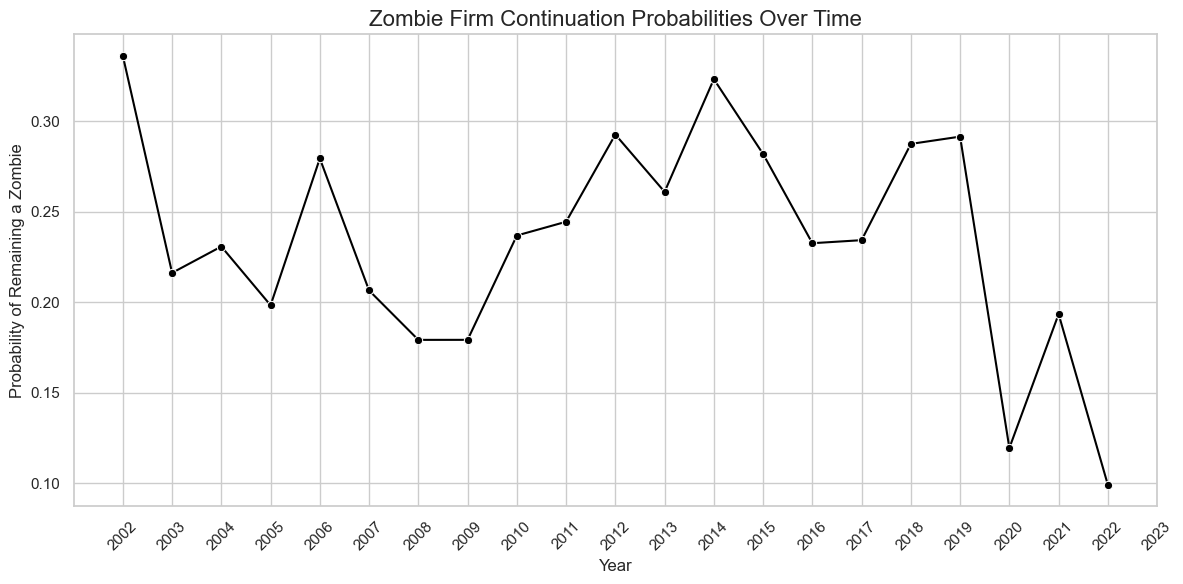

In [99]:
# Melt the DataFrame for easier plotting
melted_df = continuation_df.melt(id_vars='Year', 
                                  value_vars=['1 year'],
                                  var_name='Duration',
                                  value_name='Probability')

# Set the plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=melted_df, x='Year', y='Probability', color='black', marker='o')

# Format x-axis ticks as integers
plt.xticks(ticks=continuation_df['Year'].unique(), labels=continuation_df['Year'].unique().astype(int), rotation=45)

# Add titles and labels
plt.title('Zombie Firm Continuation Probabilities Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Probability of Remaining a Zombie', fontsize=12)
plt.tight_layout()
plt.savefig('Images/Continuation Probability.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [100]:
# if 'Year' not in continuation_df.columns:
#     continuation_df = continuation_df.reset_index()
# if 'Year' not in Semi_Restricted_results.columns:
#     Semi_Restricted_results = Semi_Restricted_results.reset_index()

# # Ensure Year is integer type
# continuation_df['Year'] = continuation_df['Year'].astype(int)
# Semi_Restricted_results['Year'] = Semi_Restricted_results['Year'].astype(int)

# # Melt continuation data
# melted_df = continuation_df.melt(
#     id_vars='Year',
#     value_vars=['1 year'],  # Adjust if more durations exist
#     var_name='Duration',
#     value_name='Probability'
# )

# # === Combined Plot ===
# fig, ax1 = plt.subplots(figsize=(12, 6))

# # Plot Zombie Share on left y-axis
# color1 = 'teal'
# ax1.plot(Semi_Restricted_results['Year'], Semi_Restricted_results['Zombie_Percentage'],
#          color=color1, linewidth=2.5, label='Zombie Percentage')
# ax1.set_ylabel('Zombie Percentage (%)', fontsize=12)
# ax1.tick_params(axis='y')
# ax1.set_xlabel('Year', fontsize=12)
# ax1.set_xticks(Semi_Restricted_results['Year'][::3])
# ax1.set_xticklabels(Semi_Restricted_results['Year'][::3], rotation=0, fontsize=10)
# ax1.set_ylim(0, Semi_Restricted_results['Zombie_Percentage'].max() * 1.1)
# ax1.grid(True, linestyle='--', alpha=0.6)

# # Create right y-axis for continuation probability
# ax2 = ax1.twinx()
# color2 = 'red'
# sns.lineplot(data=melted_df, x='Year', y='Probability', hue='Duration',
#               ax=ax2, palette=[color2], legend=False)
# ax2.set_ylabel('Continuation Probability', fontsize=12)
# ax2.tick_params(axis='y')

# # Title and legends
# plt.title('Zombie Share and Continuation Probability Over Time', fontsize=15, weight='bold')
# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + ['1-Year Continuation Probability'], loc='upper left', fontsize=10)

# # Save and show
# plt.tight_layout()
# plt.savefig('Images/Zombie_Share_and_Continuation_Probability.tiff', dpi=1000, bbox_inches='tight')
# plt.show()

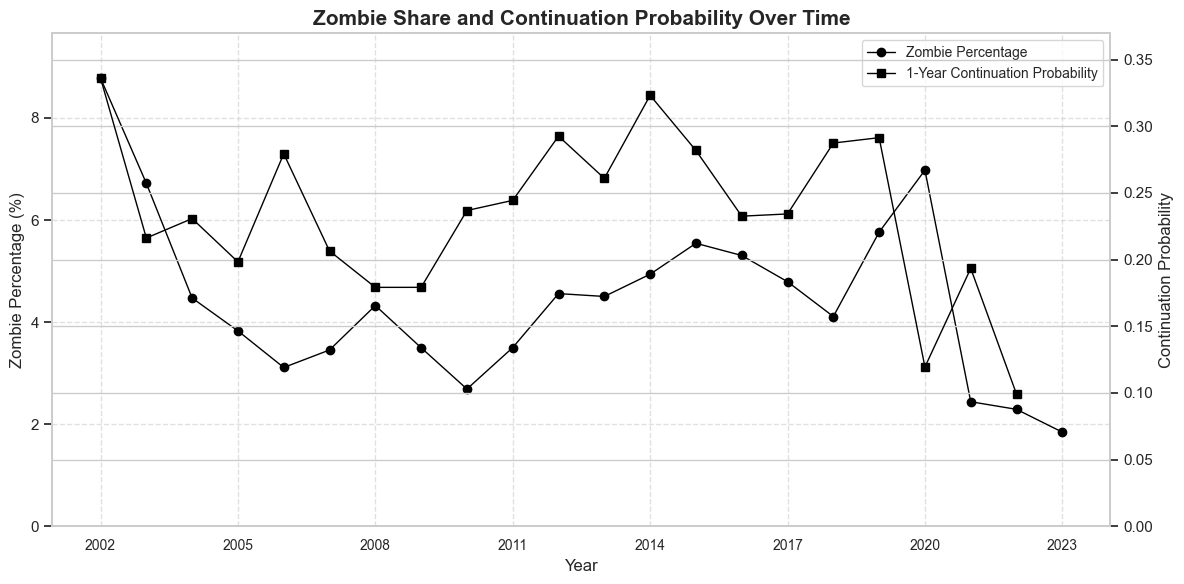

In [101]:
# Ensure 'Year' is in both DataFrames and is of type int
if 'Year' not in continuation_df.columns:
    continuation_df = continuation_df.reset_index()
if 'Year' not in Semi_Restricted_results.columns:
    Semi_Restricted_results = Semi_Restricted_results.reset_index()

continuation_df['Year'] = continuation_df['Year'].astype(int)
Semi_Restricted_results['Year'] = Semi_Restricted_results['Year'].astype(int)

# Melt continuation data
melted_df = continuation_df.melt(
    id_vars='Year',
    value_vars=['1 year'],
    var_name='Duration',
    value_name='Probability'
)

# === Combined Plot ===
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Zombie Share on left y-axis (black line with circle markers)
ax1.plot(Semi_Restricted_results['Year'], Semi_Restricted_results['Zombie_Percentage'],
         color='black', marker='o', linestyle='-', linewidth=1, label='Zombie Percentage')
ax1.set_ylabel('Zombie Percentage (%)', fontsize=12)
ax1.tick_params(axis='y')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_xticks(Semi_Restricted_results['Year'][::3])
ax1.set_xticklabels(Semi_Restricted_results['Year'][::3], rotation=0, fontsize=10)
ax1.set_ylim(0, Semi_Restricted_results['Zombie_Percentage'].max() * 1.1)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Continuation Probability on right y-axis (black line with square markers)
ax2 = ax1.twinx()
ax2.plot(melted_df['Year'], melted_df['Probability'],
         color='black', marker='s', linestyle='-', linewidth=1, label='1-Year Continuation Probability')
ax2.set_ylabel('Continuation Probability', fontsize=12)
ax2.tick_params(axis='y')
ax2.set_ylim(0, melted_df['Probability'].max() * 1.1)

# Title and combined legend
plt.title('Zombie Share and Continuation Probability Over Time', fontsize=15, weight='bold')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=10)

# Save and show
plt.tight_layout()
plt.savefig('Images/Zombie_Share_and_Continuation_Probability.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [102]:
# Initialize a list to store calculated recovery probabilities
recovery_probabilities = []

# Loop over each year in the index
for year in Semi_Restricted_Recovered.index:
    row = {"Year": year}
    
    for offset in range(1, 4):  # t+1 to t+3 recovery probabilities
        col_year = year + offset
        
        # Make sure both the row year and column year exist
        if col_year in Semi_Restricted_Recovered.columns and year in Semi_Restricted_Cont.index:
            base_value = Semi_Restricted_Cont.loc[year, year]  # zombies in year t
            recovery_value = Semi_Restricted_Recovered.loc[year, col_year]  # recovered in year t+offset
            
            if pd.notna(base_value) and pd.notna(recovery_value) and base_value != 0:
                prob = recovery_value / base_value
            else:
                prob = np.nan
        else:
            prob = np.nan
        
        row[f"{offset} year"] = prob
    
    recovery_probabilities.append(row)

# Convert to DataFrame
recovery_df = pd.DataFrame(recovery_probabilities)

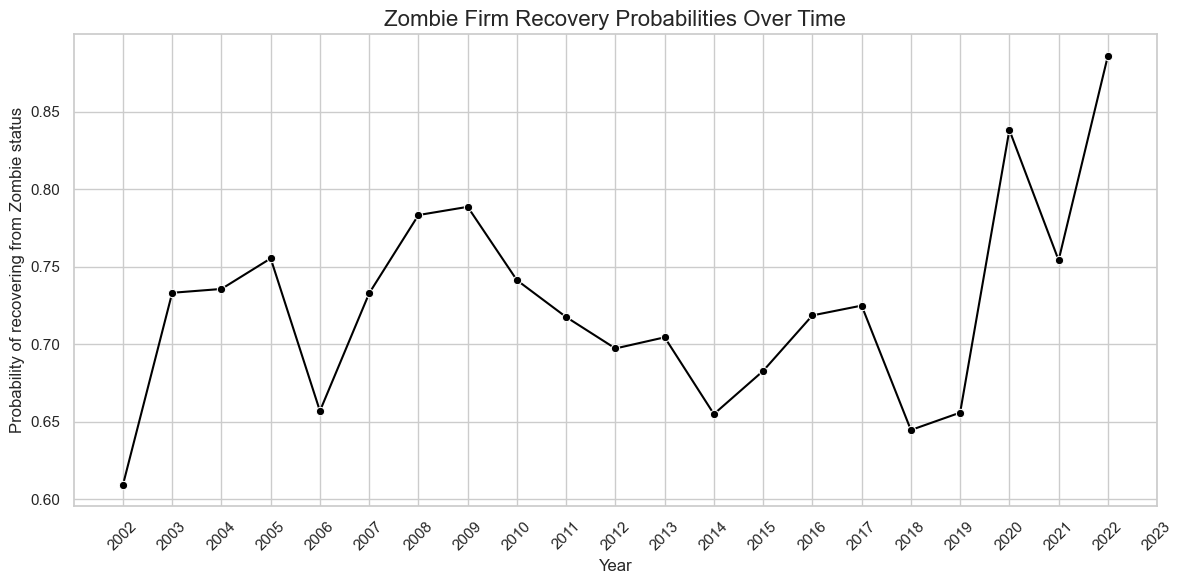

In [103]:
# Melt the DataFrame for easier plotting
melted_df = recovery_df.melt(id_vars='Year', 
                                  value_vars=['1 year'],
                                  var_name='Duration',
                                  value_name='Probability')

# Set the plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=melted_df, x='Year', y='Probability', color='black', marker='o')

# Format x-axis ticks as integers
plt.xticks(ticks=recovery_df['Year'].unique(), labels=recovery_df['Year'].unique().astype(int), rotation=45)

# Add titles and labels
plt.title('Zombie Firm Recovery Probabilities Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Probability of recovering from Zombie status', fontsize=12)
plt.tight_layout()
plt.savefig('Images/recovery Probability.tiff', dpi=1000, bbox_inches='tight')
plt.show()

# Kaplan Meier Survival Estimates

## Kaplan Meier for recovery of Zombie Firms

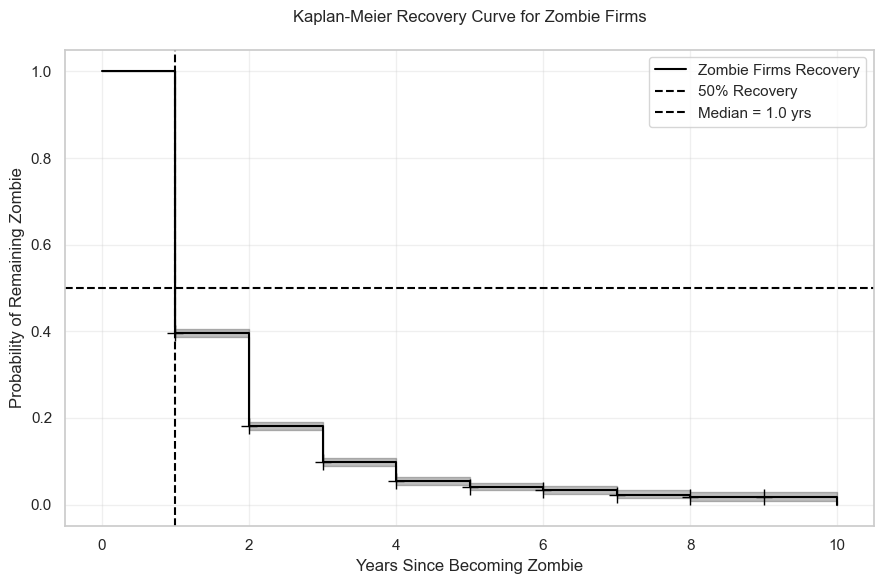

Time Period (years),Probability of Remaining Zombie,Probability of Recovery,Median Recovery Time
1,39.7%,60.3%,1.0
3,9.8%,90.2%,1.0
5,4.1%,95.9%,1.0


In [104]:
# Prepare the data 
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount()
df['Event'] = ((df['Zombie'] == 0) & (df['Prev_Zombie'] == 1)).astype(int)
df_zombie_exit = df[df['Prev_Zombie'] == 1].copy()

# Kaplan-Meier analysis 
kmf = KaplanMeierFitter()
kmf.fit(df_zombie_exit['Duration'], event_observed=df_zombie_exit['Event'], label='Zombie Firms Recovery')

# Plot
plt.figure(figsize=(9, 6))
ax = kmf.plot(ci_show=True, show_censors=True,color='black')
plt.axhline(y=0.5, color='black', linestyle='--', label='50% Recovery')
plt.axvline(x=kmf.median_survival_time_, color='black', linestyle='--', label=f'Median = {kmf.median_survival_time_:.1f} yrs')
plt.title("Kaplan-Meier Recovery Curve for Zombie Firms", pad=20)
plt.xlabel("Years Since Becoming Zombie")
plt.ylabel("Probability of Remaining Zombie")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Recovery.tiff', dpi=1000, bbox_inches='tight')
plt.show()

# Generate structured statistics table
time_points = [1, 3, 5]  # Standard time intervals
survival_probs = kmf.predict(time_points)

stats_data = {'Time Period (years)': time_points,'Probability of Remaining Zombie': survival_probs,
    'Probability of Recovery': 1 - survival_probs,'Median Recovery Time': [kmf.median_survival_time_] * len(time_points)}

stats_df = pd.DataFrame(stats_data)

# Format the table for display
formatted_stats = stats_df.style.format({'Probability of Remaining Zombie': '{:.1%}','Probability of Recovery': '{:.1%}',
    'Median Recovery Time': '{:.1f}'}).hide(axis='index')

# Display the table with a title
display(formatted_stats)

In [105]:
# # Copy and sort data
# df = Analysis_data.copy()
# df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# # Step-by-step zombie spell construction
# df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
# df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
# df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
# df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
# df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount()
# df['Event'] = ((df['Zombie'] == 0) & (df['Prev_Zombie'] == 1)).astype(int)

# # Keep only zombie spells that had a previous year as zombie
# df_zombie_exit = df[df['Prev_Zombie'] == 1].copy()

# # --- Single combined plot ---
# fig, ax = plt.subplots(figsize=(10, 6))

# # Group definitions and colors
# group_labels = {0: "Non-Business group", 1: "Business Group"}
# colors = {0: 'blue', 1: 'green'}

# # Plot both groups on the same axis
# for group_val in [0, 1]:
#     group_df = df_zombie_exit[df_zombie_exit['Group Dummy'] == group_val]

#     # Check for empty group
#     if group_df.empty:
#         continue

#     # Fit KM model
#     kmf = KaplanMeierFitter()
#     kmf.fit(group_df['Duration'], event_observed=group_df['Event'], label=group_labels[group_val])

#     # Plot KM curve
#     kmf.plot(ax=ax, ci_show=True, show_censors=True, color=colors[group_val])
#     ax.axvline(x=kmf.median_survival_time_, color=colors[group_val], linestyle='--',
#                label=f"{group_labels[group_val]} Median = {kmf.median_survival_time_:.1f} yrs")

# # Formatting the plot
# ax.axhline(y=0.5, color='red', linestyle='--', label='50% Recovery')
# ax.set_title("Kaplan-Meier Recovery Curve by Group", pad=15)
# ax.set_xlabel("Years Since Becoming Zombie")
# ax.set_ylabel("Probability of Remaining Zombie")
# ax.grid(True, alpha=0.3)
# ax.legend(loc='upper right')

# # Final layout and save
# plt.tight_layout()
# plt.savefig('Images/KPM_Zombie_Recovery_Comparison.tiff', dpi=1000, bbox_inches='tight')
# plt.show()

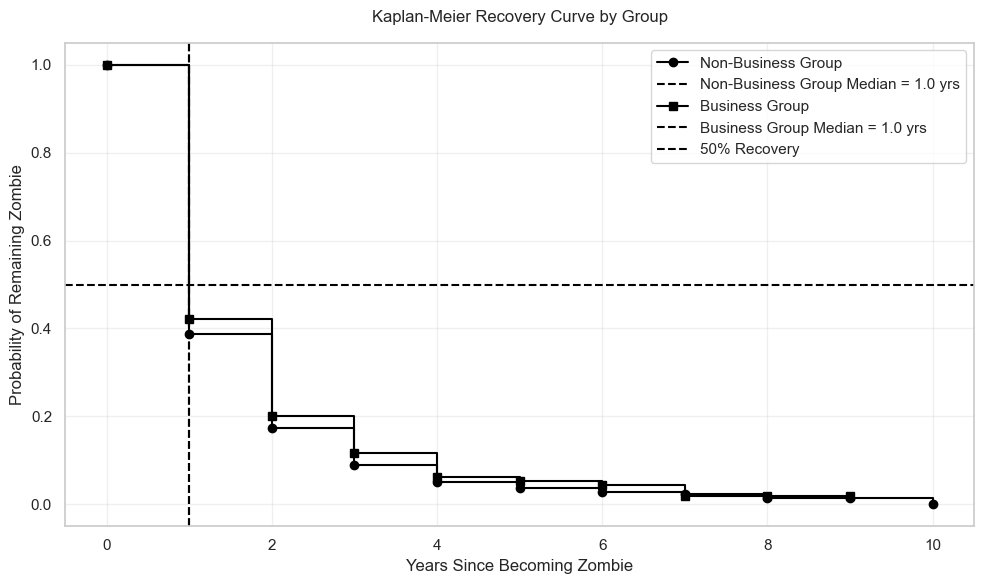

In [106]:
# Copy and sort data
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Step-by-step zombie spell construction
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount()
df['Event'] = ((df['Zombie'] == 0) & (df['Prev_Zombie'] == 1)).astype(int)

# Keep only zombie spells that had a previous year as zombie
df_zombie_exit = df[df['Prev_Zombie'] == 1].copy()

# --- Single combined plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# Group definitions, labels and markers
group_labels = {0: "Non-Business Group", 1: "Business Group"}
markers = {0: 'o', 1: 's'}

# Plot each group
for group_val in [0, 1]:
    group_df = df_zombie_exit[df_zombie_exit['Group Dummy'] == group_val]

    if group_df.empty:
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(group_df['Duration'], event_observed=group_df['Event'], label=group_labels[group_val])

    # Plot manually in black with markers
    ax.step(kmf.survival_function_.index,
        kmf.survival_function_[group_labels[group_val]],
        where='post',
        color='black',
        marker=markers[group_val],
        linestyle='-',
        label=group_labels[group_val])

    # Plot median survival line
    ax.axvline(x=kmf.median_survival_time_, color='black', linestyle='--',
               label=f"{group_labels[group_val]} Median = {kmf.median_survival_time_:.1f} yrs")

# Add horizontal 50% recovery reference
ax.axhline(y=0.5, color='black', linestyle='--', label='50% Recovery')

# Formatting
ax.set_title("Kaplan-Meier Recovery Curve by Group", pad=15)
ax.set_xlabel("Years Since Becoming Zombie")
ax.set_ylabel("Probability of Remaining Zombie")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

# Save and show
plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Recovery_Comparison.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [107]:
# Split the data into the two groups for the log-rank test
group0 = df_zombie_exit[df_zombie_exit['Group Dummy'] == 0]
group1 = df_zombie_exit[df_zombie_exit['Group Dummy'] == 1]

# Run the log-rank test
results = logrank_test(
    group0['Duration'], group1['Duration'],
    event_observed_A=group0['Event'], event_observed_B=group1['Event']
)

# Print the test results
results

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          14.45 <0.005     12.76

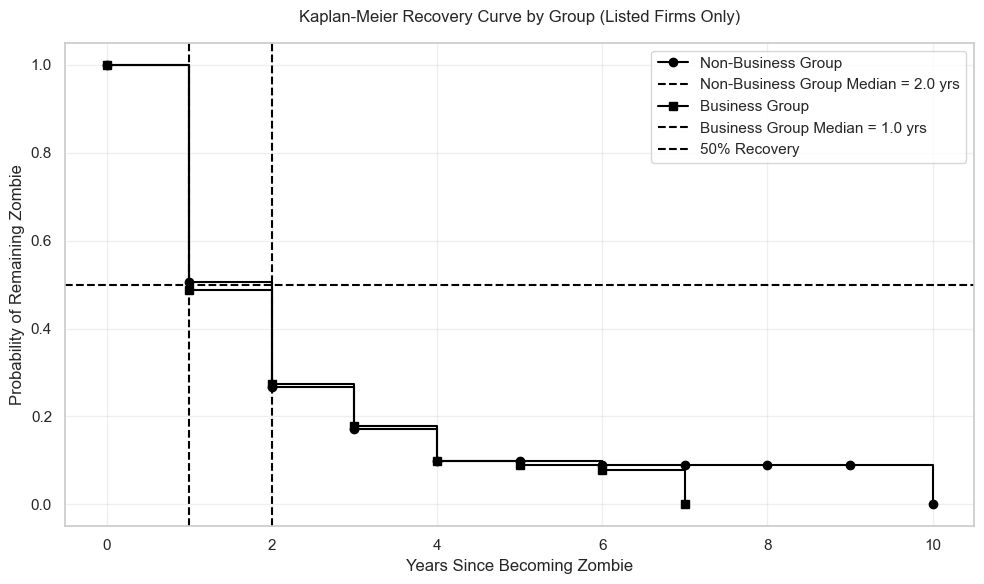

In [108]:
# Copy and sort data
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Step-by-step zombie spell construction
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount()
df['Event'] = ((df['Zombie'] == 0) & (df['Prev_Zombie'] == 1)).astype(int)

# Keep only zombie spells that had a previous year as zombie
df_zombie_exit = df[df['Prev_Zombie'] == 1].copy()

# Filter for listed firms only
df_zombie_exit = df_zombie_exit[df_zombie_exit['listed firm'] == 1]

# --- Single combined plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# Group definitions, labels and markers
group_labels = {0: "Non-Business Group", 1: "Business Group"}
markers = {0: 'o', 1: 's'}

# Plot each group
for group_val in [0, 1]:
    group_df = df_zombie_exit[df_zombie_exit['Group Dummy'] == group_val]

    if group_df.empty:
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(group_df['Duration'], event_observed=group_df['Event'], label=group_labels[group_val])

    # Plot manually in black with markers
    ax.step(kmf.survival_function_.index,
            kmf.survival_function_[group_labels[group_val]],
            where='post',
            color='black',
            marker=markers[group_val],
            linestyle='-',
            label=group_labels[group_val])

    # Plot median survival line
    median_time = kmf.median_survival_time_
    if median_time and median_time != float('inf'):
        ax.axvline(x=median_time, color='black', linestyle='--',
                   label=f"{group_labels[group_val]} Median = {median_time:.1f} yrs")

# Add horizontal 50% recovery reference
ax.axhline(y=0.5, color='black', linestyle='--', label='50% Recovery')

# Formatting
ax.set_title("Kaplan-Meier Recovery Curve by Group (Listed Firms Only)", pad=15)
ax.set_xlabel("Years Since Becoming Zombie")
ax.set_ylabel("Probability of Remaining Zombie")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

# Save and show
plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Recovery_LISTED_ONLY.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [109]:
# Filter for listed firms only
df_listed = df_zombie_exit[df_zombie_exit['listed firm'] == 1].copy()

# Split into two groups
group0 = df_listed[df_listed['Group Dummy'] == 0]
group1 = df_listed[df_listed['Group Dummy'] == 1]

# Run log-rank test
results = logrank_test(
    durations_A=group0['Duration'],
    durations_B=group1['Duration'],
    event_observed_A=group0['Event'],
    event_observed_B=group1['Event']
)

results

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.30 0.59      0.77

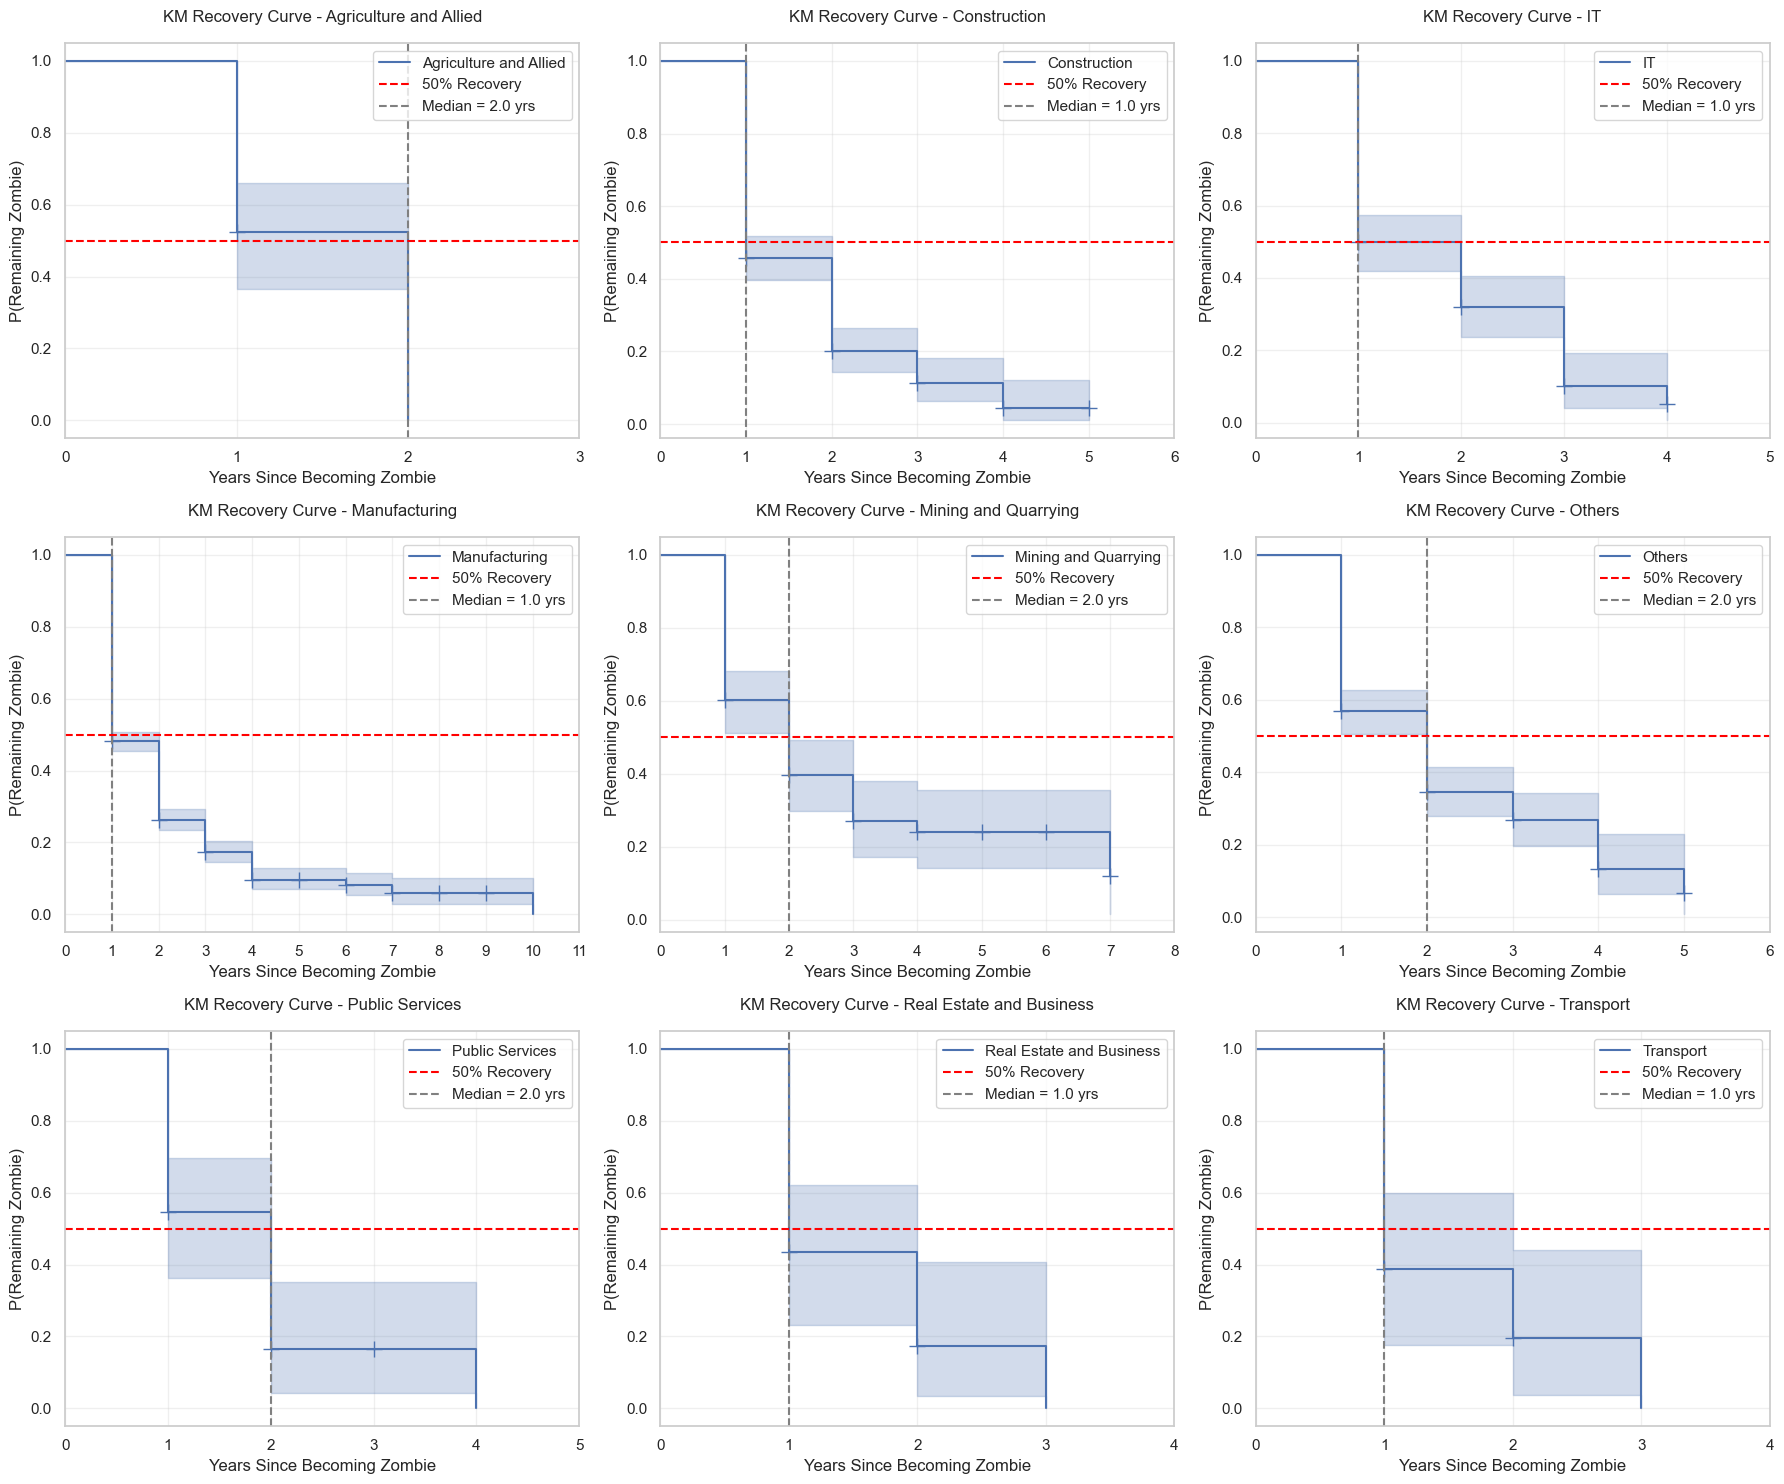

In [110]:
# List of unique industries
industry_list = df_zombie_exit['Industry_Group'].dropna().unique()
industry_list.sort()

# Subplot setup
n = len(industry_list)
cols = 3
rows = (n + cols - 1) // cols  # Ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharey=False)
axes = axes.flatten()

# Plot each industry's KM curve
for i, industry in enumerate(industry_list):
    ax = axes[i]
    industry_df = df_zombie_exit[df_zombie_exit['Industry_Group'] == industry]

    if industry_df.empty:
        ax.set_title(f"No data for {industry}")
        ax.axis('off')
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(industry_df['Duration'], event_observed=industry_df['Event'], label=industry)

    kmf.plot(ax=ax, ci_show=True, show_censors=True)
    ax.axhline(y=0.5, color='red', linestyle='--', label='50% Recovery')

    median = kmf.median_survival_time_
    if median is not None:
        ax.axvline(x=median, color='gray', linestyle='--', label=f'Median = {median:.1f} yrs')

    ax.set_title(f"KM Recovery Curve - {industry}", pad=15)
    ax.set_xlabel("Years Since Becoming Zombie")
    ax.set_ylabel("P(Remaining Zombie)")

    # --- Dynamic x-axis range based on max duration ---
    max_duration = int(industry_df['Duration'].max())
    ax.set_xlim(0, max_duration)
    ax.set_xticks(np.arange(0, max_duration + 2, 1))

    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

# Turn off unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Recovery_By_Industry.tiff', dpi=1000, bbox_inches='tight')
plt.show()

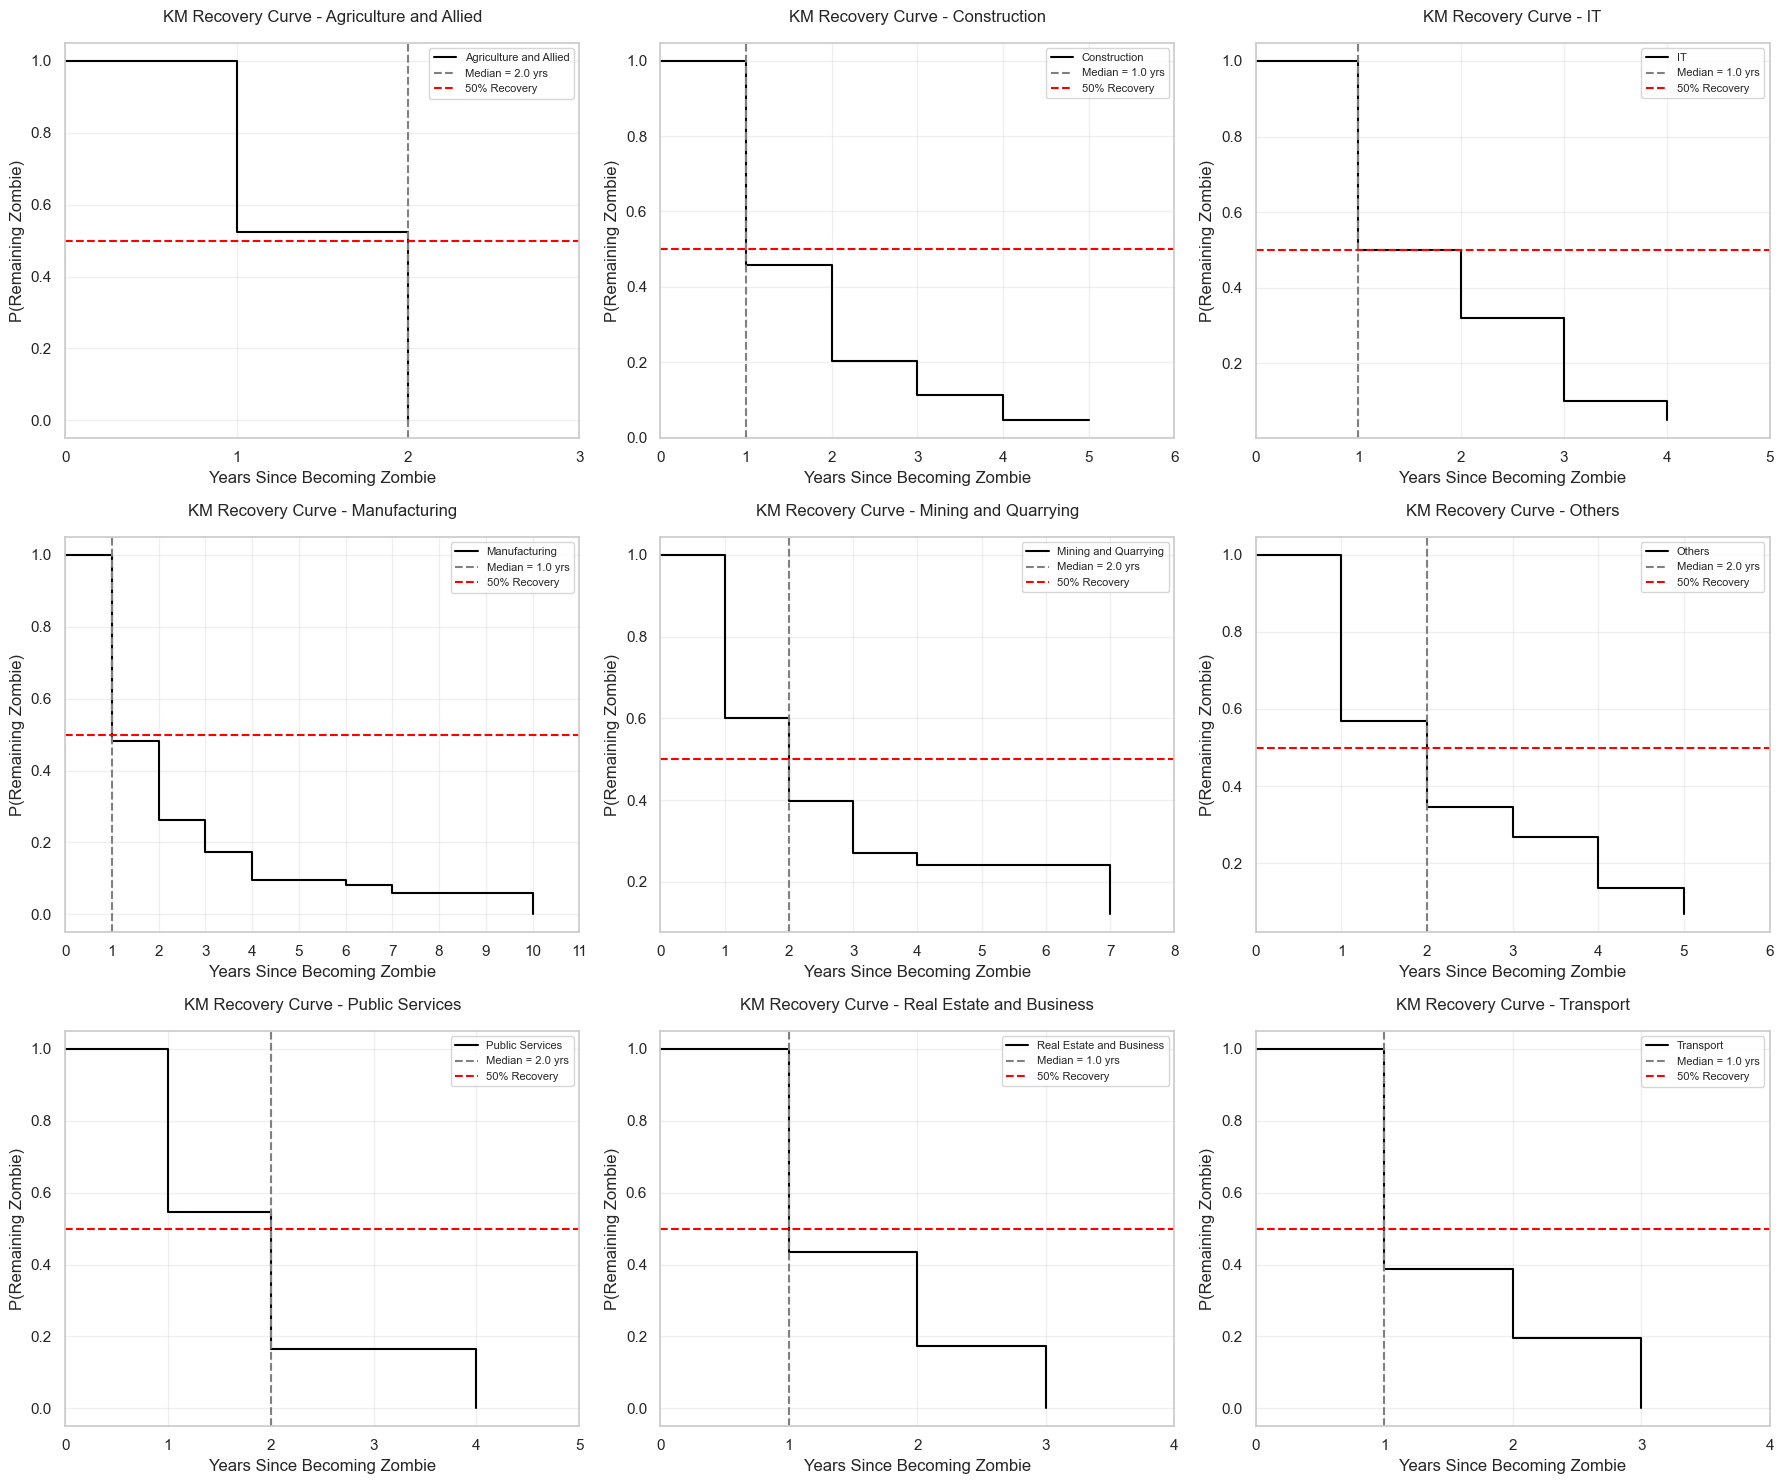

In [111]:
# List of unique industries
industry_list = df_zombie_exit['Industry_Group'].dropna().unique()
industry_list.sort()

# Subplot setup
n = len(industry_list)
cols = 3
rows = (n + cols - 1) // cols  # Ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharey=False)
axes = axes.flatten()


# Plot each industry's KM curve
for i, industry in enumerate(industry_list):
    ax = axes[i]
    industry_df = df_zombie_exit[df_zombie_exit['Industry_Group'] == industry]

    if industry_df.empty:
        ax.set_title(f"No data for {industry}")
        ax.axis('off')
        continue

    # Fit Kaplan-Meier model
    kmf = KaplanMeierFitter()
    kmf.fit(industry_df['Duration'], event_observed=industry_df['Event'])

    # Get survival function
    survival_curve = kmf.survival_function_
    survival_values = survival_curve[kmf.survival_function_.columns[0]]
    durations = survival_curve.index

    # Plot step line in black
    ax.step(durations, survival_values, where='post', color='black', linestyle='-', label=industry)

    # Overlay markers on the steps
    ax.plot(durations, survival_values, linestyle='', color='black')

    # Add vertical median line if available
    median = kmf.median_survival_time_
    if median is not None:
        ax.axvline(x=median, color='gray', linestyle='--', label=f'Median = {median:.1f} yrs')

    # Add 50% recovery line
    ax.axhline(y=0.5, color='red', linestyle='--', label='50% Recovery')

    # Axis labels and limits
    ax.set_title(f"KM Recovery Curve - {industry}", pad=15)
    ax.set_xlabel("Years Since Becoming Zombie")
    ax.set_ylabel("P(Remaining Zombie)")

    max_duration = int(industry_df['Duration'].max())
    ax.set_xlim(0, max_duration)
    ax.set_xticks(np.arange(0, max_duration + 2, 1))

    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

# Turn off unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Final layout and save
plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Recovery_By_Industry.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [112]:
# Prepare the data
df_valid = df_zombie_exit.dropna(subset=['Industry_Group']).copy()

# Filter out industries with small sample sizes
min_firms = 10
industry_counts = df_valid['Industry_Group'].value_counts()
valid_industries = industry_counts[industry_counts >= min_firms].index.tolist()

# Filter the dataset to only include valid industries
df_valid = df_valid[df_valid['Industry_Group'].isin(valid_industries)]

# Perform multivariate log-rank test
results = multivariate_logrank_test(
    df_valid['Duration'],
    df_valid['Industry_Group'],
    df_valid['Event']
)
results

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 8
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          26.91 <0.005     10.42

## KPM for continuation of Zombie Firms

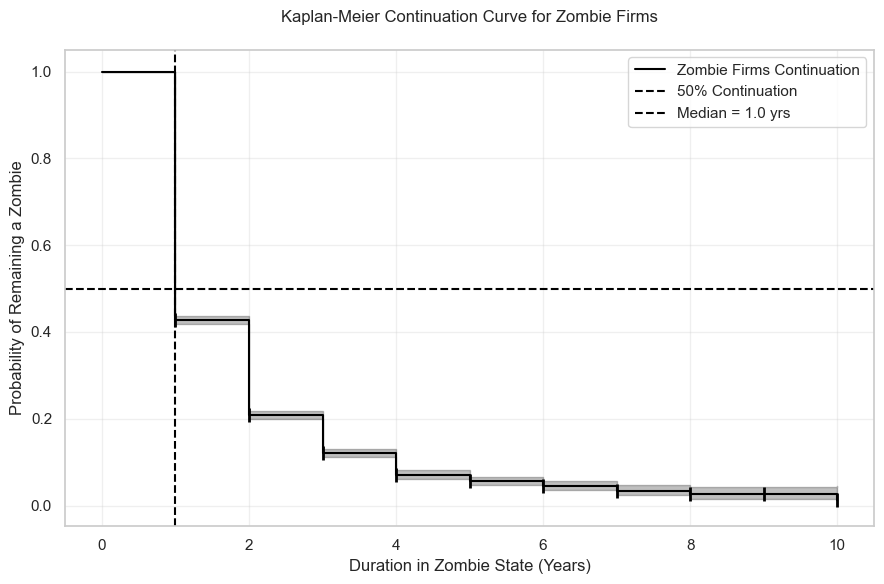

Time Period (years),Probability of Remaining Zombie,Probability of Exit,Median Continuation Time,Firm-Years
1,42.7%,57.3%,1.0,11424
3,12.0%,88.0%,1.0,11424
5,5.6%,94.4%,1.0,11424


In [113]:
# Make a working copy and sort by company and year
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Convert categorical zombie status to binary (1 = Zombie, 0 = Non-Zombie)
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)

# Identify the start of new zombie spells
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)

# Assign a unique spell ID for each zombie episode
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()

# Calculate duration within each zombie spell (start counting from 1)
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount() + 1

# Look ahead to identify when the zombie spell ends
df['Next_Zombie'] = df.groupby('Company Name')['Zombie'].shift(-1)

# Keep only zombie years (active spells)
df = df[df['Zombie'] == 1].copy()

# Define recovery event: 1 if zombie spell ends next year, 0 otherwise
df['Event'] = (df['Next_Zombie'] == 0).astype(int)

# === Kaplan-Meier Estimation ===
kmf = KaplanMeierFitter()
kmf.fit(durations=df['Duration'], event_observed=df['Event'], label='Zombie Firms Continuation')

# Get median continuation time
median_continuation_time = kmf.median_survival_time_

# === Plotting ===
plt.figure(figsize=(9, 6))
ax = kmf.plot(ci_show=True, show_censors=True, color='black',
              censor_styles={'marker': '|', 'ms': 10, 'mew': 2})

# Add 50% survival lines
plt.axhline(y=0.5, color='black', linestyle='--', label='50% Continuation')
plt.axvline(x=median_continuation_time, color='black', linestyle='--',
            label=f'Median = {median_continuation_time:.1f} yrs')

# Formatting
plt.title('Kaplan-Meier Continuation Curve for Zombie Firms', pad=20)
plt.xlabel('Duration in Zombie State (Years)')
plt.ylabel('Probability of Remaining a Zombie')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Continuation.tiff', dpi=1000, bbox_inches='tight')
plt.show()

# === Structured Statistics Table ===
time_points = [1, 3, 5]
survival_probs = kmf.predict(time_points)

# Create table data
continuation_stats = {
    'Time Period (years)': time_points,
    'Probability of Remaining Zombie': survival_probs,
    'Probability of Exit': 1 - survival_probs,
    'Median Continuation Time': [median_continuation_time] * len(time_points),
    'Firm-Years': [len(df)] * len(time_points)
}

# Create DataFrame
continuation_df = pd.DataFrame(continuation_stats)

# Style and format
formatted_stats = continuation_df.style.format({
    'Probability of Remaining Zombie': '{:.1%}',
    'Probability of Exit': '{:.1%}',
    'Median Continuation Time': '{:.1f}'
}).hide(axis='index')

# Display formatted table
display(formatted_stats)

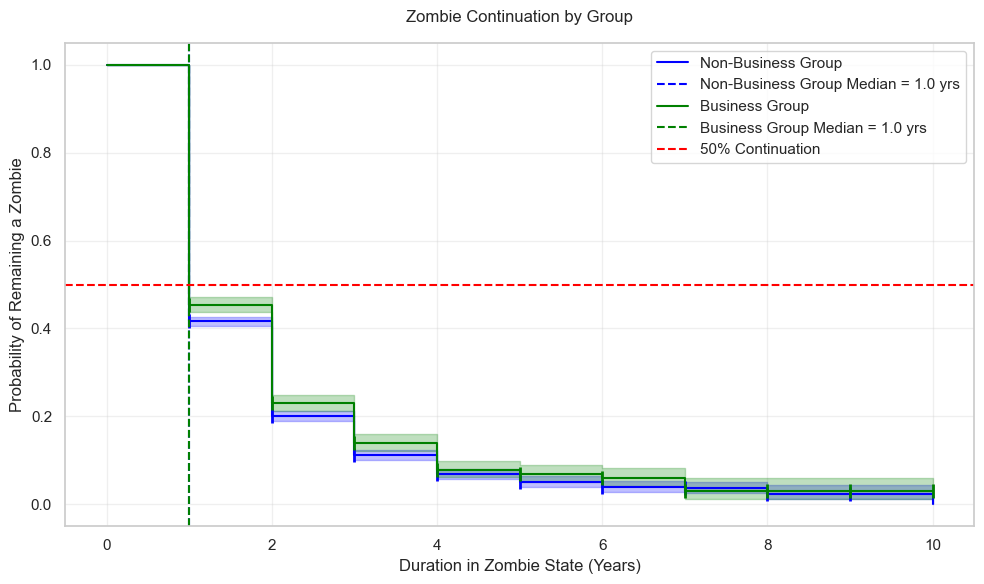

Group,Time Period (years),Probability of Remaining Zombie,Probability of Exit,Median Continuation Time,Firm-Years
Non-Business Group,1,41.6%,58.4%,1.0,8127
Non-Business Group,3,11.2%,88.8%,1.0,8127
Non-Business Group,5,5.1%,94.9%,1.0,8127
Business Group,1,45.4%,54.6%,1.0,3297
Business Group,3,14.0%,86.0%,1.0,3297
Business Group,5,6.8%,93.2%,1.0,3297


In [114]:
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Construct zombie spell
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount() + 1
df['Next_Zombie'] = df.groupby('Company Name')['Zombie'].shift(-1)
df = df[df['Zombie'] == 1].copy()
df['Event'] = (df['Next_Zombie'] == 0).astype(int)

# --- Single Plot Setup ---
fig, ax = plt.subplots(figsize=(10, 6))

group_labels = {0: "Non-Business Group", 1: "Business Group"}
colors = {0: 'blue', 1: 'green'}
time_points = [1, 3, 5]

# Collect stats for summary table
summary_tables = []

# Loop through groups and overlay curves
for group_val in [0, 1]:
    group_df = df[df['Group Dummy'] == group_val].copy()

    if group_df.empty:
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(durations=group_df['Duration'], event_observed=group_df['Event'],
            label=group_labels[group_val])
    
    kmf.plot(ax=ax, ci_show=True, show_censors=True, color=colors[group_val],
             censor_styles={'marker': '|', 'ms': 10, 'mew': 2})
    
    median_time = kmf.median_survival_time_
    ax.axvline(x=median_time, color=colors[group_val], linestyle='--',
               label=f"{group_labels[group_val]} Median = {median_time:.1f} yrs")

    # Collect stats
    survival_probs = kmf.predict(time_points)
    summary_tables.append(pd.DataFrame({
        'Group': group_labels[group_val],
        'Time Period (years)': time_points,
        'Probability of Remaining Zombie': survival_probs,
        'Probability of Exit': 1 - survival_probs,
        'Median Continuation Time': [median_time] * len(time_points),
        'Firm-Years': [len(group_df)] * len(time_points)
    }))

# Formatting
ax.axhline(y=0.5, color='red', linestyle='--', label='50% Continuation')
ax.set_title("Zombie Continuation by Group", pad=15)
ax.set_xlabel("Duration in Zombie State (Years)")
ax.set_ylabel("Probability of Remaining a Zombie")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

# Save and show plot
plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Continuation_Comparison.tiff', dpi=1000, bbox_inches='tight')
plt.show()

# --- Combine and Display Summary Table ---
final_table = pd.concat(summary_tables, ignore_index=True)

formatted_table = final_table.style.format({
    'Probability of Remaining Zombie': '{:.1%}',
    'Probability of Exit': '{:.1%}',
    'Median Continuation Time': '{:.1f}'
}).hide(axis='index')

display(formatted_table)

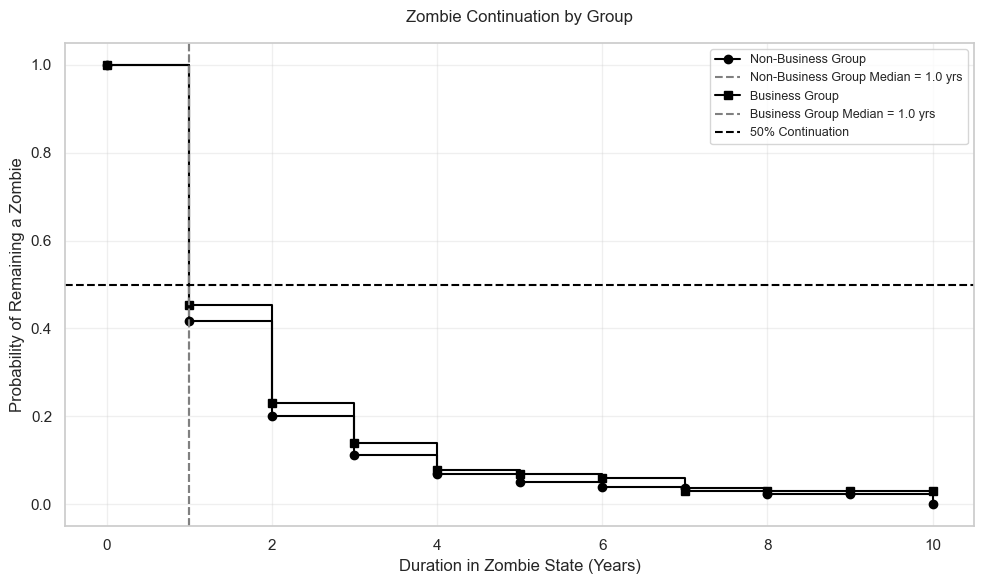

Group,Time Period (years),Probability of Remaining Zombie,Probability of Exit,Median Continuation Time,Firm-Years
Non-Business Group,1,41.6%,58.4%,1.0,8127
Non-Business Group,3,11.2%,88.8%,1.0,8127
Non-Business Group,5,5.1%,94.9%,1.0,8127
Business Group,1,45.4%,54.6%,1.0,3297
Business Group,3,14.0%,86.0%,1.0,3297
Business Group,5,6.8%,93.2%,1.0,3297


In [115]:
# Prepare data
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Construct zombie spell
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount() + 1
df['Next_Zombie'] = df.groupby('Company Name')['Zombie'].shift(-1)
df = df[df['Zombie'] == 1].copy()
df['Event'] = (df['Next_Zombie'] == 0).astype(int)

# Setup for plotting
fig, ax = plt.subplots(figsize=(10, 6))
group_labels = {0: "Non-Business Group", 1: "Business Group"}
marker_styles = itertools.cycle(['o', 's'])  # one per group
time_points = [1, 3, 5]
summary_tables = []

# Plot each group
for group_val in [0, 1]:
    group_df = df[df['Group Dummy'] == group_val].copy()
    if group_df.empty:
        continue

    kmf = KaplanMeierFitter()
    label = group_labels[group_val]
    kmf.fit(group_df['Duration'], event_observed=group_df['Event'], label=label)

    survival_curve = kmf.survival_function_
    survival_values = survival_curve[kmf.survival_function_.columns[0]]
    durations = survival_curve.index
    marker = next(marker_styles)

    # Plot the step line without markers, no legend
    ax.step(durations, survival_values, where='post', color='black', linestyle='-', label='_nolegend_')

    # Plot markers aligned with the step positions, no legend
    ax.plot(durations, survival_values, linestyle='', marker=marker, color='black', label='_nolegend_')

    # Plot an invisible line with marker+line just for legend
    ax.plot([], [], linestyle='-', marker=marker, color='black', label=group_labels[group_val])


    # Vertical median survival line
    median_time = kmf.median_survival_time_
    if median_time is not None:
        ax.axvline(x=median_time, color='gray', linestyle='--', label=f"{label} Median = {median_time:.1f} yrs")

    # Collect statistics
    survival_probs = kmf.predict(time_points)
    summary_tables.append(pd.DataFrame({
        'Group': label,
        'Time Period (years)': time_points,
        'Probability of Remaining Zombie': survival_probs.values,
        'Probability of Exit': 1 - survival_probs.values,
        'Median Continuation Time': [median_time] * len(time_points),
        'Firm-Years': [len(group_df)] * len(time_points)
    }))

# Plot formatting
ax.axhline(y=0.5, color='black', linestyle='--', label='50% Continuation')
ax.set_title("Zombie Continuation by Group", pad=15)
ax.set_xlabel("Duration in Zombie State (Years)")
ax.set_ylabel("Probability of Remaining a Zombie")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)

# Save and show
plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Continuation_Comparison.tiff', dpi=1000, bbox_inches='tight')
plt.show()

# Combine and display summary table
final_table = pd.concat(summary_tables, ignore_index=True)

formatted_table = final_table.style.format({
    'Probability of Remaining Zombie': '{:.1%}',
    'Probability of Exit': '{:.1%}',
    'Median Continuation Time': '{:.1f}'
}).hide(axis='index')

display(formatted_table)

In [116]:
# Subset data for each group
group_0 = df[df['Group Dummy'] == 0]
group_1 = df[df['Group Dummy'] == 1]

# Perform log-rank test
results = logrank_test(
    group_0['Duration'], group_1['Duration'],
    event_observed_A=group_0['Event'],
    event_observed_B=group_1['Event']
)

# Print results
results

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          15.90 <0.005     13.87

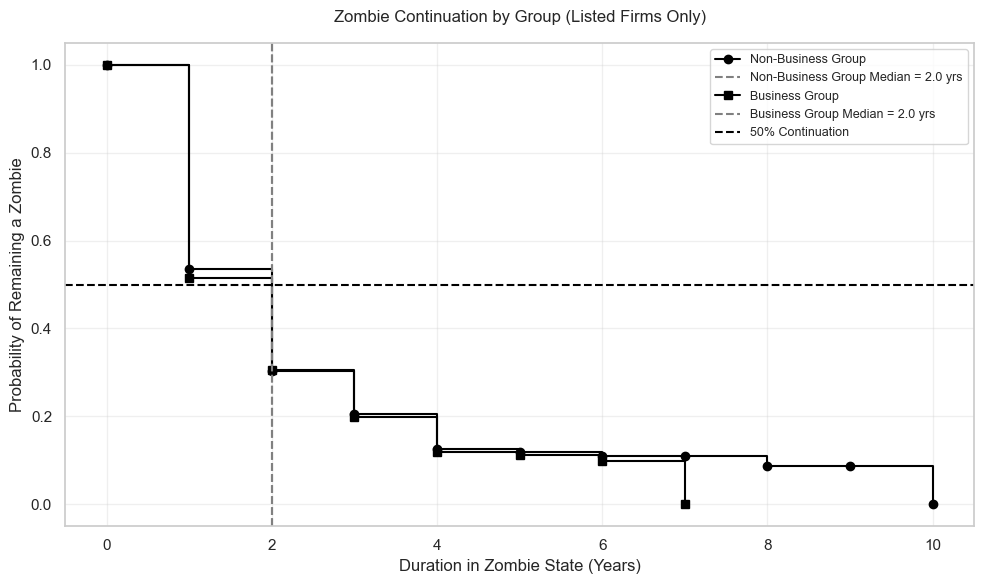

In [117]:
# Prepare data
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Construct zombie spell
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount() + 1
df['Next_Zombie'] = df.groupby('Company Name')['Zombie'].shift(-1)
df = df[df['Zombie'] == 1].copy()
df['Event'] = (df['Next_Zombie'] == 0).astype(int)

# Filter for listed firms only
df = df[df['listed firm'] == 1].copy()

# Setup for plotting
fig, ax = plt.subplots(figsize=(10, 6))
group_labels = {0: "Non-Business Group", 1: "Business Group"}
marker_styles = itertools.cycle(['o', 's'])
time_points = [1, 3, 5]
summary_tables = []

# Plot each group
for group_val in [0, 1]:
    group_df = df[df['Group Dummy'] == group_val].copy()
    if group_df.empty:
        continue

    kmf = KaplanMeierFitter()
    label = group_labels[group_val]
    kmf.fit(group_df['Duration'], event_observed=group_df['Event'], label=label)

    survival_curve = kmf.survival_function_
    survival_values = survival_curve[kmf.survival_function_.columns[0]]
    durations = survival_curve.index
    marker = next(marker_styles)

    ax.step(durations, survival_values, where='post', color='black', linestyle='-', label='_nolegend_')
    ax.plot(durations, survival_values, linestyle='', marker=marker, color='black', label='_nolegend_')
    ax.plot([], [], linestyle='-', marker=marker, color='black', label=group_labels[group_val])

    median_time = kmf.median_survival_time_
    if median_time is not None:
        ax.axvline(x=median_time, color='gray', linestyle='--', label=f"{label} Median = {median_time:.1f} yrs")

    survival_probs = kmf.predict(time_points)
    summary_tables.append(pd.DataFrame({
        'Group': label,
        'Time Period (years)': time_points,
        'Probability of Remaining Zombie': survival_probs.values,
        'Probability of Exit': 1 - survival_probs.values,
        'Median Continuation Time': [median_time] * len(time_points),
        'Firm-Years': [len(group_df)] * len(time_points)
    }))

# Plot formatting
ax.axhline(y=0.5, color='black', linestyle='--', label='50% Continuation')
ax.set_title("Zombie Continuation by Group (Listed Firms Only)", pad=15)
ax.set_xlabel("Duration in Zombie State (Years)")
ax.set_ylabel("Probability of Remaining a Zombie")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Continuation_LISTED_ONLY.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [118]:
# Filter for listed firms only
df_listed = df[df['listed firm'] == 1].copy()

# Split into two groups
group0 = df_listed[df_listed['Group Dummy'] == 0]
group1 = df_listed[df_listed['Group Dummy'] == 1]

# Run log-rank test
results = logrank_test(
    group0['Duration'],
    group1['Duration'],
    event_observed_A=group0['Event'],
    event_observed_B=group1['Event']
)

results

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.63 0.43      1.23

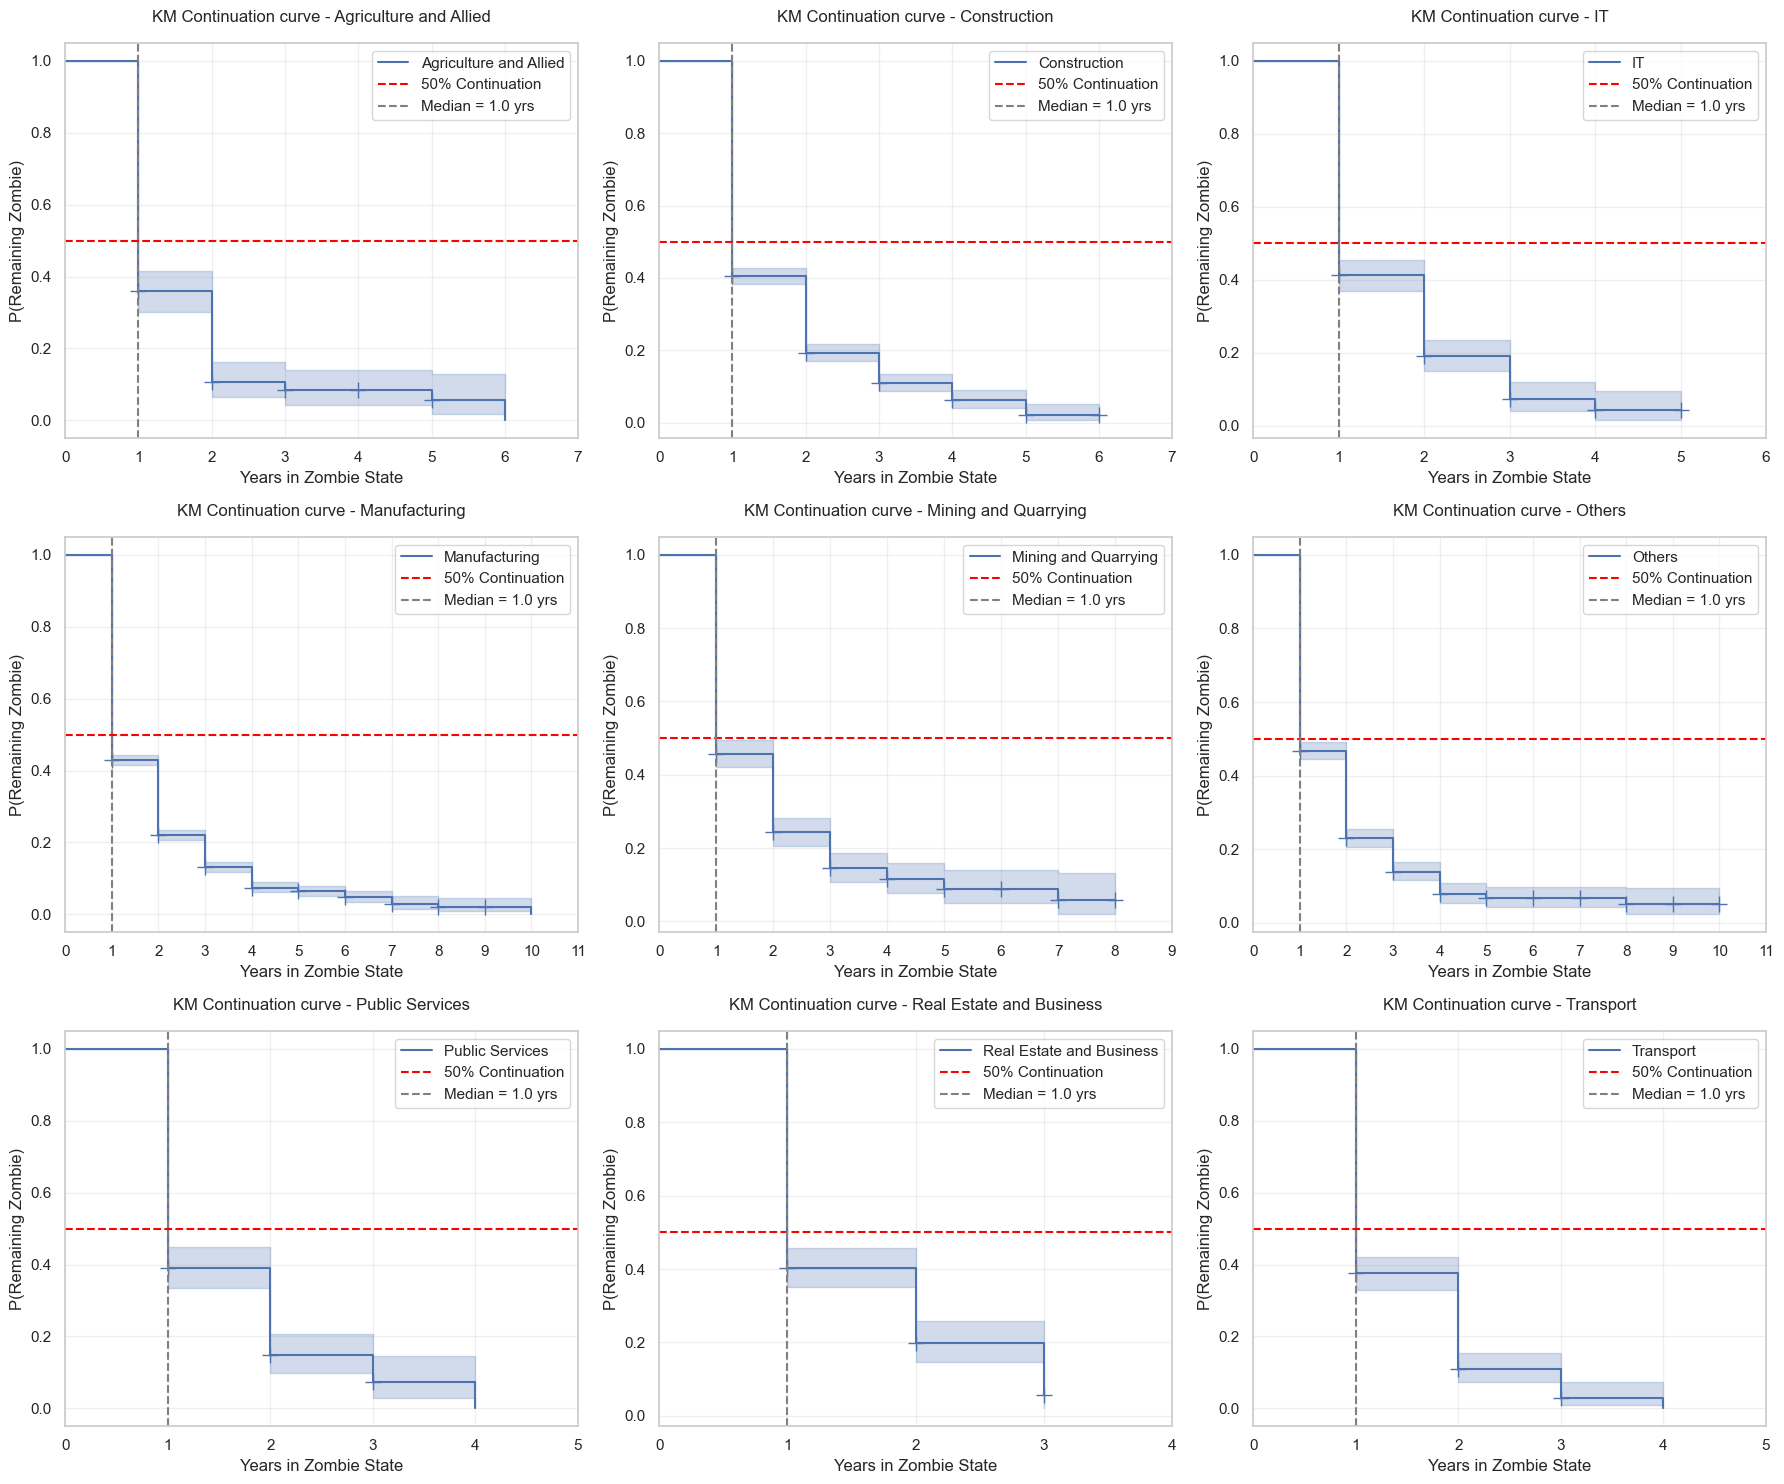

In [119]:
# Prepare data
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount() + 1
df['Next_Zombie'] = df.groupby('Company Name')['Zombie'].shift(-1)
df = df[df['Zombie'] == 1].copy()
df['Event'] = (df['Next_Zombie'] == 0).astype(int)

# Unique industries
industry_list = df['Industry_Group'].dropna().unique()
industry_list.sort()

# Plot setup
n = len(industry_list)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharey=False)
axes = axes.flatten()

# Plot each industry's KM continuation curve
for i, industry in enumerate(industry_list):
    ax = axes[i]
    industry_df = df[df['Industry_Group'] == industry]

    if industry_df.empty:
        ax.set_title(f"No data for {industry}")
        ax.axis('off')
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(industry_df['Duration'], event_observed=industry_df['Event'], label=industry)

    kmf.plot(ax=ax, ci_show=True, show_censors=True)
    ax.axhline(y=0.5, color='red', linestyle='--', label='50% Continuation')
    
    median = kmf.median_survival_time_
    if median is not None:
        ax.axvline(x=median, color='gray', linestyle='--', label=f'Median = {median:.1f} yrs')

    max_dur = int(industry_df['Duration'].max())
    ax.set_xlim(0, max_dur)
    ax.set_xticks(np.arange(0, max_dur + 2, 1))

    ax.set_title(f"KM Continuation curve - {industry}", pad=15)
    ax.set_xlabel("Years in Zombie State")
    ax.set_ylabel("P(Remaining Zombie)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

# Turn off unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Save and show
plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Continuation_By_Industry.tiff', dpi=1000, bbox_inches='tight')
plt.show()

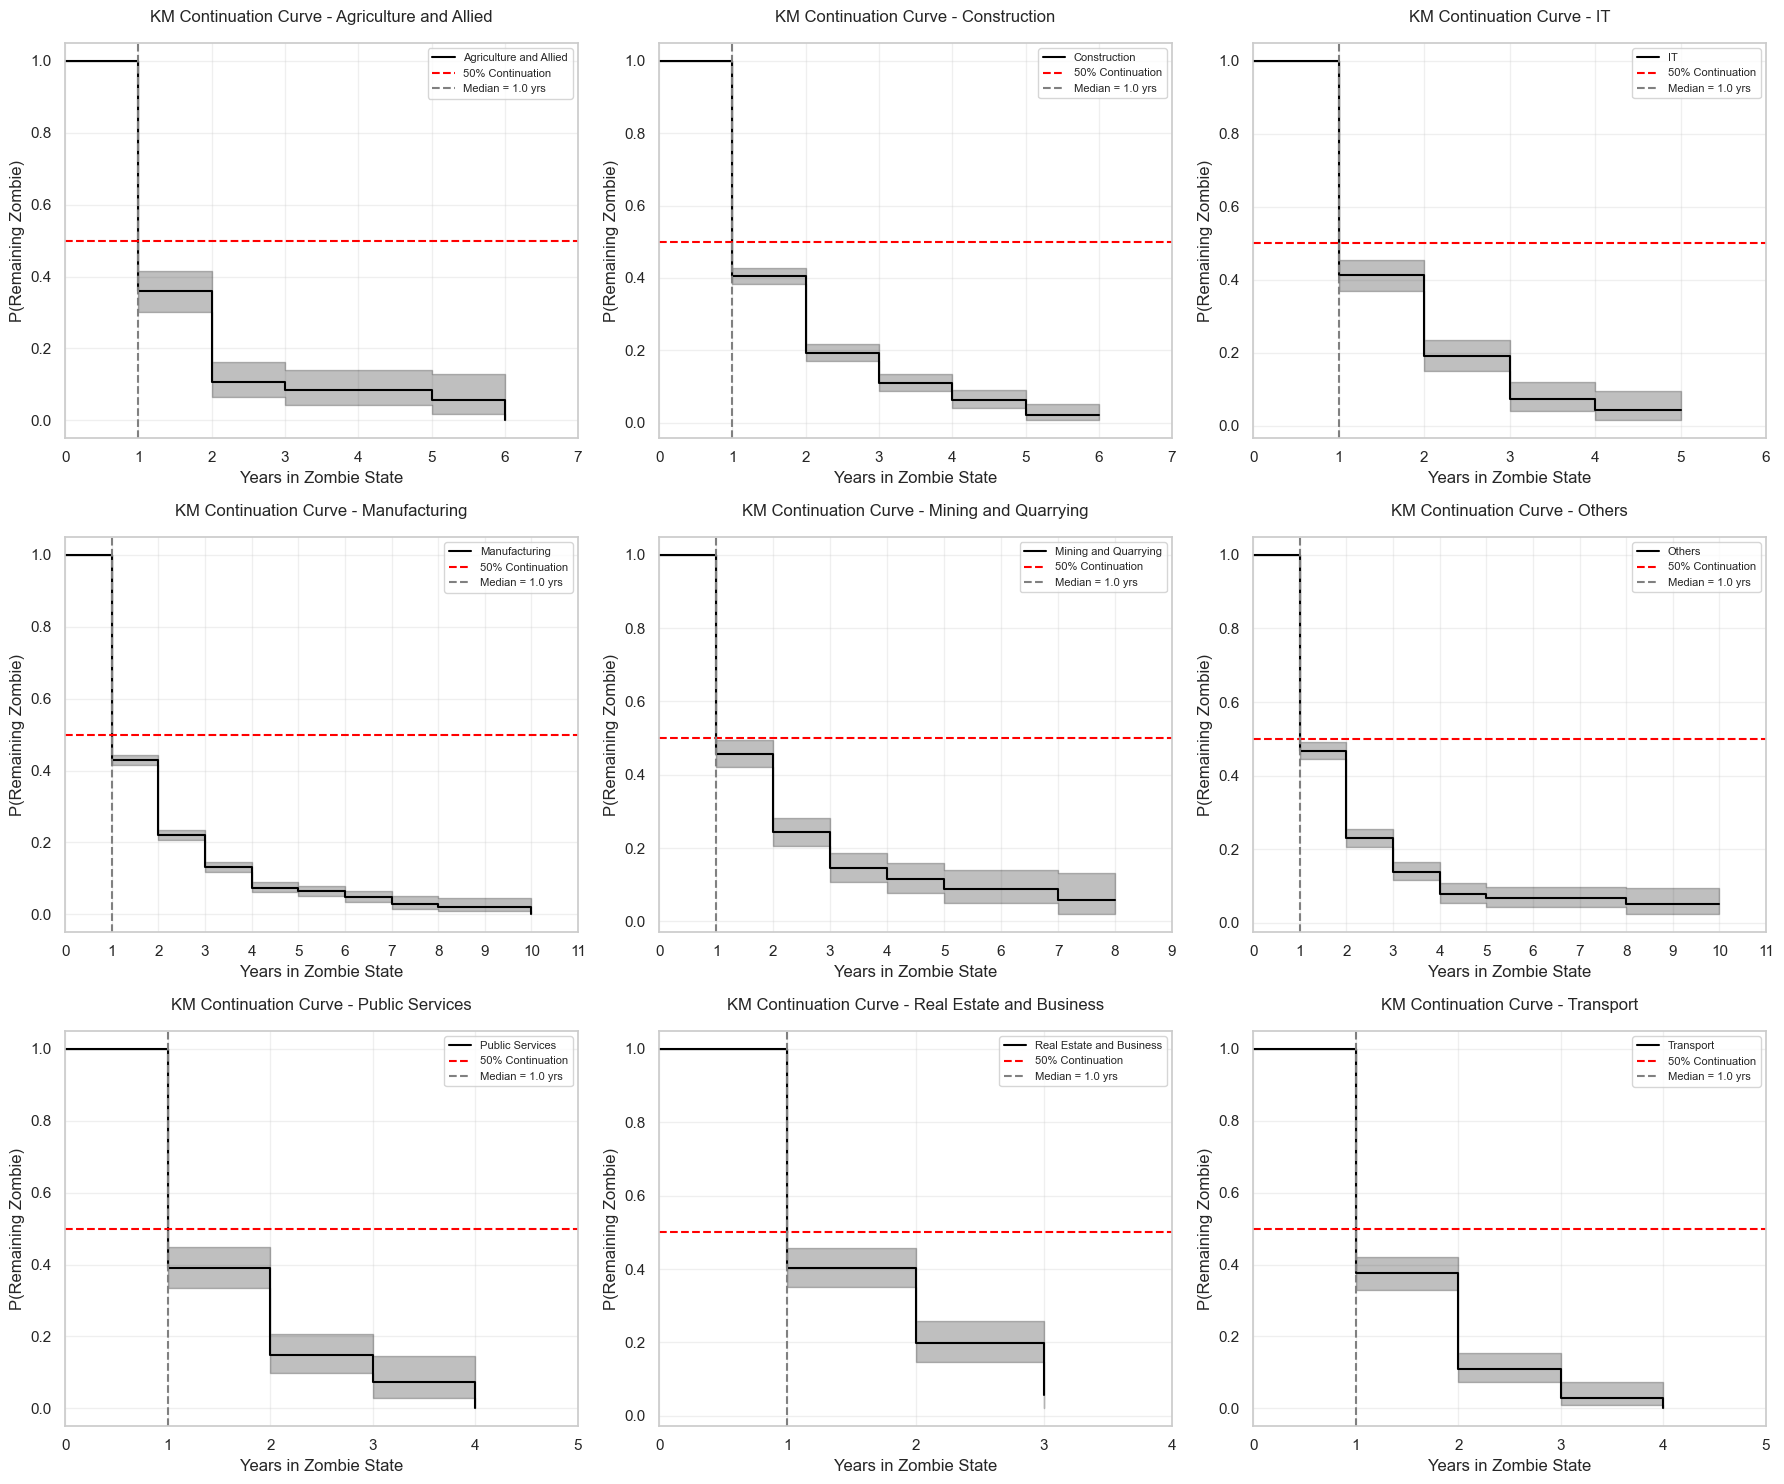

In [120]:
# Prepare data
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount() + 1
df['Next_Zombie'] = df.groupby('Company Name')['Zombie'].shift(-1)
df = df[df['Zombie'] == 1].copy()
df['Event'] = (df['Next_Zombie'] == 0).astype(int)

# Unique industries
industry_list = df['Industry_Group'].dropna().unique()
industry_list.sort()

# Plot setup
n = len(industry_list)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharey=False)
axes = axes.flatten()

# Plot each industry's KM continuation curve
for i, industry in enumerate(industry_list):
    ax = axes[i]
    industry_df = df[df['Industry_Group'] == industry]

    if industry_df.empty:
        ax.set_title(f"No data for {industry}")
        ax.axis('off')
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(industry_df['Duration'], event_observed=industry_df['Event'], label=industry)

    # Plot step curve in black, no markers, no censor symbols, with confidence intervals
    kmf.plot(ax=ax, ci_show=True, show_censors=False, color='black', linestyle='-')

    # 50% continuation horizontal line
    ax.axhline(y=0.5, color='red', linestyle='--', label='50% Continuation')
    
    # Median survival time vertical line
    median = kmf.median_survival_time_
    if median is not None:
        ax.axvline(x=median, color='gray', linestyle='--', label=f'Median = {median:.1f} yrs')

    max_dur = int(industry_df['Duration'].max())
    ax.set_xlim(0, max_dur)
    ax.set_xticks(np.arange(0, max_dur + 2, 1))

    ax.set_title(f"KM Continuation Curve - {industry}", pad=15)
    ax.set_xlabel("Years in Zombie State")
    ax.set_ylabel("P(Remaining Zombie)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

# Turn off unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Save and show
plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Continuation_By_Industry.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [121]:
# Only consider industries with enough data (e.g., ≥10 observations)
valid_industries = [
    industry for industry in df['Industry_Group'].unique()
    if len(df[df['Industry_Group'] == industry]) >= 10
]

# Filter dataset
df_valid = df[df['Industry_Group'].isin(valid_industries)].copy()

# Run multivariate log-rank test (correct argument order)
result = multivariate_logrank_test(
    df_valid['Duration'],               
    df_valid['Industry_Group'],            
    event_observed=df_valid['Event']       
)
result

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 8
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          48.03 <0.005     23.29

## Kaplan Meier for Healthy Firm Continuing to be Healthy

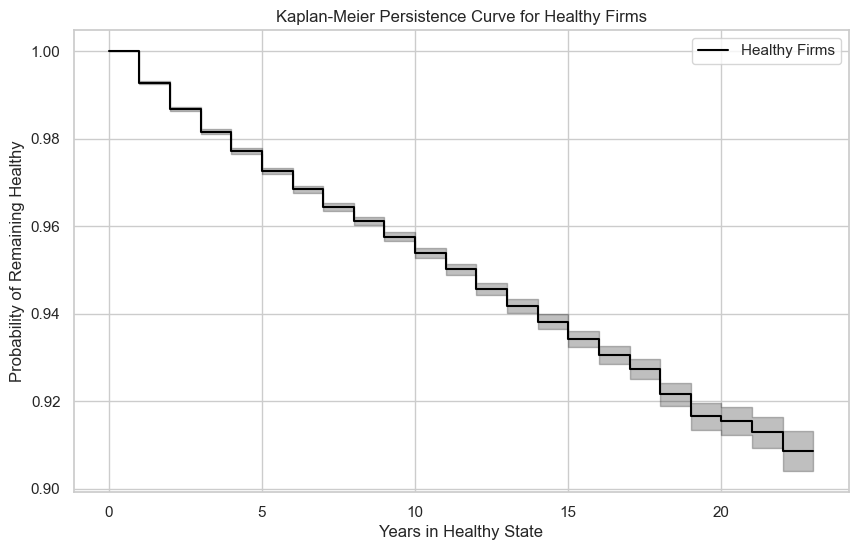

In [122]:
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Binary indicator for healthy status
df['Healthy'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Healthy' else 0)

# Identify start of new healthy spells
df['Prev_Healthy'] = df.groupby('Company Name')['Healthy'].shift(1, fill_value=0)
df['New_Healthy_Spell'] = (df['Healthy'] == 1) & (df['Prev_Healthy'] == 0)

# Assign unique spell IDs per firm
df['Healthy_Spell_ID'] = df.groupby('Company Name')['New_Healthy_Spell'].cumsum()

# Duration within each spell (Year 1, 2, ...)
df['Healthy_Duration'] = df.groupby(['Company Name', 'Healthy_Spell_ID']).cumcount() + 1

# Next year's health status (for event detection)
df['Next_Healthy'] = df.groupby('Company Name')['Healthy'].shift(-1)

# Keep only healthy years for analysis
df_healthy = df[df['Healthy'] == 1].copy()

# Event = 1 if firm exits healthy state next year
df_healthy['Event'] = (df_healthy['Next_Healthy'] == 0).astype(int)

# Censoring: Event = 0 if next year is missing (end of data)
df_healthy['Event'] = df_healthy['Event'].fillna(0).astype(int)

# Final survival data
survival_data = df_healthy[['Company Name', 'Year', 'Healthy_Duration', 'Event']]

# Kaplan-Meier Analysis
kmf = KaplanMeierFitter()
kmf.fit(durations=survival_data['Healthy_Duration'], 
        event_observed=survival_data['Event'], 
        label='Healthy Firms')

# Plot (probability of REMAINING healthy)
plt.figure(figsize=(10, 6))
kmf.plot_survival_function(color='black')
plt.title('Kaplan-Meier Persistence Curve for Healthy Firms')
plt.xlabel('Years in Healthy State')
plt.ylabel('Probability of Remaining Healthy')
plt.legend()
plt.savefig('Images/healthy_firm_persistence.tiff', dpi=1000, bbox_inches='tight')
plt.show()

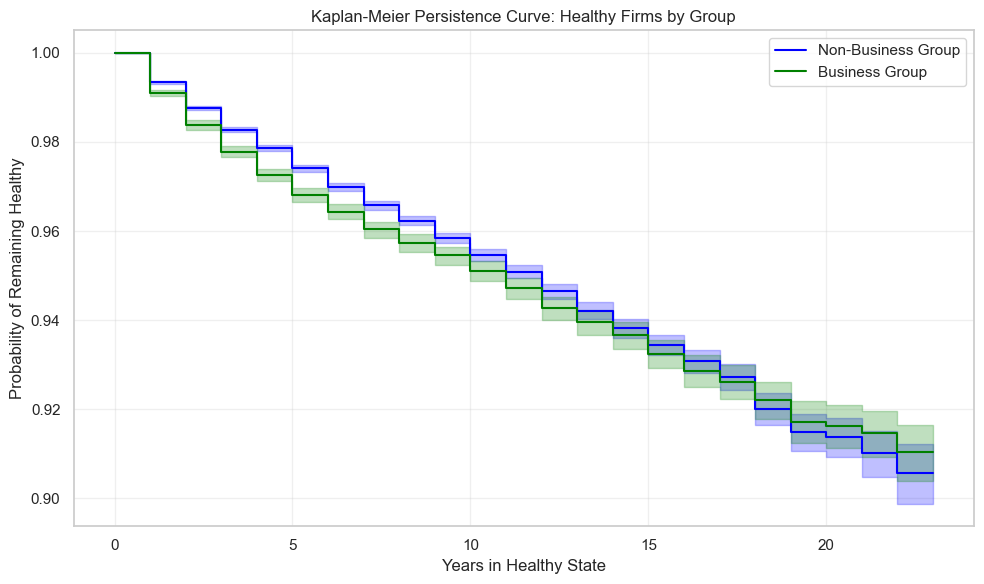

In [123]:
# Assuming 'Group Dummy' column exists with values: 0 = Non-Business Group, 1 = Business Group
group_labels = {0: "Non-Business Group", 1: "Business Group"}
colors = {0: 'blue', 1: 'green'}

fig, ax = plt.subplots(figsize=(10, 6))

for group_val in [0, 1]:
    group_df = df_healthy[df_healthy['Group Dummy'] == group_val]
    
    if group_df.empty:
        continue
    
    kmf = KaplanMeierFitter()
    kmf.fit(durations=group_df['Healthy_Duration'], 
            event_observed=group_df['Event'], 
            label=group_labels[group_val])
    
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[group_val])
    
    # Optional: add median survival time lines
    median_time = kmf.median_survival_time_
    if median_time is not None and median_time != float('inf'):
        ax.axvline(x=median_time, color=colors[group_val], linestyle='--',
                   label=f"{group_labels[group_val]} Median = {median_time:.1f} yrs")

ax.set_title("Kaplan-Meier Persistence Curve: Healthy Firms by Group")
ax.set_xlabel("Years in Healthy State")
ax.set_ylabel("Probability of Remaining Healthy")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Images/healthy_firm_persistence_by_group.tiff', dpi=1000, bbox_inches='tight')
plt.show()

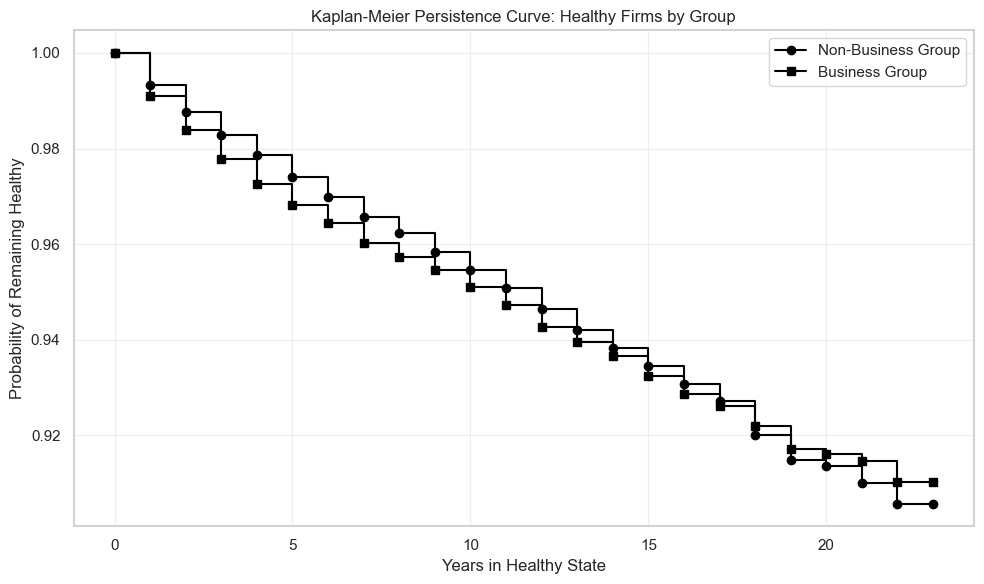

In [124]:
# Define marker styles and group labels
marker_styles = {0: 'o', 1: 's'}
group_labels = {0: "Non-Business Group", 1: "Business Group"}
color = 'black'  # all in black as per your requirement

fig, ax = plt.subplots(figsize=(10, 6))

legend_handles = []

for group_val in [0, 1]:
    group_df = df_healthy[df_healthy['Group Dummy'] == group_val]

    if group_df.empty:
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(durations=group_df['Healthy_Duration'], event_observed=group_df['Event'])

    survival = kmf.survival_function_
    durations = survival.index.values
    probs = survival.iloc[:, 0].values
    marker = marker_styles[group_val]

    # Plot step curve
    ax.step(durations, probs, where='post', color=color)
    # Add markers along the curve
    ax.plot(durations, probs, linestyle='', marker=marker, color=color)

    # Custom legend entry with marker
    handle = mlines.Line2D([], [], color=color, marker=marker, linestyle='-',
                           label=group_labels[group_val])
    legend_handles.append(handle)

    # Median vertical line
    median = kmf.median_survival_time_
    if median is not None and median != float('inf'):
        ax.axvline(x=median, color='gray', linestyle='--',
                   label=f"{group_labels[group_val]} Median = {median:.1f} yrs")

# Final plot formatting
ax.set_title("Kaplan-Meier Persistence Curve: Healthy Firms by Group")
ax.set_xlabel("Years in Healthy State")
ax.set_ylabel("Probability of Remaining Healthy")
ax.grid(True, alpha=0.3)

# Add custom legend
ax.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.savefig('Images/healthy_firm_persistence_by_group.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [125]:
# Split the data by group
group_0 = df_healthy[df_healthy['Group Dummy'] == 0]  # Non-Business Group
group_1 = df_healthy[df_healthy['Group Dummy'] == 1]  # Business Group

# Perform log-rank test
results = logrank_test(
    durations_A=group_0['Healthy_Duration'],
    durations_B=group_1['Healthy_Duration'],
    event_observed_A=group_0['Event'],
    event_observed_B=group_1['Event']
)

# Print results
results

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          20.61 <0.005     17.44

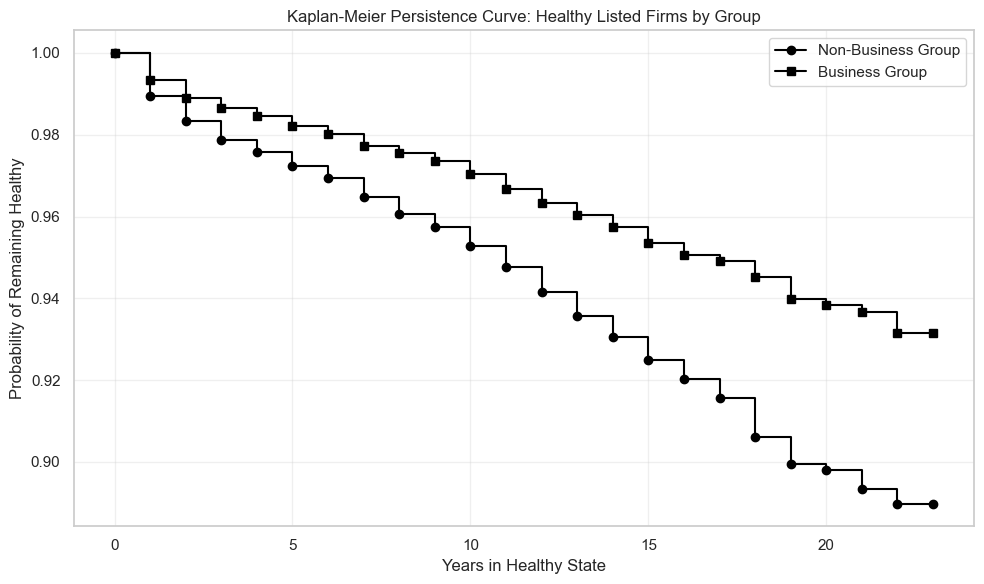

In [126]:
# Define marker styles and group labels
marker_styles = {0: 'o', 1: 's'}
group_labels = {0: "Non-Business Group", 1: "Business Group"}
color = 'black'  # All in black

# Filter for listed firms only
listed_df = df_healthy[df_healthy['listed firm'] == 1]

fig, ax = plt.subplots(figsize=(10, 6))
legend_handles = []

for group_val in [0, 1]:
    group_df = listed_df[listed_df['Group Dummy'] == group_val]
    if group_df.empty:
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(durations=group_df['Healthy_Duration'], event_observed=group_df['Event'])

    survival = kmf.survival_function_
    durations = survival.index.values
    probs = survival.iloc[:, 0].values
    marker = marker_styles[group_val]

    # Plot step curve
    ax.step(durations, probs, where='post', color=color)
    # Add markers along the curve
    ax.plot(durations, probs, linestyle='', marker=marker, color=color)

    # Custom legend entry
    handle = mlines.Line2D([], [], color=color, marker=marker, linestyle='-', label=group_labels[group_val])
    legend_handles.append(handle)

    # Median vertical line
    median = kmf.median_survival_time_
    if median is not None and median != float('inf'):
        ax.axvline(x=median, color='gray', linestyle='--', label=f"{group_labels[group_val]} Median = {median:.1f} yrs")

# Final plot formatting
ax.set_title("Kaplan-Meier Persistence Curve: Healthy Listed Firms by Group")
ax.set_xlabel("Years in Healthy State")
ax.set_ylabel("Probability of Remaining Healthy")
ax.grid(True, alpha=0.3)
ax.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.savefig('Images/healthy_listed_firm_persistence_by_group.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [127]:
# Filter for listed firms only
listed_df = df_healthy[df_healthy['listed firm'] == 1]

# Split data by group
group0 = listed_df[listed_df['Group Dummy'] == 0]
group1 = listed_df[listed_df['Group Dummy'] == 1]

# Run log-rank test
results = logrank_test(
    group0['Healthy_Duration'],
    group1['Healthy_Duration'],
    event_observed_A=group0['Event'],
    event_observed_B=group1['Event']
)

results

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         105.52 <0.005     79.81

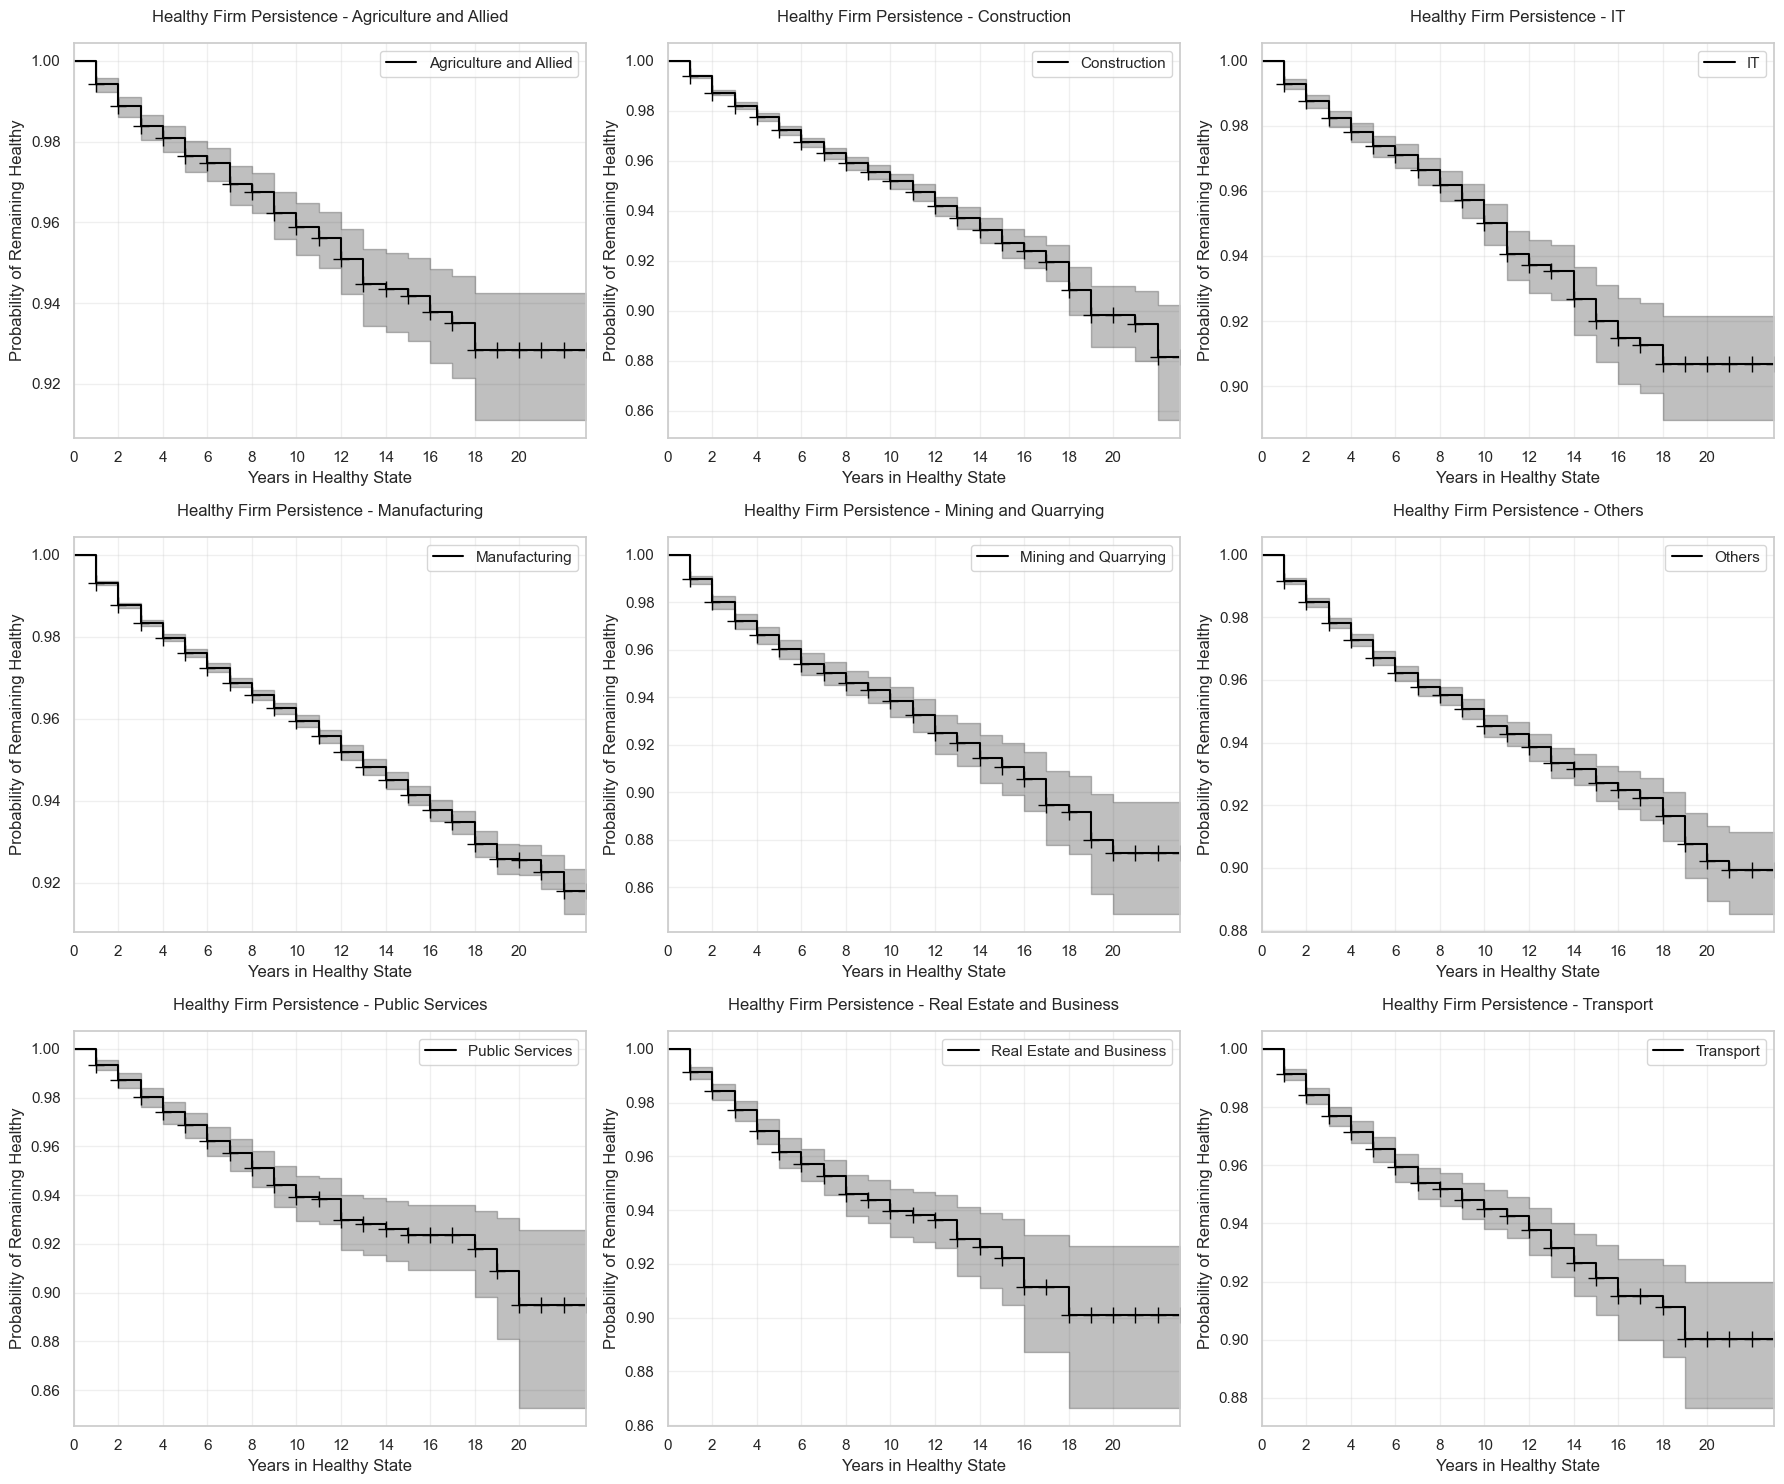

In [128]:
# Data prep
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

df['Healthy'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Healthy' else 0)
df['Prev_Healthy'] = df.groupby('Company Name')['Healthy'].shift(1, fill_value=0)
df['New_Healthy_Spell'] = (df['Healthy'] == 1) & (df['Prev_Healthy'] == 0)
df['Healthy_Spell_ID'] = df.groupby('Company Name')['New_Healthy_Spell'].cumsum()
df['Healthy_Duration'] = df.groupby(['Company Name', 'Healthy_Spell_ID']).cumcount() + 1
df['Next_Healthy'] = df.groupby('Company Name')['Healthy'].shift(-1)

df = df[df['Healthy'] == 1].copy()
df['Event'] = (df['Next_Healthy'] == 0).astype(int)
df['Event'] = df['Event'].fillna(0).astype(int)

# Unique industries
industry_list = df['Industry_Group'].dropna().unique()
industry_list.sort()

# Subplot grid setup
n = len(industry_list)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharey=False)
axes = axes.flatten()

# Loop through each industry
for i, industry in enumerate(industry_list):
    ax = axes[i]
    industry_df = df[df['Industry_Group'] == industry].copy()

    if industry_df.empty:
        ax.set_title(f"No data for {industry}")
        ax.axis('off')
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(durations=industry_df['Healthy_Duration'],
            event_observed=industry_df['Event'],
            label=industry)

    kmf.plot(ax=ax, ci_show=True, show_censors=True,color='black')

    # Set x-axis to range from 0 to max duration in industry
    max_dur = int(industry_df['Healthy_Duration'].max())
    min_dur = int(industry_df['Healthy_Duration'].min())
    ax.set_xlim(min_dur, max_dur)
    ax.set_xticks(np.arange(0, 21, 2))

    ax.set_title(f"Healthy Firm Persistence - {industry}", pad=15)
    ax.set_xlabel("Years in Healthy State")
    ax.set_ylabel("Probability of Remaining Healthy")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

# Turn off unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Save and show
plt.tight_layout()
plt.savefig('Images/KPM_Healthy_Persistence_By_Industry.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [129]:
# Filter out industries with insufficient data if needed
valid_df = df[df['Industry_Group'].isin(industry_list)].copy()

# Ensure both groups exist
group_counts = valid_df['Group Dummy'].value_counts()
if group_counts.min() < 1:
    print("Insufficient data: One of the groups is missing.")
else:
    # Run multivariate log-rank test across all industries
    result = multivariate_logrank_test(
        valid_df['Healthy_Duration'],
        valid_df['Group Dummy'],
        valid_df['Event']
    )

# Display result
result

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          20.61 <0.005     17.44

## Probability of firms becoming zombie again (Relapse)

In [130]:
df = Analysis_data.copy().sort_values(['Company Name', 'Year'])
spell_records = []

for firm_id, group in df.groupby('Company Name'):
    group = group.reset_index(drop=True)
    recovery_start = None

    # Assuming Group Dummy is constant per company; take the first available value
    group_dummy_value = group.loc[0, 'Group Dummy'] if 'Group Dummy' in group.columns else None
    listed_firm = group.loc[0, 'listed firm']
    industry_group_value = group.loc[0, 'Industry_Group'] if 'Industry_Group' in group.columns else None


    for i in range(1, len(group)):
        prev_status = group.loc[i-1, 'Zombie']
        curr_status = group.loc[i, 'Zombie']
        curr_year = group.loc[i, 'Year']

        # Detect recovery (Zombie=0 after Zombie=1)
        if prev_status == 1 and curr_status == 0:
            recovery_start = curr_year

        # Detect relapse (Zombie=1 after recovery)
        elif recovery_start is not None and curr_status == 1:
            duration = curr_year - recovery_start
            spell_records.append({
                'Company Name': firm_id,
                'recovery_year': recovery_start,
                'relapse_year': curr_year,
                'duration_to_relapse': duration,
                'Event': 1,  # Relapse occurred
                'Group Dummy': group_dummy_value,
                'listed firm': listed_firm,
                'Industry_Group': industry_group_value
            })
            recovery_start = None  # Reset for next recovery spell

    # Handle censored cases (recovered but no relapse by end of data)
    if recovery_start is not None:
        last_year = group.loc[len(group)-1, 'Year']
        duration = last_year - recovery_start
        spell_records.append({
            'Company Name': firm_id,
            'recovery_year': recovery_start,
            'relapse_year': None,
            'duration_to_relapse': duration,
            'Event': 0,  # Censored (no relapse observed)
            'Group Dummy': group_dummy_value,
            'listed firm': listed_firm,
            'Industry_Group': industry_group_value
        })

spells_df = pd.DataFrame(spell_records)

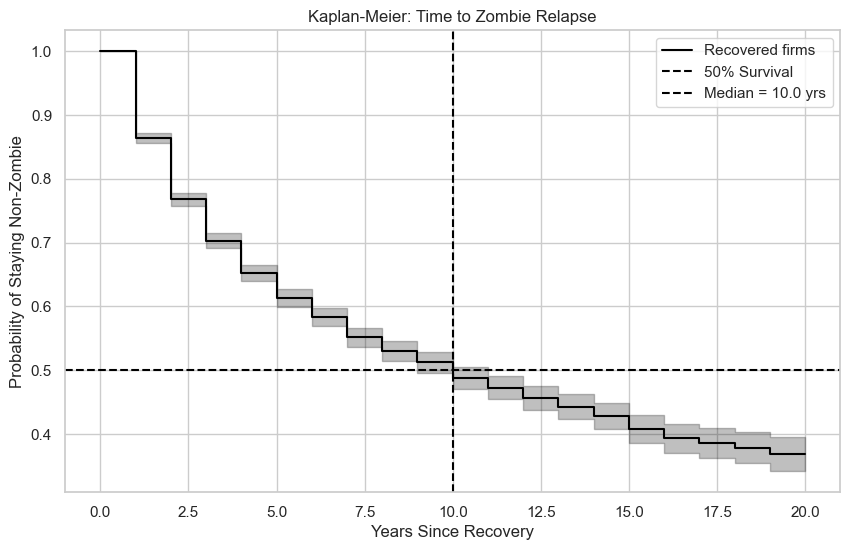

In [131]:
kmf = KaplanMeierFitter()
T = spells_df['duration_to_relapse']
E = spells_df['Event']
kmf.fit(durations=T, event_observed=E, label="Recovered firms")

# Calculate the median survival time
median_survival_time = kmf.median_survival_time_

# Plot the survival curve
plt.figure(figsize=(10,6))
ax = kmf.plot(color='black')
plt.title("Kaplan-Meier: Time to Zombie Relapse")
plt.xlabel("Years Since Recovery")
plt.ylabel("Probability of Staying Non-Zombie")
plt.grid(True)

# Add horizontal and vertical lines at the median
plt.axhline(y=0.5, color='black', linestyle='--', label='50% Survival')
plt.axvline(x=median_survival_time, color='black', linestyle='--', label=f'Median = {median_survival_time:.1f} yrs')

plt.legend()
plt.savefig('Images/KPM Zombie Relapse.tiff', dpi=1000, bbox_inches='tight')
plt.show()

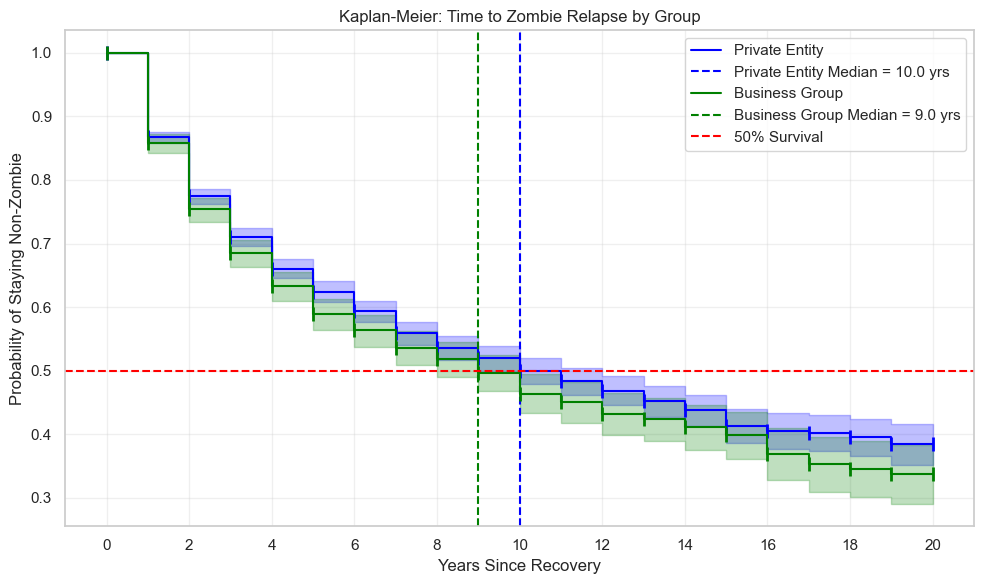

In [132]:
fig, ax = plt.subplots(figsize=(10, 6))
group_labels = {0: "Private Entity", 1: "Business Group"}
colors = {0: 'blue', 1: 'green'}

for group_val in [0, 1]:
    group_df = spells_df[spells_df['Group Dummy'] == group_val]

    if group_df.empty:
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(durations=group_df['duration_to_relapse'], 
            event_observed=group_df['Event'], 
            label=group_labels[group_val])

    kmf.plot(ax=ax, ci_show=True, show_censors=True, color=colors[group_val],
             censor_styles={'marker': '|', 'ms': 10, 'mew': 2})

    median_survival_time = kmf.median_survival_time_
    ax.axvline(x=median_survival_time, color=colors[group_val], linestyle='--',
               label=f'{group_labels[group_val]} Median = {median_survival_time:.1f} yrs')

ax.axhline(y=0.5, color='red', linestyle='--', label='50% Survival')

ax.set_title("Kaplan-Meier: Time to Zombie Relapse by Group")
ax.set_xlabel("Years Since Recovery")
max_duration = int(spells_df['duration_to_relapse'].max())
ax.set_xticks(range(0, max_duration + 1, 2))
ax.set_ylabel("Probability of Staying Non-Zombie")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Relapse_By_Group_SINGLE.tiff', dpi=1000, bbox_inches='tight')
plt.show()

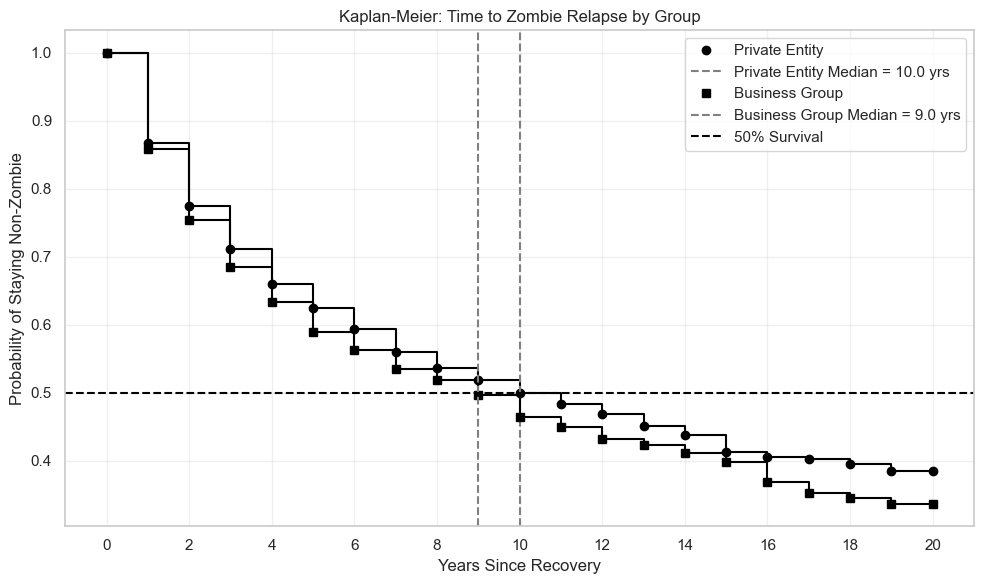

In [133]:
# Setup
fig, ax = plt.subplots(figsize=(10, 6))
group_labels = {0: "Private Entity", 1: "Business Group"}
marker_styles = {0: 'o', 1: 's'}  # Different markers for each group
linestyle = '-'

# Loop through groups
for group_val in [0, 1]:
    group_df = spells_df[spells_df['Group Dummy'] == group_val]

    if group_df.empty:
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(durations=group_df['duration_to_relapse'], 
            event_observed=group_df['Event'])

    survival = kmf.survival_function_
    durations = survival.index
    values = survival[kmf.survival_function_.columns[0]]

    # Plot black line with step
    ax.step(durations, values, where='post', color='black', linestyle=linestyle)

    # Add marker on the line
    ax.plot(durations, values, linestyle='', marker=marker_styles[group_val],
            color='black', label=group_labels[group_val])  # Label here for legend

    # Median vertical line
    median_survival_time = kmf.median_survival_time_
    if median_survival_time and median_survival_time != float('inf'):
        ax.axvline(x=median_survival_time, color='gray', linestyle='--',
                   label=f"{group_labels[group_val]} Median = {median_survival_time:.1f} yrs")

# Reference line
ax.axhline(y=0.5, color='black', linestyle='--', label='50% Survival')

# Formatting
ax.set_title("Kaplan-Meier: Time to Zombie Relapse by Group")
ax.set_xlabel("Years Since Recovery")
max_duration = int(spells_df['duration_to_relapse'].max())
ax.set_xticks(range(0, max_duration + 1, 2))
ax.set_ylabel("Probability of Staying Non-Zombie")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Relapse_By_Group_SINGLE.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [134]:
# Split data by group
group0 = spells_df[spells_df['Group Dummy'] == 0]
group1 = spells_df[spells_df['Group Dummy'] == 1]

# Run log-rank test
results = logrank_test(
    group0['duration_to_relapse'], 
    group1['duration_to_relapse'], 
    event_observed_A=group0['Event'], 
    event_observed_B=group1['Event']
)

results

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           4.86 0.03      5.18

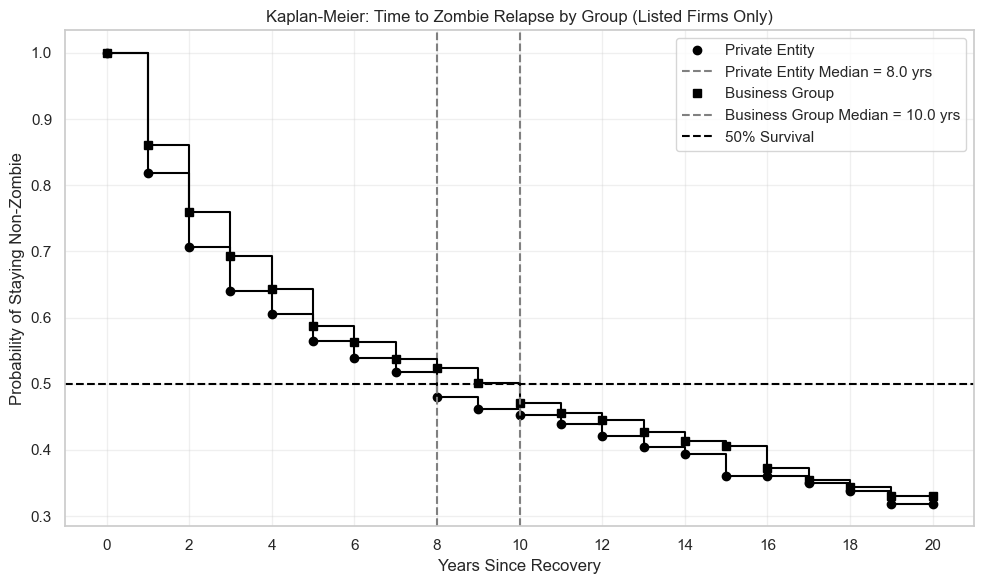

In [135]:
fig, ax = plt.subplots(figsize=(10, 6))
group_labels = {0: "Private Entity", 1: "Business Group"}
marker_styles = {0: 'o', 1: 's'}

# Filter only listed firms
listed_spells_df = spells_df[spells_df['listed firm'] == 1]

for group_val in [0, 1]:
    group_df = listed_spells_df[listed_spells_df['Group Dummy'] == group_val]
    if group_df.empty:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(durations=group_df['duration_to_relapse'], event_observed=group_df['Event'])
    survival = kmf.survival_function_
    durations = survival.index
    values = survival[kmf.survival_function_.columns[0]]
    ax.step(durations, values, where='post', color='black', linestyle='-')
    ax.plot(durations, values, linestyle='', marker=marker_styles[group_val], color='black', label=group_labels[group_val])
    median_survival_time = kmf.median_survival_time_
    if median_survival_time and median_survival_time != float('inf'):
        ax.axvline(x=median_survival_time, color='gray', linestyle='--', label=f"{group_labels[group_val]} Median = {median_survival_time:.1f} yrs")

ax.axhline(y=0.5, color='black', linestyle='--', label='50% Survival')
ax.set_title("Kaplan-Meier: Time to Zombie Relapse by Group (Listed Firms Only)")
ax.set_xlabel("Years Since Recovery")
ax.set_xticks(range(0, int(spells_df['duration_to_relapse'].max()) + 1, 2))
ax.set_ylabel("Probability of Staying Non-Zombie")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Relapse_By_Group_LISTED_ONLY.tiff', dpi=1000, bbox_inches='tight')
plt.show()


In [136]:
# Filter for listed firms only
listed_df = spells_df[spells_df['listed firm'] == 1]

# Split data by group within listed firms
group0 = listed_df[listed_df['Group Dummy'] == 0]
group1 = listed_df[listed_df['Group Dummy'] == 1]

# Run log-rank test
results = logrank_test(
    group0['duration_to_relapse'],
    group1['duration_to_relapse'],
    event_observed_A=group0['Event'],
    event_observed_B=group1['Event']
)

results

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           1.66 0.20      2.34

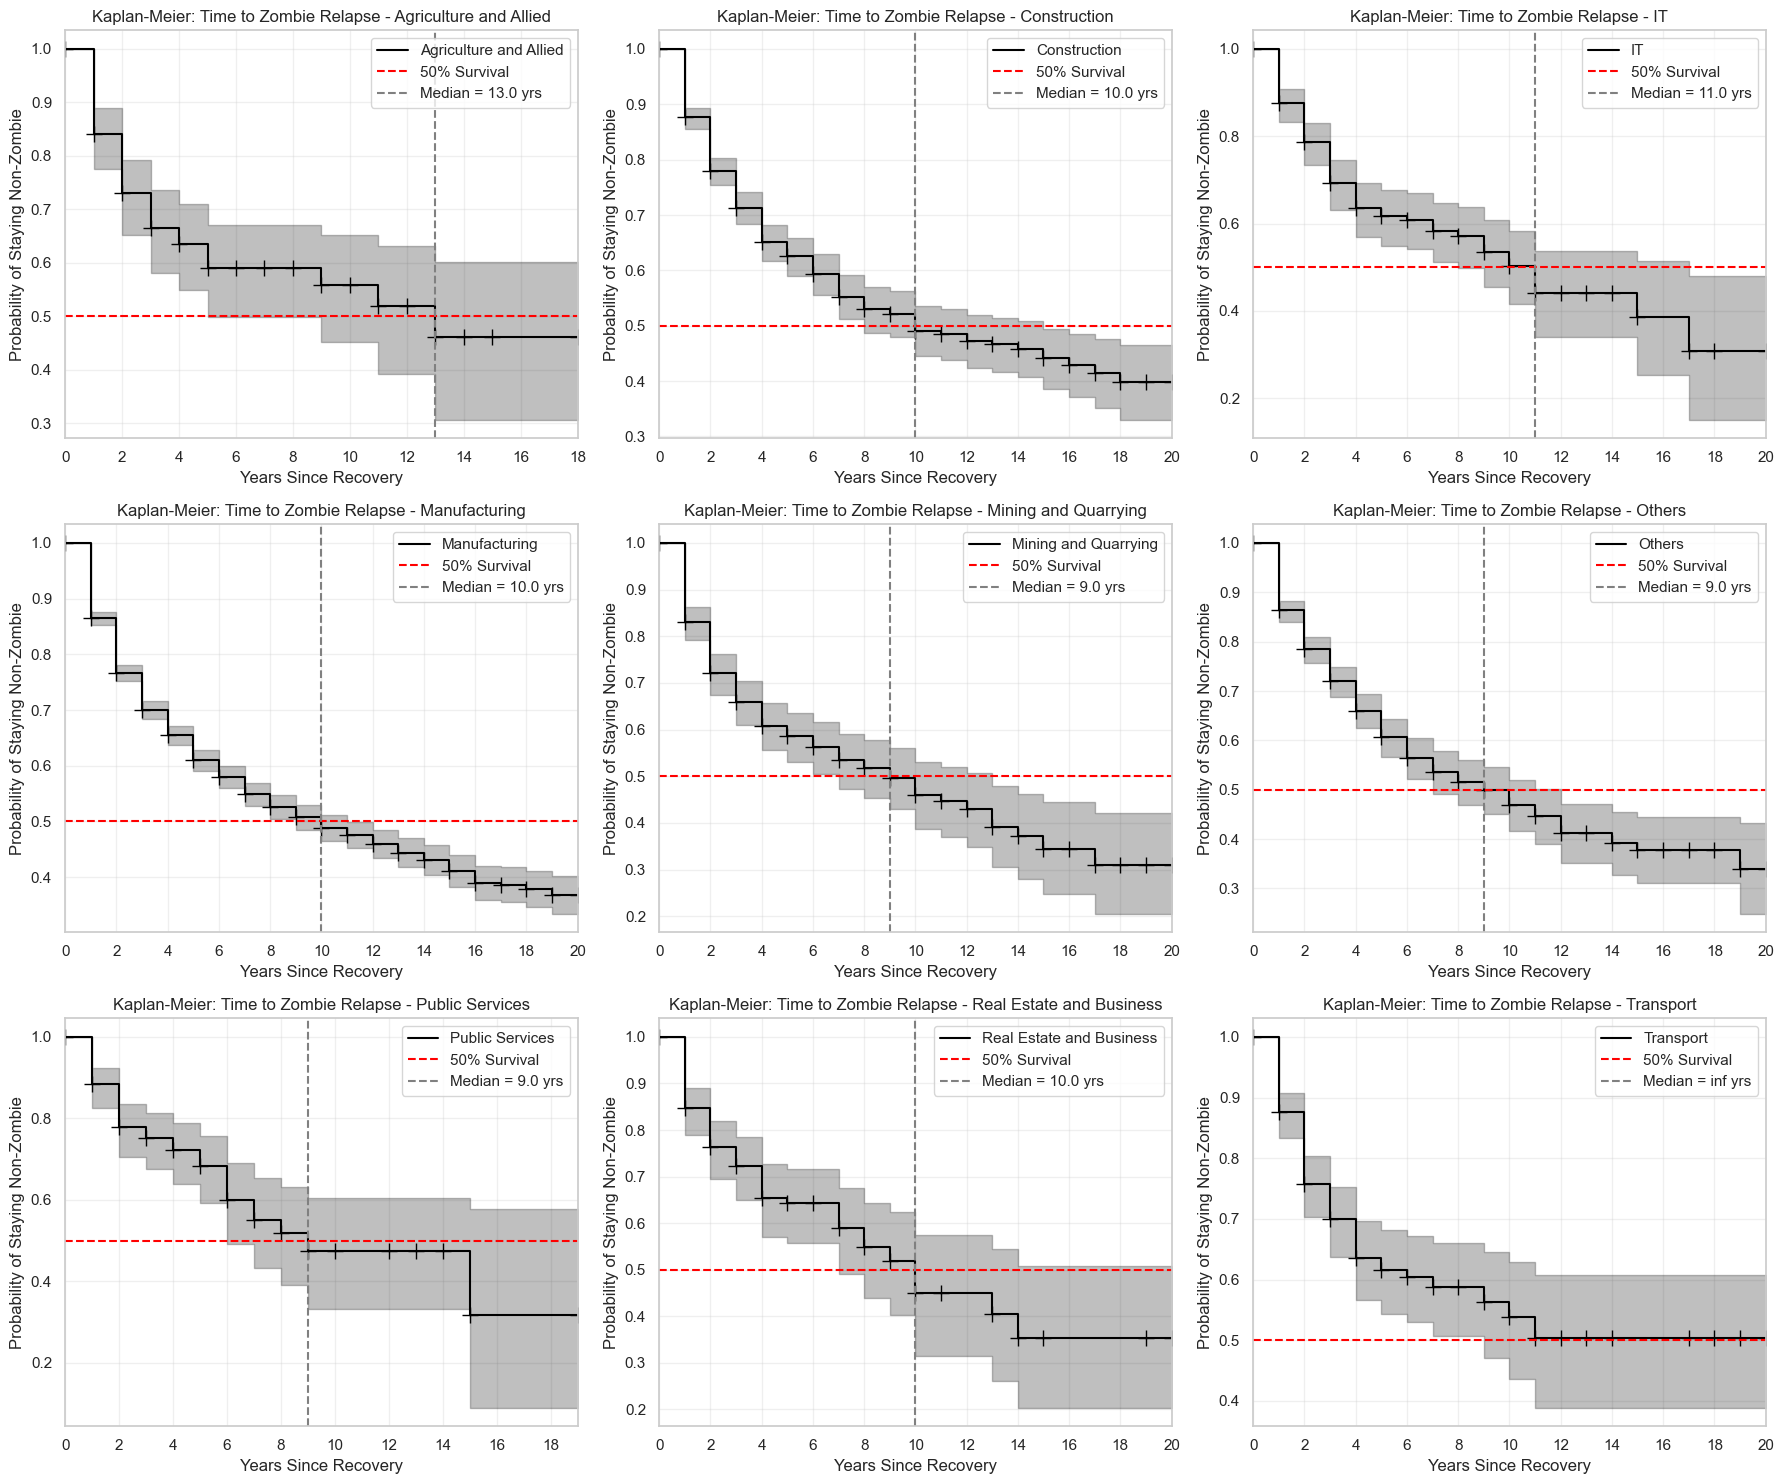

In [137]:
# Get unique industries
industry_list = spells_df['Industry_Group'].dropna().unique()
industry_list.sort()

# Setup subplot grid (3 columns for example)
n = len(industry_list)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharey=False)
axes = axes.flatten()

for i, industry in enumerate(industry_list):
    ax = axes[i]
    industry_df = spells_df[spells_df['Industry_Group'] == industry]

    if industry_df.empty:
        ax.set_title(f"No data for {industry}")
        ax.axis('off')
        continue

    kmf = KaplanMeierFitter()
    kmf.fit(durations=industry_df['duration_to_relapse'], 
            event_observed=industry_df['Event'], 
            label=industry)

    kmf.plot(ax=ax, ci_show=True, show_censors=True,color='black')

    median_survival_time = kmf.median_survival_time_
    ax.axhline(y=0.5, color='red', linestyle='--', label='50% Survival')
    if median_survival_time is not None:
        ax.axvline(x=median_survival_time, color='gray', linestyle='--', label=f'Median = {median_survival_time:.1f} yrs')

    max_duration = int(industry_df['duration_to_relapse'].max())
    ax.set_xlim(0, max_duration)
    ax.set_xticks(np.arange(0, max_duration + 1, 2))

    ax.set_title(f"Kaplan-Meier: Time to Zombie Relapse - {industry}")
    ax.set_xlabel("Years Since Recovery")
    ax.set_ylabel("Probability of Staying Non-Zombie")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('Images/KPM_Zombie_Relapse_By_Industry.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [138]:
# Prepare data: drop NA industries and filter by min size
min_firms = 10
df_valid = spells_df.dropna(subset=['Industry_Group']).copy()
industry_counts = df_valid['Industry_Group'].value_counts()
valid_industries = industry_counts[industry_counts >= min_firms].index.tolist()

# Keep only valid industries
df_valid = df_valid[df_valid['Industry_Group'].isin(valid_industries)].copy()

# Perform multivariate log-rank test across all industries
result = multivariate_logrank_test(
    df_valid['duration_to_relapse'],
    df_valid['Industry_Group'],
    df_valid['Event']
)

# Display results
result

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 8
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           4.86 0.77      0.37

## Comparing Recovered vs healthy firm

In [139]:
Analysis_data['Zombie'] = (Analysis_data['Semi_Restricted'] == "Zombie").astype(int)

In [140]:
# Step 1: Copy and sort the original data
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Step 2: Identify zombie status
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['Event'] = ((df['Zombie'] == 0) & (df['Prev_Zombie'] == 1)).astype(int)

# Step 3: Identify firm types
# Default to Non-Zombie
df['Firm_Type'] = 'Non-Zombie'

# Identify firms that were ever zombies
ever_zombie = df.groupby('Company Name')['Zombie'].transform('sum') > 0

# Identify firms that recovered at some point (Event == 1 at least once)
recovered = df.groupby('Company Name')['Event'].transform('sum') > 0

# Set Recovered Zombie status
df.loc[ever_zombie & recovered, 'Firm_Type'] = 'Recovered Zombie'

# Step 4: Split the data
non_zombie = df[df['Firm_Type'] == 'Non-Zombie']
recovered_zombie = df[df['Firm_Type'] == 'Recovered Zombie']

# Step 5: Define variables
variables = ['Number of Banks', 'Promoter pledging', 'Interest Gap', 'Asset Disposal', 'capex', 'Primary_Equity',
             'Debt Growth', 'ICR', 'Debt to Assets', 'cashflow', 'EDR', 'debt to equity','Total Assets',
             'Subsidized Credit', 'ROE', 'ROA', 'Altman Z Score', 'Tobins_q', 'Primary_Borrowing_from_banks'] + share_columns

# Step 6: Kolmogorov-Smirnov Tests
ks_results = []

for var in variables:
    non_zombie_var = non_zombie[var].dropna()
    recovered_zombie_var = recovered_zombie[var].dropna()

    if not non_zombie_var.empty and not recovered_zombie_var.empty:
        ks_stat, ks_p_value = ks_2samp(non_zombie_var, recovered_zombie_var)
    else:
        ks_stat, ks_p_value = float('nan'), float('nan')

    ks_results.append({
        'Variable': var,
        'KS Statistic': ks_stat,
        'P-value': ks_p_value
    })

ks_results_df = pd.DataFrame(ks_results).round(2).sort_values(by='KS Statistic', ascending=False)

# Step 7: Descriptive Statistics
desc_non_zombies = non_zombie[variables].describe().T.round(3)
desc_recovered_zombies = recovered_zombie[variables].describe().T.round(3)

mean_non_zombie = desc_non_zombies['mean'].rename('Non-Zombie')
mean_recovered = desc_recovered_zombies['mean'].rename('Recovered Zombie')

mean_stats = pd.concat([mean_non_zombie, mean_recovered], axis=1)

# Step 8: Combine results
Kolmogrov_stats = mean_stats.merge(ks_results_df, left_index=True, right_on='Variable', how='left')
Kolmogrov_stats = Kolmogrov_stats.round(2).sort_values(by='Non-Zombie', ascending=False)

# Final output
Kolmogrov_stats[['Variable', 'Non-Zombie', 'Recovered Zombie', 'KS Statistic', 'P-value']]

,Variable,Non-Zombie,Recovered Zombie,KS Statistic,P-value
12,Total Assets,6106.77,5688.21,0.04,0.0
6,Debt Growth,39.42,28.24,0.09,0.0
7,ICR,18.63,3.58,0.35,0.0
19,Borrowing from banks_lag1_share,16.50,23.00,0.12,0.0
14,ROE,8.35,-12.76,0.25,0.0
15,ROA,8.09,2.61,0.24,0.0
27,Equity_lag1_share,5.50,4.36,0.03,0.0
4,capex,5.38,5.13,0.08,0.0
25,Inter-corporate loans_lag1_share,3.00,8.13,0.13,0.0
10,EDR,2.29,0.46,0.35,0.0


## Analysis of different variables and Recovery

In [141]:
Analysis_data = Analysis_data[['Company Name','Year','Semi_Restricted','Weak','Strong','Borrowing from banks_lag1_share',
            'Borrowing from financial institutions_lag1_share','Borrowings from RBI_lag1_share',
            'Borrowings from central & state govt_lag1_share','Borrowings syndicated across banks & institutions_lag1_share',
            'Deferred credit_lag1_share', 'Inter-corporate loans_lag1_share','Equity_lag1_share',
            'Loans from promoters, directors and shareholders_lag1_share','Number of Banks','Promoter pledging',
            'Total Assets','Debt','EDR','Age','current ratio','three digit NIC code','ICR','Debt to Assets','Debt Growth',
            'Equity','capex','cashflow','Asset Disposal','Primary_Source','Primary_Source_Category','Industry_Group',
             'debt to equity','ROE','ROA','Subsidized Credit','Altman Z Score','listed firm','Tobins_q','Group Dummy']]

In [142]:
Analysis_data['Zombie'] = (Analysis_data['Semi_Restricted'] == "Zombie").astype(int)

## Zombie Recovery by funding Sources

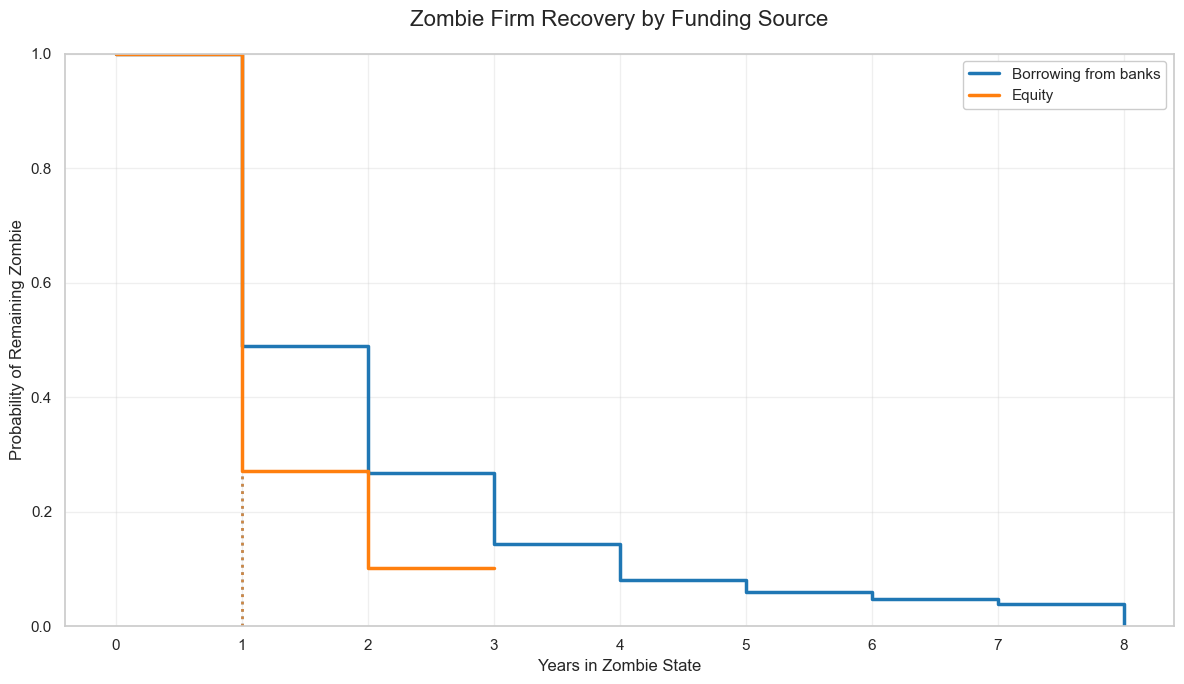

,Funding Source,Median Recovery (years),1-Year Recovery,3-Year Recovery,5-Year Recovery
0,Borrowing from banks,1.0,51%,86%,94%
1,Equity,1.0,73%,90%,90%


In [143]:
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount()
df['Event'] = ((df['Zombie'] == 0) & (df['Prev_Zombie'] == 1)).astype(int)
df_zombie_exit = df[df['Prev_Zombie'] == 1].copy()

# Step 4: Define sources of interest
focus_sources = ['Borrowing from banks', 'Equity']
colors = ['#1f77b4', '#ff7f0e']  # Blue and Orange for illustration

# Step 5: Plotting survival curves
plt.figure(figsize=(12, 7))
kmf = KaplanMeierFitter()
stats_summary = []

# Loop through each primary source category to plot
for i, source in enumerate(focus_sources):
    subset = df_zombie_exit[df_zombie_exit['Primary_Source_Category'] == source].dropna(subset=['Duration', 'Event'])

    if not subset.empty:
        # Fit the Kaplan-Meier model for the specific source
        kmf.fit(subset['Duration'], event_observed=subset['Event'], label=source)
        kmf.plot_survival_function(ax=plt.gca(), ci_show=False, color=colors[i], linewidth=2.5)

        # Plot the median survival time as a vertical line
        median = kmf.median_survival_time_
        if not np.isnan(median):
            plt.axvline(x=median, color=colors[i], linestyle=':', alpha=0.7, linewidth=2)

        # Save stats for the table
        stats_summary.append({
            'Funding Source': source,
            'Median Recovery (years)': median,
            '1-Year Survival': kmf.predict(1),
            '3-Year Survival': kmf.predict(3),
            '5-Year Survival': kmf.predict(5)
        })

# Step 6: Customize the plot
plt.title('Zombie Firm Recovery by Funding Source', fontsize=16, pad=20)
plt.xlabel('Years in Zombie State', fontsize=12)
plt.ylabel('Probability of Remaining Zombie', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', framealpha=1)
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('Images/zombie_recovery_comparison.tiff', dpi=300, bbox_inches='tight')
plt.show()

# Step 7: Format and display summary table
stats_df = pd.DataFrame(stats_summary)
stats_df['1-Year Recovery'] = 1 - stats_df['1-Year Survival']
stats_df['3-Year Recovery'] = 1 - stats_df['3-Year Survival']
stats_df['5-Year Recovery'] = 1 - stats_df['5-Year Survival']

formatted_table = stats_df[[ 
    'Funding Source', 'Median Recovery (years)', 
    '1-Year Recovery', '3-Year Recovery', '5-Year Recovery' 
]].style.format({ 
    'Median Recovery (years)': '{:.1f}', 
    '1-Year Recovery': '{:.0%}', 
    '3-Year Recovery': '{:.0%}', 
    '5-Year Recovery': '{:.0%}' 
}).set_properties(**{'text-align': 'center'})

display(formatted_table)

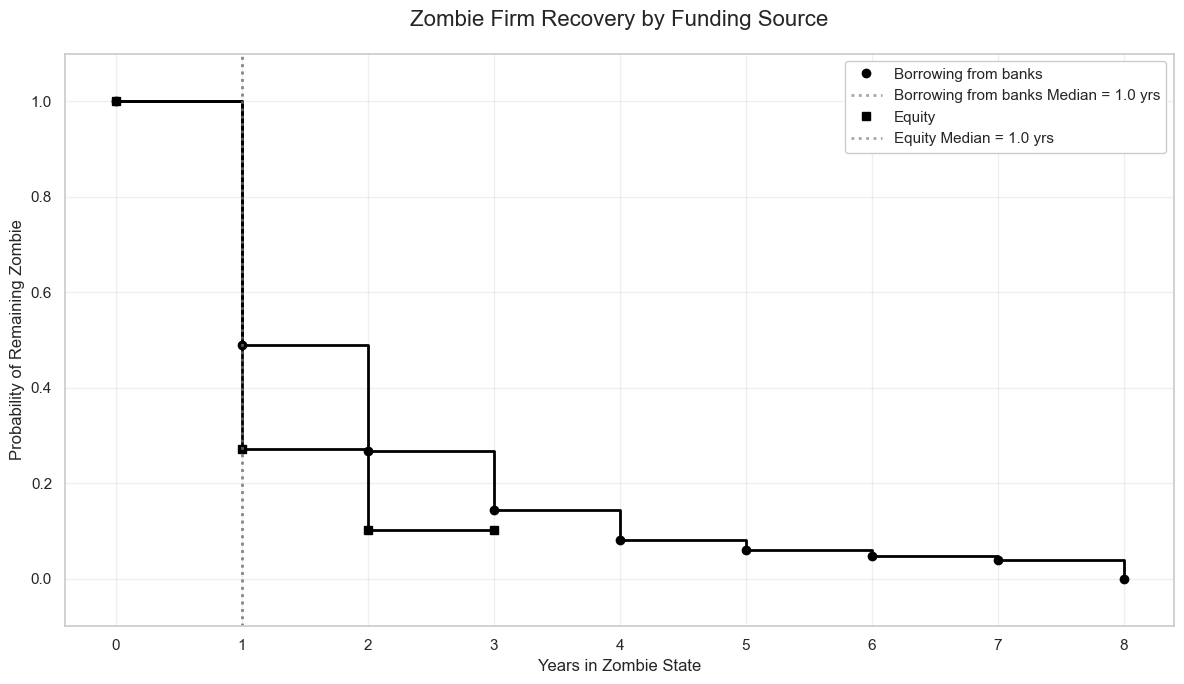

,Funding Source,Median Recovery (years),1-Year Recovery,3-Year Recovery,5-Year Recovery
0,Borrowing from banks,1.0,51%,86%,94%
1,Equity,1.0,73%,90%,90%


In [144]:
# Setup
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount()
df['Event'] = ((df['Zombie'] == 0) & (df['Prev_Zombie'] == 1)).astype(int)
df_zombie_exit = df[df['Prev_Zombie'] == 1].copy()

# Plot Setup
focus_sources = ['Borrowing from banks', 'Equity']
markers = {'Borrowing from banks': 'o', 'Equity': 's'}
stats_summary = []

plt.figure(figsize=(12, 7))
ax = plt.gca()

# Loop through each funding source
for source in focus_sources:
    subset = df_zombie_exit[df_zombie_exit['Primary_Source_Category'] == source].dropna(subset=['Duration', 'Event'])
    if not subset.empty:
        kmf = KaplanMeierFitter()
        kmf.fit(subset['Duration'], event_observed=subset['Event'])

        # Extract data
        durations = kmf.survival_function_.index
        survival_probs = kmf.survival_function_[kmf.survival_function_.columns[0]]

        # Step plot in black
        ax.step(durations, survival_probs, where='post', color='black', linewidth=2)

        # Overlay markers
        ax.plot(durations, survival_probs, linestyle='', marker=markers[source], color='black', label=source)

        # Median line
        median = kmf.median_survival_time_
        if not np.isnan(median):
            ax.axvline(x=median, color='gray', linestyle=':', linewidth=2, alpha=0.7,
                       label=f"{source} Median = {median:.1f} yrs")

        # Save stats
        stats_summary.append({
            'Funding Source': source,
            'Median Recovery (years)': median,
            '1-Year Survival': kmf.predict(1),
            '3-Year Survival': kmf.predict(3),
            '5-Year Survival': kmf.predict(5)
        })

# Plot decorations
ax.set_title('Zombie Firm Recovery by Funding Source', fontsize=16, pad=20)
ax.set_xlabel('Years in Zombie State', fontsize=12)
ax.set_ylabel('Probability of Remaining Zombie', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', framealpha=1)
ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('Images/zombie_recovery_comparison.tiff', dpi=300, bbox_inches='tight')
plt.show()

# Summary table formatting
stats_df = pd.DataFrame(stats_summary)
stats_df['1-Year Recovery'] = 1 - stats_df['1-Year Survival']
stats_df['3-Year Recovery'] = 1 - stats_df['3-Year Survival']
stats_df['5-Year Recovery'] = 1 - stats_df['5-Year Survival']

formatted_table = stats_df[[
    'Funding Source', 'Median Recovery (years)',
    '1-Year Recovery', '3-Year Recovery', '5-Year Recovery'
]].style.format({
    'Median Recovery (years)': '{:.1f}',
    '1-Year Recovery': '{:.0%}',
    '3-Year Recovery': '{:.0%}',
    '5-Year Recovery': '{:.0%}'
}).set_properties(**{'text-align': 'center'})

display(formatted_table)

In [145]:
group_a = df_zombie_exit[df_zombie_exit['Primary_Source_Category'] == 'Borrowing from banks']
group_b = df_zombie_exit[df_zombie_exit['Primary_Source_Category'] == 'Equity']

# Perform the log-rank test
results = logrank_test(group_a['Duration'], group_b['Duration'],
                       event_observed_A=group_a['Event'], event_observed_B=group_b['Event'])

# Create a DataFrame to store the results
logrank_results_df = pd.DataFrame({
    'Test Statistic': [results.test_statistic],
    'P-value': [results.p_value]
})

# Display the DataFrame
logrank_results_df.round(2)

,Test Statistic,P-value
0,12.87,0.0


## Continuation of Zombie Firms Across different primary Source

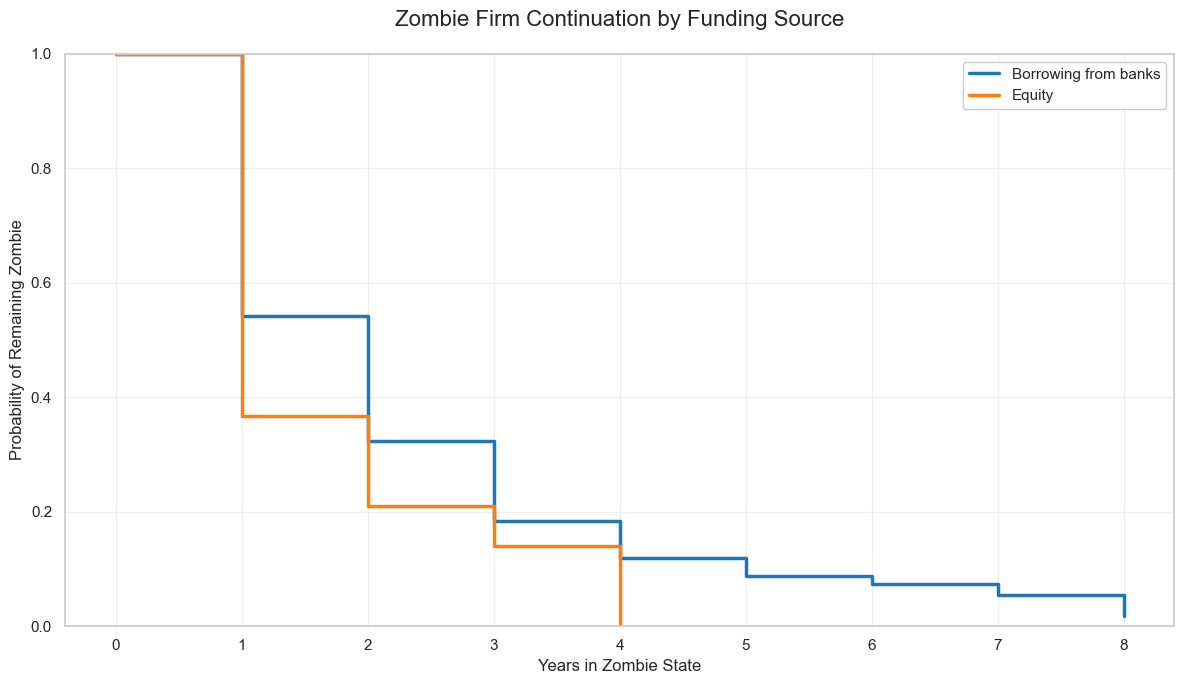

,Funding Source,Firm-Years,Median Zombie Duration,1-Year Continuation,3-Year Continuation,5-Year Continuation
0,Borrowing from banks,2105,2.0,54%,18%,9%
1,Equity,136,1.0,37%,14%,0%


In [146]:
# Step 1: Prepare the data
df = Analysis_data.copy()
df = df.sort_values(['Company Name', 'Year']).reset_index(drop=True)

# Step 2: Identify zombie status and calculate spells
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount() + 1
df['Next_Zombie'] = df.groupby('Company Name')['Zombie'].shift(-1)
df['Event'] = (df['Next_Zombie'] == 0).astype(int)  # 1 = exit (failure), 0 = continued zombie

# Step 3: Filter for zombie firm years only
zombie_df = df[df['Zombie'] == 1].copy()

# Step 4: Define sources of interest
focus_sources = ['Borrowing from banks', 'Equity']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# Step 5: Plotting survival curves (continuation = survival in zombie state)
plt.figure(figsize=(12, 7))
kmf = KaplanMeierFitter()
stats_summary = []

for i, source in enumerate(focus_sources):
    subset = zombie_df[zombie_df['Primary_Source_Category'] == source].dropna(subset=['Duration', 'Event'])

    if not subset.empty:
        kmf.fit(subset['Duration'], event_observed=subset['Event'])
        kmf.plot_survival_function(ax=plt.gca(), ci_show=False, color=colors[i], label=source, linewidth=2.5)

        median = kmf.median_survival_time_
        stats_summary.append({
            'Funding Source': source,
            'Firm-Years': len(subset),
            'Median Zombie Duration': median,
            '1-Year Continuation': kmf.predict(1),
            '3-Year Continuation': kmf.predict(3),
            '5-Year Continuation': kmf.predict(5)
        })

# Step 6: Customize the plot
plt.title('Zombie Firm Continuation by Funding Source', fontsize=16, pad=20)
plt.xlabel('Years in Zombie State', fontsize=12)
plt.ylabel('Probability of Remaining Zombie', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', framealpha=1)
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig('Images/zombie_continuation_comparison.tiff', dpi=300, bbox_inches='tight')
plt.show()

# Step 7: Format and display summary table
stats_df = pd.DataFrame(stats_summary)
stats_df['1-Year Exit'] = 1 - stats_df['1-Year Continuation']
stats_df['3-Year Exit'] = 1 - stats_df['3-Year Continuation']
stats_df['5-Year Exit'] = 1 - stats_df['5-Year Continuation']

formatted_table = stats_df[[ 
    'Funding Source', 'Firm-Years', 'Median Zombie Duration',
    '1-Year Continuation', '3-Year Continuation', '5-Year Continuation'
]].style.format({
    'Median Zombie Duration': '{:.1f}',
    '1-Year Continuation': '{:.0%}',
    '3-Year Continuation': '{:.0%}',
    '5-Year Continuation': '{:.0%}'
}).set_properties(**{'text-align': 'center'})

display(formatted_table)

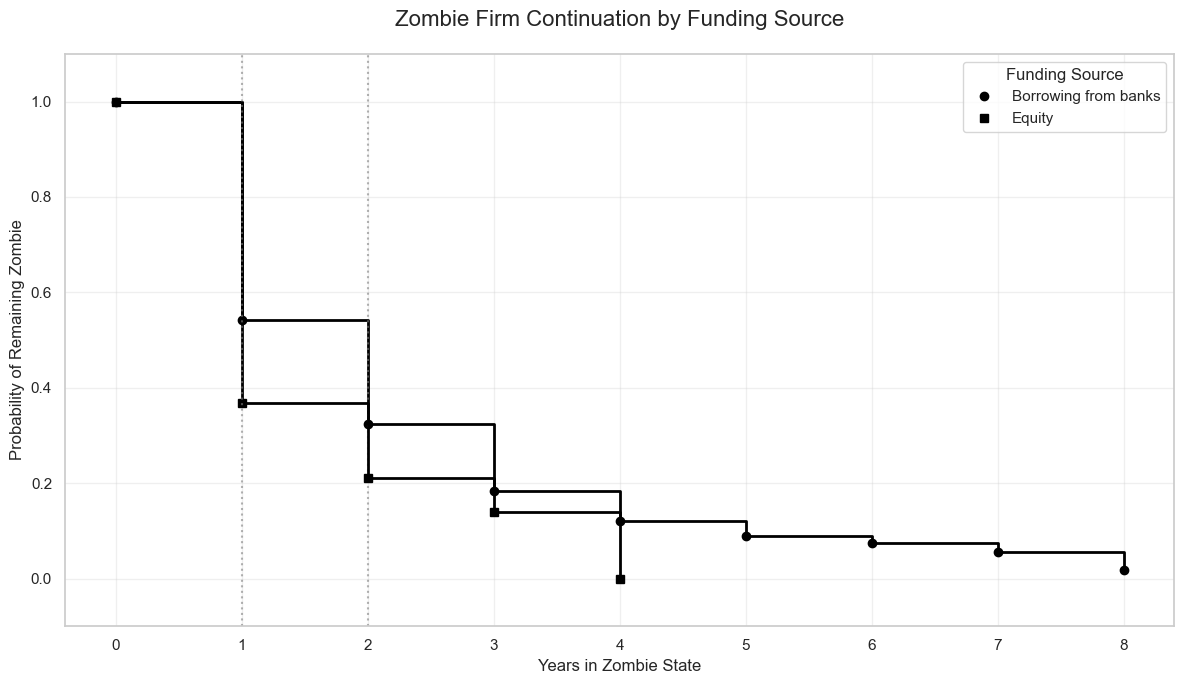

,Funding Source,Firm-Years,Median Zombie Duration,1-Year Continuation,3-Year Continuation,5-Year Continuation
0,Borrowing from banks,2105,2.0,54%,18%,9%
1,Equity,136,1.0,37%,14%,0%


In [147]:
# Step 1: Prepare the data
df = Analysis_data.copy()
df = df.sort_values(['Company Name', 'Year']).reset_index(drop=True)

# Step 2: Identify zombie status and calculate spells
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount() + 1
df['Next_Zombie'] = df.groupby('Company Name')['Zombie'].shift(-1)
df['Event'] = (df['Next_Zombie'] == 0).astype(int)

# Step 3: Filter for zombie firm years only
zombie_df = df[df['Zombie'] == 1].copy()

# Step 4: Define funding sources and markers
focus_sources = ['Borrowing from banks', 'Equity']
markers = {'Borrowing from banks': 'o', 'Equity': 's'}
stats_summary = []

# Step 5: Plotting
plt.figure(figsize=(12, 7))
ax = plt.gca()

for source in focus_sources:
    subset = zombie_df[zombie_df['Primary_Source_Category'] == source].dropna(subset=['Duration', 'Event'])
    
    if not subset.empty:
        kmf = KaplanMeierFitter()
        kmf.fit(subset['Duration'], event_observed=subset['Event'])

        # Black step plot
        durations = kmf.survival_function_.index
        surv_probs = kmf.survival_function_[kmf.survival_function_.columns[0]]

        ax.step(durations, surv_probs, where='post', color='black', linewidth=2)
        ax.plot(durations, surv_probs, linestyle='', marker=markers[source], color='black', label=source)

        # Median vertical line (optional)
        median = kmf.median_survival_time_
        if not np.isnan(median):
            ax.axvline(x=median, linestyle=':', color='gray', alpha=0.6)

        stats_summary.append({
            'Funding Source': source,
            'Firm-Years': len(subset),
            'Median Zombie Duration': median,
            '1-Year Continuation': kmf.predict(1),
            '3-Year Continuation': kmf.predict(3),
            '5-Year Continuation': kmf.predict(5)
        })

# Step 6: Customize plot
ax.set_title('Zombie Firm Continuation by Funding Source', fontsize=16, pad=20)
ax.set_xlabel('Years in Zombie State', fontsize=12)
ax.set_ylabel('Probability of Remaining Zombie', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(title='Funding Source', loc='upper right')
ax.set_ylim(-0.1, 1.1)
plt.tight_layout()
plt.savefig('Images/zombie_continuation_comparison.tiff', dpi=300, bbox_inches='tight')
plt.show()

# Step 7: Summary table
stats_df = pd.DataFrame(stats_summary)
stats_df['1-Year Exit'] = 1 - stats_df['1-Year Continuation']
stats_df['3-Year Exit'] = 1 - stats_df['3-Year Continuation']
stats_df['5-Year Exit'] = 1 - stats_df['5-Year Continuation']

formatted_table = stats_df[[ 
    'Funding Source', 'Firm-Years', 'Median Zombie Duration',
    '1-Year Continuation', '3-Year Continuation', '5-Year Continuation'
]].style.format({
    'Median Zombie Duration': '{:.1f}',
    '1-Year Continuation': '{:.0%}',
    '3-Year Continuation': '{:.0%}',
    '5-Year Continuation': '{:.0%}'
}).set_properties(**{'text-align': 'center'})

display(formatted_table)

In [148]:
# Split data into two groups
group_a = zombie_df[zombie_df['Primary_Source_Category'] == 'Borrowing from banks']
group_b = zombie_df[zombie_df['Primary_Source_Category'] == 'Equity']

results = logrank_test(
    group_a['Duration'], group_b['Duration'],
    event_observed_A=group_a['Event'],
    event_observed_B=group_b['Event']
)

# Create a DataFrame to store the results
logrank_results_df = pd.DataFrame({
    'Test Statistic': [results.test_statistic],
    'P-value': [results.p_value]
})

# Display the DataFrame
logrank_results_df.round(2)

,Test Statistic,P-value
0,14.57,0.0


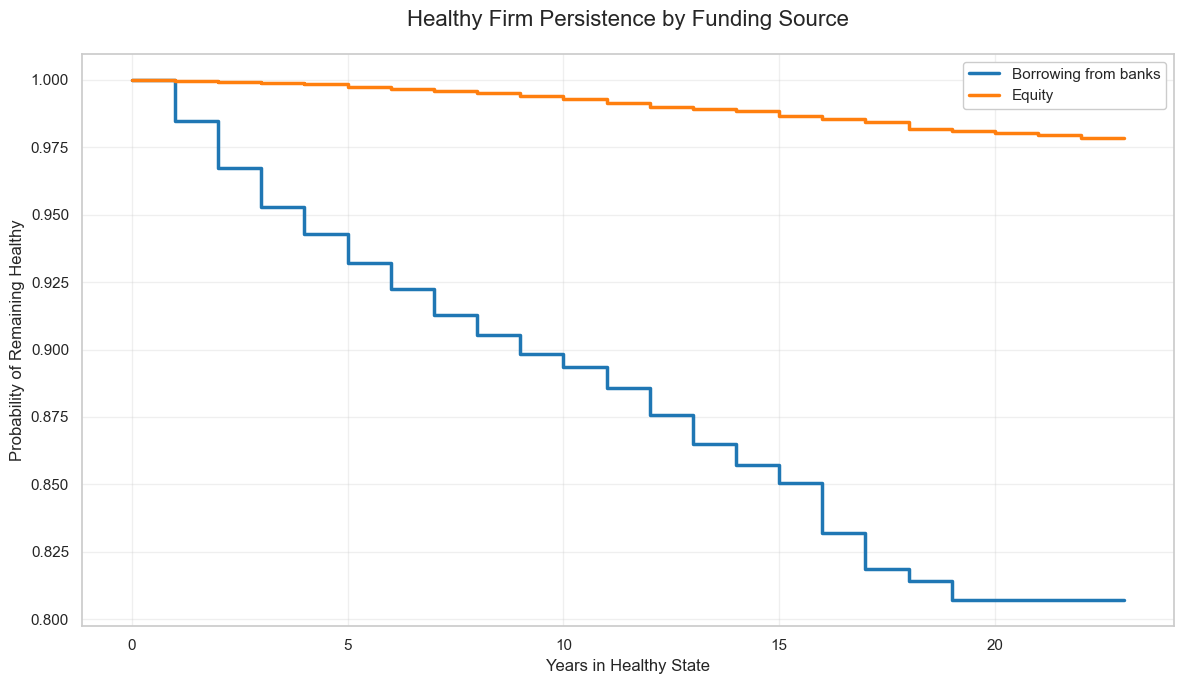

In [149]:
# Step 1: Prepare the data
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Binary indicator for healthy status
df['Healthy'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Healthy' else 0)

# Identify start of new healthy spells
df['Prev_Healthy'] = df.groupby('Company Name')['Healthy'].shift(1, fill_value=0)
df['New_Healthy_Spell'] = (df['Healthy'] == 1) & (df['Prev_Healthy'] == 0)

# Assign unique spell IDs per firm
df['Healthy_Spell_ID'] = df.groupby('Company Name')['New_Healthy_Spell'].cumsum()

# Duration within each spell (Year 1, 2, ...)
df['Healthy_Duration'] = df.groupby(['Company Name', 'Healthy_Spell_ID']).cumcount() + 1

# Next year's health status (for event detection)
df['Next_Healthy'] = df.groupby('Company Name')['Healthy'].shift(-1)

# Keep only healthy years for analysis
df_healthy = df[df['Healthy'] == 1].copy()

# Event = 1 if firm exits healthy state next year
df_healthy['Event'] = (df_healthy['Next_Healthy'] == 0).astype(int)

# Censoring: Event = 0 if next year is missing (end of data)
df_healthy['Event'] = df_healthy['Event'].fillna(0).astype(int)

# Final survival data
survival_data = df_healthy[['Company Name', 'Year', 'Healthy_Duration', 'Event', 'Primary_Source_Category']]

# Step 2: Define specific sources of interest (only Borrowing from banks and Equity)
focus_sources = ['Borrowing from banks', 'Equity']
colors = ['#1f77b4', '#ff7f0e']  # Blue, Orange (you can adjust the colors as needed)

# Step 3: Kaplan-Meier Analysis and Plotting
plt.figure(figsize=(12, 7))
kmf = KaplanMeierFitter()
stats_summary = []

for i, source in enumerate(focus_sources):
    subset = df_healthy[df_healthy['Primary_Source_Category'] == source].dropna(subset=['Healthy_Duration', 'Event'])

    if not subset.empty:
        kmf.fit(subset['Healthy_Duration'], event_observed=subset['Event'], label=source)
        kmf.plot_survival_function(ax=plt.gca(), ci_show=False, color=colors[i], linewidth=2.5)

        median = kmf.median_survival_time_
        stats_summary.append({
            'Funding Source': source,
            'Firm-Years': len(subset),
            'Median Healthy Duration': median,
            '1-Year Survival': kmf.predict(1),
            '3-Year Survival': kmf.predict(3),
            '5-Year Survival': kmf.predict(5)
        })

# Step 4: Customize the plot
plt.title('Healthy Firm Persistence by Funding Source', fontsize=16, pad=20)
plt.xlabel('Years in Healthy State', fontsize=12)
plt.ylabel('Probability of Remaining Healthy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', framealpha=1)

# Adjusting the y-axis based on the survival probabilities (set limits slightly below the min and above the max)
y_min, y_max = plt.gca().get_ylim()
plt.ylim(y_min, y_max )  # Adjust the range to fit the curve nicely

plt.tight_layout()

plt.savefig('Images/healthy_firm_persistence_comparison.tiff', dpi=300, bbox_inches='tight')
plt.show()

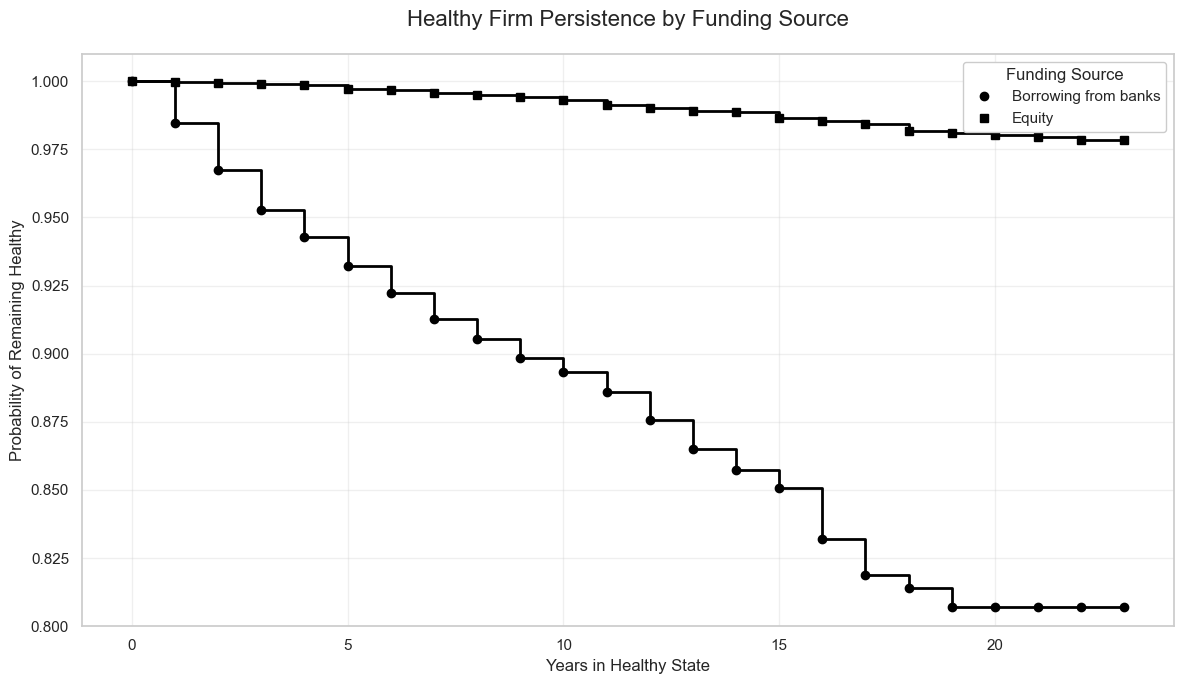

In [150]:
# Step 1: Prepare the data
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Binary indicator for healthy status
df['Healthy'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Healthy' else 0)

# Identify new healthy spells
df['Prev_Healthy'] = df.groupby('Company Name')['Healthy'].shift(1, fill_value=0)
df['New_Healthy_Spell'] = (df['Healthy'] == 1) & (df['Prev_Healthy'] == 0)

# Assign spell IDs
df['Healthy_Spell_ID'] = df.groupby('Company Name')['New_Healthy_Spell'].cumsum()
df['Healthy_Duration'] = df.groupby(['Company Name', 'Healthy_Spell_ID']).cumcount() + 1
df['Next_Healthy'] = df.groupby('Company Name')['Healthy'].shift(-1)

# Filter for healthy years
df_healthy = df[df['Healthy'] == 1].copy()
df_healthy['Event'] = (df_healthy['Next_Healthy'] == 0).fillna(0).astype(int)

# Step 2: Define sources of interest and marker mapping
focus_sources = ['Borrowing from banks', 'Equity']
markers = {'Borrowing from banks': 'o', 'Equity': 's'}
stats_summary = []

# Step 3: Plot setup
plt.figure(figsize=(12, 7))
ax = plt.gca()

for source in focus_sources:
    subset = df_healthy[df_healthy['Primary_Source_Category'] == source].dropna(subset=['Healthy_Duration', 'Event'])

    if not subset.empty:
        kmf = KaplanMeierFitter()
        kmf.fit(subset['Healthy_Duration'], event_observed=subset['Event'])

        durations = kmf.survival_function_.index
        surv_probs = kmf.survival_function_[kmf.survival_function_.columns[0]]

        # Plot black survival line
        ax.step(durations, surv_probs, where='post', color='black', linewidth=2)

        # Add source-specific markers
        ax.plot(durations, surv_probs, linestyle='', marker=markers[source], color='black', label=source)

        # Collect stats
        stats_summary.append({
            'Funding Source': source,
            'Firm-Years': len(subset),
            'Median Healthy Duration': kmf.median_survival_time_,
            '1-Year Survival': kmf.predict(1),
            '3-Year Survival': kmf.predict(3),
            '5-Year Survival': kmf.predict(5)
        })

# Step 4: Customize plot
ax.set_title('Healthy Firm Persistence by Funding Source', fontsize=16, pad=20)
ax.set_xlabel('Years in Healthy State', fontsize=12)
ax.set_ylabel('Probability of Remaining Healthy', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(title='Funding Source', loc='upper right', framealpha=1)
ax.set_ylim(0.8, 1.01)

plt.tight_layout()
plt.savefig('Images/healthy_firm_persistence_comparison.tiff', dpi=300, bbox_inches='tight')
plt.show()

In [151]:
# Split data into two groups
group_a = df_healthy[df_healthy['Primary_Source_Category'] == 'Borrowing from banks']
group_b = df_healthy[df_healthy['Primary_Source_Category'] == 'Equity']

# Run the log-rank test
results = logrank_test(
    group_a['Healthy_Duration'], group_b['Healthy_Duration'],  # Use 'Healthy_Duration' instead of 'Duration'
    event_observed_A=group_a['Event'],
    event_observed_B=group_b['Event']
)
# Create a DataFrame to store the results
logrank_results_df = pd.DataFrame({
    'Test Statistic': [results.test_statistic],
    'P-value': [results.p_value]
})

# Display the DataFrame
logrank_results_df.round(2)

,Test Statistic,P-value
0,1138.66,0.0


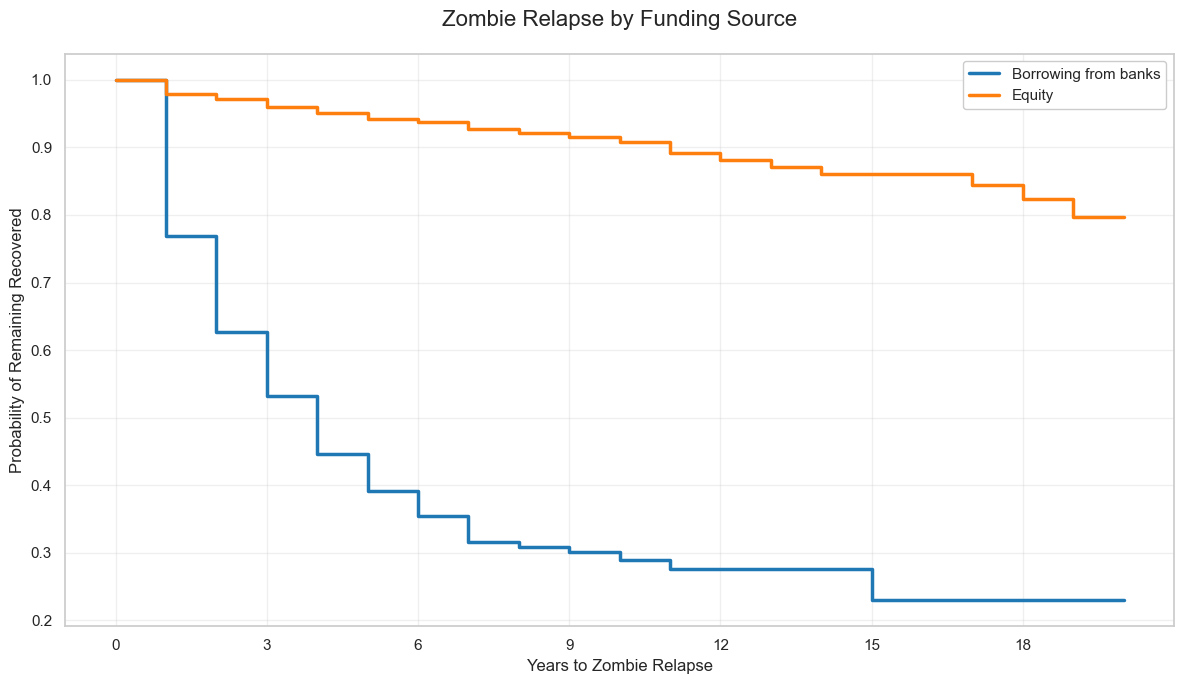

In [152]:
# Step 1: Prepare the data for Zombie relapse (from recovered state)
df = Analysis_data.copy().sort_values(['Company Name', 'Year'])
spell_records = []

for firm_id, group in df.groupby('Company Name'):
    group = group.reset_index(drop=True)
    recovery_start = None

    for i in range(1, len(group)):
        prev_status = group.loc[i-1, 'Zombie']
        curr_status = group.loc[i, 'Zombie']
        curr_year = group.loc[i, 'Year']
        primary_source = group.loc[i, 'Primary_Source_Category']  # Capture the primary source category

        # Detect recovery (Zombie = 0 after Zombie = 1)
        if prev_status == 1 and curr_status == 0:
            recovery_start = curr_year

        # Detect relapse (Zombie = 1 after recovery)
        elif recovery_start is not None and curr_status == 1:
            duration = curr_year - recovery_start
            spell_records.append({
                'Company Name': firm_id,
                'recovery_year': recovery_start,
                'relapse_year': curr_year,
                'duration_to_relapse': duration,
                'Event': 1,  # Relapse occurred
                'Primary_Source_Category': primary_source  # Add primary source category
            })
            recovery_start = None  # Reset for next recovery spell

    # Handle censored cases (recovered but no relapse by end of data)
    if recovery_start is not None:
        last_year = group.loc[len(group)-1, 'Year']
        duration = last_year - recovery_start
        spell_records.append({
            'Company Name': firm_id,
            'recovery_year': recovery_start,
            'relapse_year': None,
            'duration_to_relapse': duration,
            'Event': 0,  # Censored (no relapse observed)
            'Primary_Source_Category': primary_source  # Add primary source category
        })

# Convert the list of spells to DataFrame
spells_df = pd.DataFrame(spell_records)

# Step 2: Define specific sources of interest (only Borrowing from banks and Equity)
focus_sources = ['Borrowing from banks', 'Equity']
colors = ['#1f77b4', '#ff7f0e']  # Blue, Orange (you can adjust the colors as needed)

# Step 3: Kaplan-Meier Analysis and Plotting
plt.figure(figsize=(12, 7))
kmf = KaplanMeierFitter()
stats_summary = []

for i, source in enumerate(focus_sources):
    subset = spells_df[spells_df['Primary_Source_Category'] == source].dropna(subset=['duration_to_relapse', 'Event'])

    if not subset.empty:
        kmf.fit(subset['duration_to_relapse'], event_observed=subset['Event'], label=source)
        kmf.plot_survival_function(ax=plt.gca(), ci_show=False, color=colors[i], linewidth=2.5)

        # Capture the median relapse duration and survival at 1, 3, and 5 years
        median = kmf.median_survival_time_
        stats_summary.append({
            'Funding Source': source,
            'Firm-Years': len(subset),
            'Median Relapse Duration': median,
            '1-Year Survival': kmf.predict(1),
            '3-Year Survival': kmf.predict(3),
            '5-Year Survival': kmf.predict(5)
        })

# Step 4: Customize the plot
plt.title('Zombie Relapse by Funding Source', fontsize=16, pad=20)
plt.xlabel('Years to Zombie Relapse', fontsize=12)
plt.ylabel('Probability of Remaining Recovered', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', framealpha=1)

# Set integer ticks on the x-axis
max_duration = int(spells_df['duration_to_relapse'].max())
plt.xticks(range(0, max_duration + 1, 3))  # ticks every 3 years

# Adjusting y-axis limits
y_min, y_max = plt.gca().get_ylim()
plt.ylim(y_min, y_max)

plt.tight_layout()

# Save the plot
plt.savefig('Images/zombie_relapse_persistence_comparison.tiff', dpi=300, bbox_inches='tight')
plt.show()

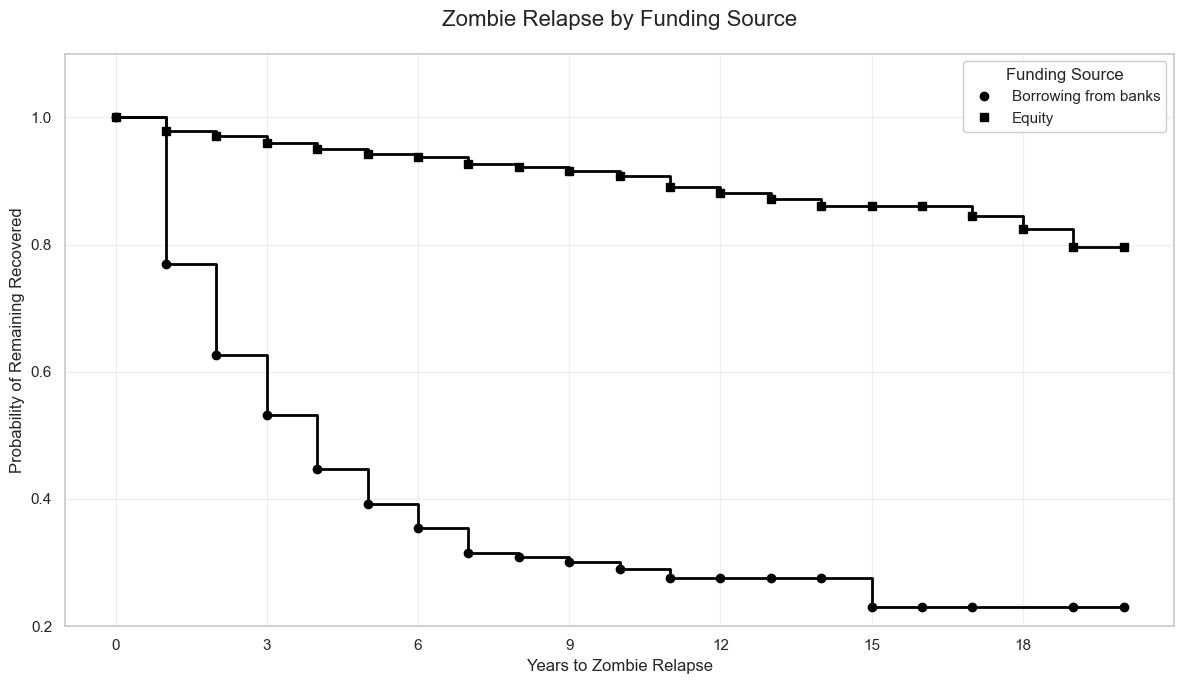

In [153]:
# Step 1: Prepare the data
df = Analysis_data.copy().sort_values(['Company Name', 'Year'])
spell_records = []

for firm_id, group in df.groupby('Company Name'):
    group = group.reset_index(drop=True)
    recovery_start = None

    for i in range(1, len(group)):
        prev_status = group.loc[i-1, 'Zombie']
        curr_status = group.loc[i, 'Zombie']
        curr_year = group.loc[i, 'Year']
        primary_source = group.loc[i, 'Primary_Source_Category']

        if prev_status == 1 and curr_status == 0:
            recovery_start = curr_year

        elif recovery_start is not None and curr_status == 1:
            duration = curr_year - recovery_start
            spell_records.append({
                'Company Name': firm_id,
                'recovery_year': recovery_start,
                'relapse_year': curr_year,
                'duration_to_relapse': duration,
                'Event': 1,
                'Primary_Source_Category': primary_source
            })
            recovery_start = None

    if recovery_start is not None:
        last_year = group.loc[len(group)-1, 'Year']
        duration = last_year - recovery_start
        spell_records.append({
            'Company Name': firm_id,
            'recovery_year': recovery_start,
            'relapse_year': None,
            'duration_to_relapse': duration,
            'Event': 0,
            'Primary_Source_Category': primary_source
        })

# Step 2: Convert and filter
spells_df = pd.DataFrame(spell_records)
focus_sources = ['Borrowing from banks', 'Equity']
markers = {'Borrowing from banks': 'o', 'Equity': 's'}
stats_summary = []

# Step 3: Plot setup
plt.figure(figsize=(12, 7))
ax = plt.gca()

for source in focus_sources:
    subset = spells_df[spells_df['Primary_Source_Category'] == source].dropna(subset=['duration_to_relapse', 'Event'])

    if not subset.empty:
        kmf = KaplanMeierFitter()
        kmf.fit(subset['duration_to_relapse'], event_observed=subset['Event'])

        durations = kmf.survival_function_.index
        surv_probs = kmf.survival_function_[kmf.survival_function_.columns[0]]

        # Plot black line for survival
        ax.step(durations, surv_probs, where='post', color='black', linewidth=2)

        # Add markers
        ax.plot(durations, surv_probs, linestyle='', marker=markers[source], color='black', label=source)

        stats_summary.append({
            'Funding Source': source,
            'Firm-Years': len(subset),
            'Median Relapse Duration': kmf.median_survival_time_,
            '1-Year Survival': kmf.predict(1),
            '3-Year Survival': kmf.predict(3),
            '5-Year Survival': kmf.predict(5)
        })

# Step 4: Final plot formatting
ax.set_title('Zombie Relapse by Funding Source', fontsize=16, pad=20)
ax.set_xlabel('Years to Zombie Relapse', fontsize=12)
ax.set_ylabel('Probability of Remaining Recovered', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(title='Funding Source', loc='upper right', framealpha=1)

# X-axis: integer ticks every 3 years
max_duration = int(spells_df['duration_to_relapse'].max())
ax.set_xticks(range(0, max_duration + 1, 3))

# Y-axis: from 0 to 1 (clean bounds)
ax.set_ylim(0.2, 1.1)

plt.tight_layout()
plt.savefig('Images/zombie_relapse_persistence_comparison.tiff', dpi=300, bbox_inches='tight')
plt.show()

In [154]:
# Split data into two groups
group_a = spells_df[spells_df['Primary_Source_Category'] == 'Borrowing from banks']
group_b = spells_df[spells_df['Primary_Source_Category'] == 'Equity']

# Run the log-rank test
results = logrank_test(
    group_a['duration_to_relapse'], group_b['duration_to_relapse'],  # Use 'Healthy_Duration' instead of 'Duration'
    event_observed_A=group_a['Event'],
    event_observed_B=group_b['Event']
)
# Create a DataFrame to store the results
logrank_results_df = pd.DataFrame({
    'Test Statistic': [results.test_statistic],
    'P-value': [results.p_value]
})

# Display the DataFrame
logrank_results_df.round(2)

,Test Statistic,P-value
0,230.01,0.0


## Data Preparation for Logit Model

In [155]:
Analysis_data['Zombie'] = Analysis_data['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)

In [156]:
primary_sources_of_interest = ['Borrowing from banks', 'Equity']

# Step 3: Create dummy variables for 'Borrowing from banks', 'Inter-corporate loans', and 'Equity'
Analysis_data['Primary_Borrowing_from_banks'] = Analysis_data['Primary_Source_Category'].apply(lambda x: 1 if x == 'Borrowing from banks' else 0)
Analysis_data['Primary_Equity'] = Analysis_data['Primary_Source_Category'].apply(lambda x: 1 if x == 'Equity' else 0)

# Step 4: Create the 'Primary_Source_Others' column for all sources other than the ones specified
Analysis_data['Primary_Source_Others'] = Analysis_data['Primary_Source_Category'].apply(
    lambda x: 1 if x not in primary_sources_of_interest else 0)

# Step 5: Check the new columns
Analysis_data[['Primary_Source_Category', 'Primary_Borrowing_from_banks', 'Primary_Equity', 'Primary_Source_Others']].head()
Analysis_data['Log_TA'] = np.log(Analysis_data['Total Assets'])

## Cox PH model for Continuation

In [157]:
# Step 1: Prepare data
df = Analysis_data.copy()
df = df.sort_values(['Company Name', 'Year']).reset_index(drop=True)
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount() + 1
df['Next_Zombie'] = df.groupby('Company Name')['Zombie'].shift(-1)
df['Event'] = ((df['Prev_Zombie'] == 1) & (df['Zombie'] == 1)).astype(int)
df['duration'] = df.groupby(['Company Name', 'Spell_ID'])['Duration'].transform('max')
df = df[df['Zombie'] == 1].copy()

# Create the interaction term
df['Group_Listed_Interaction'] = df['Group Dummy'] * df['listed firm']

# Drop rows with missing values in required columns including new interaction variable
df = df.dropna(subset=['Primary_Borrowing_from_banks', 'Primary_Equity', 'Number of Banks',
                       'Promoter pledging', 'Subsidized Credit', 'duration', 'Event',
                       'Group Dummy', 'listed firm', 'Group_Listed_Interaction'])

# Fit the Cox proportional hazards model including the interaction variable
cph = CoxPHFitter()
cph.fit(df[['duration',
            'Primary_Borrowing_from_banks',
            'Primary_Equity',
            'Number of Banks',
            'Subsidized Credit',
            'Promoter pledging',
            'Group Dummy',
            'listed firm',
            'Group_Listed_Interaction',
            'Event',
            'Company Name']],
        duration_col='duration',
        event_col='Event',
        cluster_col='Company Name')

# Print the summary
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 11424 total observations, 8853 right-censored observations>
             duration col = 'duration'
                event col = 'Event'
              cluster col = 'Company Name'
          robust variance = True
      baseline estimation = breslow
   number of observations = 11424
number of events observed = 2571
   partial log-likelihood = -21218.13
         time fit was run = 2025-06-13 08:12:32 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
Primary_Borrowing_from_banks  0.67      1.95      0.05            0.58            0.76                1.78                2.13
Primary_Equity               -0.46      0.63      0.33           -1.11            0.20                0.33                1.22
Number of Banks               0.02      1.02      0.01            0.01            0.04                1.01                1.04
Subsidized Credit             0.05      1.05      0.04           -0.04            0.13                0.96                1.14
Promoter pledging             0.01      1.01      0.00            0.01            0.02                1.01                1.02
Group Dummy                   0.02      1.02      0.06           -0.09            0.13                0.91                1.14
listed firm                   0.11      1.12      0.07           -0.02            0.25                0.98                1.29
Group_Listed_Interaction     -0.32      0.73      0.10           -0.52           -0.12                0.59                0.89

                              cmp to     z      p  -log2(p)
covariate                                                  
Primary_Borrowing_from_banks    0.00 14.33 <0.005    152.28
Primary_Equity                  0.00 -1.37   0.17      2.56
Number of Banks                 0.00  2.61   0.01      6.80
Subsidized Credit               0.00  1.09   0.28      1.85
Promoter pledging               0.00  6.54 <0.005     33.95
Group Dummy                     0.00  0.37   0.71      0.49
listed firm                     0.00  1.61   0.11      3.23
Group_Listed_Interaction        0.00 -3.13 <0.005      9.14
---
Concordance = 0.58
Partial AIC = 42452.25
log-likelihood ratio test = 327.13 on 8 df
-log2(p) of ll-ratio test = 216.47

In [158]:
# List of covariates used in the model
covariates = cph.params_.index.tolist()

# Prepare test dataframe with the exact covariates
test_df = df[covariates + ['duration', 'Event', 'Company Name']]  # Include duration, event, cluster_col

# Run the proportional hazards test
results = proportional_hazard_test(cph, test_df)

# Print summary
results.print_summary()

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 11424 total observations, 8853 right-censored observations>
         test_name = proportional_hazard_test

---
                              test_statistic      p  -log2(p)
Group Dummy                             0.42   0.52      0.95
Group_Listed_Interaction                2.41   0.12      3.06
Number of Banks                         9.95 <0.005      9.28
Primary_Borrowing_from_banks            7.22   0.01      7.11
Primary_Equity                          2.47   0.12      3.10
Promoter pledging                       2.72   0.10      3.34
Subsidized Credit                       0.24   0.62      0.68
listed firm                             4.12   0.04      4.56

In [159]:
results = proportional_hazard_test(cph, test_df)  # cph is your fitted model
ph_summary = results.summary

# Calculate global chi-squared test statistic and p-value
global_test_stat = ph_summary['test_statistic'].sum()
df = len(ph_summary)
global_p = 1 - chi2.cdf(global_test_stat, df)

print(f"Global test statistic: {global_test_stat:.2f}")
print(f"Global p-value: {global_p:.5f}")

Global test statistic: 29.55
Global p-value: 0.00025


## Cox pH for Recovery

In [160]:
df = Analysis_data.copy()
df = df.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)

# Define Zombie status
df['Zombie'] = df['Semi_Restricted'].apply(lambda x: 1 if x == 'Zombie' else 0)
df['Prev_Zombie'] = df.groupby('Company Name')['Zombie'].shift(1, fill_value=0)
df['New_Spell'] = (df['Zombie'] == 1) & (df['Prev_Zombie'] == 0)
df['Spell_ID'] = df.groupby('Company Name')['New_Spell'].cumsum()
df['Duration'] = df.groupby(['Company Name', 'Spell_ID']).cumcount()
df['Event'] = ((df['Zombie'] == 0) & (df['Prev_Zombie'] == 1)).astype(int)

# Only include companies that were previously zombies
zombie_firms = df[df['Zombie'] == 1]['Company Name'].unique()
df = df[df['Company Name'].isin(zombie_firms) & (df['Prev_Zombie'] == 1)].copy()

# Create 'duration' column
df['duration'] = df.groupby(['Company Name', 'Spell_ID'])['Duration'].transform('max')

# ---- ADD INTERACTION TERM ----
# Make sure 'Listed firm' is in the dataframe and numeric (1 for listed, 0 for unlisted)
df['Group_Listed_Interaction'] = df['Group Dummy'] * df['listed firm']

# Drop rows with missing values in necessary columns
df_recovery = df.dropna(subset=[
    'Primary_Borrowing_from_banks', 'Primary_Equity', 'Number of Banks', 
    'Promoter pledging', 'Subsidized Credit', 'duration', 'Event', 
    'Group Dummy', 'listed firm', 'Group_Listed_Interaction'
])

# Fit Cox model with interaction term
cph = CoxPHFitter()
cph.fit(df_recovery[[
    'duration', 'Event', 'Primary_Borrowing_from_banks', 'Primary_Equity', 
    'Number of Banks', 'Promoter pledging', 'Subsidized Credit', 
    'Group Dummy', 'listed firm', 'Group_Listed_Interaction', 'Company Name'
]], duration_col='duration', event_col='Event', cluster_col='Company Name')

# Print the summary
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 10844 total observations, 2571 right-censored observations>
             duration col = 'duration'
                event col = 'Event'
              cluster col = 'Company Name'
          robust variance = True
      baseline estimation = breslow
   number of observations = 10844
number of events observed = 8273
   partial log-likelihood = -71640.24
         time fit was run = 2025-06-13 08:12:37 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
Primary_Borrowing_from_banks -0.23      0.79      0.04           -0.30           -0.16                0.74                0.85
Primary_Equity                0.32      1.37      0.19           -0.06            0.70                0.94                2.01
Number of Banks              -0.03      0.97      0.01           -0.05           -0.01                0.96                0.99
Promoter pledging            -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
Subsidized Credit             0.05      1.05      0.03           -0.01            0.11                0.99                1.11
Group Dummy                  -0.05      0.95      0.04           -0.13            0.03                0.88                1.03
listed firm                  -0.22      0.80      0.06           -0.35           -0.09                0.71                0.91
Group_Listed_Interaction      0.12      1.13      0.09           -0.06            0.30                0.94                1.35

                              cmp to     z      p  -log2(p)
covariate                                                  
Primary_Borrowing_from_banks    0.00 -6.35 <0.005     32.15
Primary_Equity                  0.00  1.64   0.10      3.29
Number of Banks                 0.00 -3.50 <0.005     11.06
Promoter pledging               0.00 -3.15 <0.005      9.26
Subsidized Credit               0.00  1.58   0.11      3.14
Group Dummy                     0.00 -1.15   0.25      2.01
listed firm                     0.00 -3.42 <0.005     10.63
Group_Listed_Interaction        0.00  1.30   0.19      2.37
---
Concordance = 0.58
Partial AIC = 143296.48
log-likelihood ratio test = 327.72 on 8 df
-log2(p) of ll-ratio test = 216.89

In [161]:
# Prepare the test dataset by selecting only the columns used in the model (duration, event, and covariates)
test_df = df_recovery[['duration', 'Event', 'Primary_Borrowing_from_banks', 'Primary_Equity', 
    'Number of Banks', 'Promoter pledging', 'Subsidized Credit', 
    'Group Dummy', 'listed firm', 'Group_Listed_Interaction', 'Company Name']]

# Run the proportional hazards test with the relevant dataset
results = proportional_hazard_test(cph, test_df, time_transform='rank')

# Print the summary of the test results
results.print_summary()

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 10844 total observations, 2571 right-censored observations>
         test_name = proportional_hazard_test

---
                              test_statistic      p  -log2(p)
Group Dummy                             2.34   0.13      2.99
Group_Listed_Interaction                0.23   0.63      0.66
Number of Banks                         0.74   0.39      1.36
Primary_Borrowing_from_banks           13.99 <0.005     12.41
Primary_Equity                          2.89   0.09      3.49
Promoter pledging                       2.40   0.12      3.05
Subsidized Credit                       6.09   0.01      6.20
listed firm                             0.18   0.67      0.57

In [162]:
results = proportional_hazard_test(cph, test_df)  # cph is your fitted model
ph_summary = results.summary

# Calculate global chi-squared test statistic and p-value
global_test_stat = ph_summary['test_statistic'].sum()
df = len(ph_summary)
global_p = 1 - chi2.cdf(global_test_stat, df)

print(f"Global test statistic: {global_test_stat:.2f}")
print(f"Global p-value: {global_p:.5f}")

Global test statistic: 28.86
Global p-value: 0.00034


## Proportional Hazard for Relapse

In [163]:
# Step 1: Prepare the data for Zombie relapse (from recovered state)
df = Analysis_data.copy().sort_values(['Company Name', 'Year'])
spell_records = []

for firm_id, group in df.groupby('Company Name'):
    group = group.reset_index(drop=True)
    recovery_start = None

    for i in range(1, len(group)):
        prev_status = group.loc[i-1, 'Zombie']
        curr_status = group.loc[i, 'Zombie']
        curr_year = group.loc[i, 'Year']
        primary_source = group.loc[i, 'Primary_Source_Category']
        number_of_banks = group.loc[i, 'Number of Banks']
        promoter_pledging = group.loc[i, 'Promoter pledging']
        subsidized_credit = group.loc[i, 'Subsidized Credit']
        group_dummy = group.loc[i, 'Group Dummy']
        listed_firm = group.loc[i, 'listed firm']

        if prev_status == 1 and curr_status == 0:
            recovery_start = curr_year

        elif recovery_start is not None and curr_status == 1:
            duration = curr_year - recovery_start
            spell_records.append({
                'Company Name': firm_id,
                'recovery_year': recovery_start,
                'relapse_year': curr_year,
                'duration_to_relapse': duration,
                'Event': 1,
                'Primary_Source_Category': primary_source,
                'Number of Banks': number_of_banks,
                'Promoter pledging': promoter_pledging,
                'Group Dummy': group_dummy,
                'Subsidized Credit': subsidized_credit,
                'listed firm': listed_firm
            })
            recovery_start = None

    if recovery_start is not None:
        last_year = group.loc[len(group)-1, 'Year']
        duration = last_year - recovery_start
        primary_source = group.loc[len(group)-1, 'Primary_Source_Category']
        number_of_banks = group.loc[len(group)-1, 'Number of Banks']
        promoter_pledging = group.loc[len(group)-1, 'Promoter pledging']
        subsidized_credit = group.loc[len(group)-1, 'Subsidized Credit']
        group_dummy = group.loc[len(group)-1, 'Group Dummy']
        listed_firm = group.loc[len(group)-1, 'listed firm']

        spell_records.append({
            'Company Name': firm_id,
            'recovery_year': recovery_start,
            'relapse_year': None,
            'duration_to_relapse': duration,
            'Event': 0,
            'Primary_Source_Category': primary_source,
            'Number of Banks': number_of_banks,
            'Promoter pledging': promoter_pledging,
            'Group Dummy': group_dummy,
            'Subsidized Credit': subsidized_credit,
            'listed firm': listed_firm
        })

# Convert to DataFrame
spells_df = pd.DataFrame(spell_records)

# Create dummy variables for funding source
spells_df['Primary_Borrowing_from_banks'] = (spells_df['Primary_Source_Category'] == 'Borrowing from banks').astype(int)
spells_df['Primary_Equity'] = (spells_df['Primary_Source_Category'] == 'Equity').astype(int)

# Create interaction term
spells_df['Group_Listed_Interaction'] = spells_df['Group Dummy'] * spells_df['listed firm']

# Drop rows with missing values
spells_df = spells_df.dropna(subset=[
    'duration_to_relapse', 'Event', 'Primary_Borrowing_from_banks', 'Primary_Equity',
    'Number of Banks', 'Promoter pledging', 'Subsidized Credit', 'Group Dummy', 
    'listed firm', 'Group_Listed_Interaction'
])

# Step 4: Fit the Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(
    spells_df[[
        'duration_to_relapse', 'Event', 'Primary_Borrowing_from_banks', 'Primary_Equity',
        'Number of Banks', 'Promoter pledging', 'Subsidized Credit', 'Group Dummy',
        'listed firm', 'Group_Listed_Interaction', 'Company Name'
    ]],
    duration_col='duration_to_relapse',
    event_col='Event',
    cluster_col='Company Name'
)

# Step 5: View the results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 8273 total observations, 5665 right-censored observations>
             duration col = 'duration_to_relapse'
                event col = 'Event'
              cluster col = 'Company Name'
          robust variance = True
      baseline estimation = breslow
   number of observations = 8273
number of events observed = 2608
   partial log-likelihood = -21293.40
         time fit was run = 2025-06-13 08:13:03 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
Primary_Borrowing_from_banks  0.65      1.91      0.05            0.55            0.75                1.73                2.12
Primary_Equity               -2.07      0.13      0.18           -2.44           -1.71                0.09                0.18
Number of Banks               0.01      1.01      0.01           -0.00            0.03                1.00                1.03
Promoter pledging            -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
Subsidized Credit             0.16      1.17      0.04            0.08            0.24                1.08                1.27
Group Dummy                   0.21      1.23      0.05            0.10            0.32                1.11                1.37
listed firm                   0.43      1.53      0.07            0.29            0.56                1.34                1.76
Group_Listed_Interaction     -0.25      0.78      0.10           -0.45           -0.05                0.64                0.95

                              cmp to      z      p  -log2(p)
covariate                                                   
Primary_Borrowing_from_banks    0.00  12.35 <0.005    113.96
Primary_Equity                  0.00 -11.25 <0.005     95.16
Number of Banks                 0.00   1.43   0.15      2.70
Promoter pledging               0.00  -1.91   0.06      4.15
Subsidized Credit               0.00   3.92 <0.005     13.47
Group Dummy                     0.00   3.87 <0.005     13.18
listed firm                     0.00   6.16 <0.005     30.31
Group_Listed_Interaction        0.00  -2.51   0.01      6.37
---
Concordance = 0.60
Partial AIC = 42602.81
log-likelihood ratio test = 447.67 on 8 df
-log2(p) of ll-ratio test = 302.07

In [164]:
# Use only the columns used to fit the model
test_df = spells_df[['duration_to_relapse', 'Event', 'Primary_Borrowing_from_banks', 'Primary_Equity',
        'Number of Banks', 'Promoter pledging', 'Subsidized Credit', 'Group Dummy',
        'listed firm', 'Group_Listed_Interaction', 'Company Name']]

results = proportional_hazard_test(cph, test_df, time_transform='rank')
results.print_summary()

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 8273 total observations, 5665 right-censored observations>
         test_name = proportional_hazard_test

---
                              test_statistic    p  -log2(p)
Group Dummy                             0.16 0.68      0.55
Group_Listed_Interaction                0.11 0.74      0.44
Number of Banks                         0.04 0.85      0.24
Primary_Borrowing_from_banks            0.56 0.45      1.14
Primary_Equity                          0.90 0.34      1.55
Promoter pledging                       5.68 0.02      5.87
Subsidized Credit                       5.75 0.02      5.92
listed firm                             0.02 0.88      0.19

In [165]:
# Run PH test
results = proportional_hazard_test(cph, test_df)  # cph is your fitted model
ph_summary = results.summary

# Calculate global chi-squared test statistic and p-value
global_test_stat = ph_summary['test_statistic'].sum()
df = len(ph_summary)
global_p = 1 - chi2.cdf(global_test_stat, df)

print(f"Global test statistic: {global_test_stat:.2f}")
print(f"Global p-value: {global_p:.5f}")

Global test statistic: 13.23
Global p-value: 0.10423


In [166]:
Analysis_data[Analysis_data['Year']>2001].shape

(264988, 45)

In [167]:
# Sort for lag calculation
Analysis_data = Analysis_data.sort_values(by=['Company Name', 'Year'])

# Calculate lagged Zombie status to detect entry and exit
Analysis_data['Zombie_lag'] = Analysis_data.groupby('Company Name')['Zombie'].shift(1)

# Define entries and exits
Analysis_data['Entry'] = ((Analysis_data['Zombie'] == 1) & (Analysis_data['Zombie_lag'] == 0)).astype(int)
# First, keep only firm-years where both current and previous year exist
Analysis_data['Exit'] = (
    (Analysis_data['Zombie'] == 0) &
    (Analysis_data['Zombie_lag'] == 1) &
    (Analysis_data['Zombie_lag'].notna())
).astype(int)

# Create a complete range of years from min to max
all_years = pd.Series(range(Analysis_data['Year'].min()+1, Analysis_data['Year'].max() + 1))

# Group by year to calculate rates
entry_rate = Analysis_data.groupby('Year')['Entry'].mean()
exit_rate = -Analysis_data.groupby('Year')['Exit'].mean()  # negative for plotting

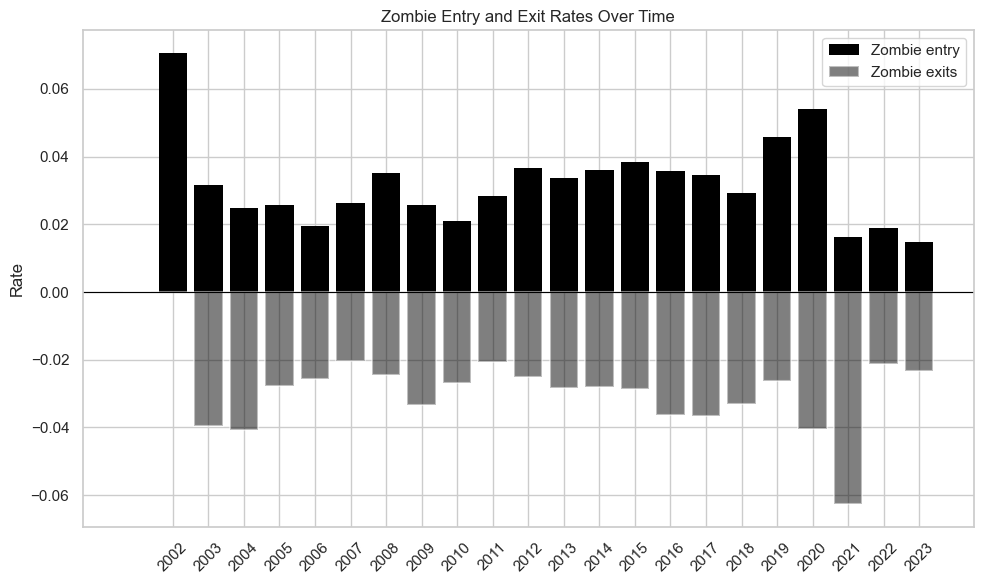

In [168]:
plt.figure(figsize=(10,6))

# Zombie entries: solid black bars with no edge, full opacity
plt.bar(entry_rate.index, entry_rate, color='black', label='Zombie entry', edgecolor='black', linewidth=0, alpha=1.0)

# Zombie exits: black bars with white edges and lower opacity
plt.bar(exit_rate.index, exit_rate, color='black', label='Zombie exits', edgecolor='white', linewidth=1.5, alpha=0.5)

plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(all_years, rotation=45)
plt.legend()
plt.ylabel("Rate")
plt.title("Zombie Entry and Exit Rates Over Time")
plt.savefig('Images/Zombie_Entry_and_Exit_over_time.tiff', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [169]:
len(Analysis_data)

269320

In [170]:
len(Analysis_data[Analysis_data['listed firm']==1])

48810

In [171]:
Analysis_data['Company Name'].nunique()

23637

In [172]:
df = Analysis_data.copy()
# Assume df has columns: 'Company Name', 'Year', 'Zombie'
df = df.sort_values(['Company Name', 'Year'])

years = sorted(df['Year'].unique())
results = []

for T in years[1:]:  # start from second year (can't look "before" first year)
    df_before_T = df[df['Year'] < T]
    df_T = df[df['Year'] == T]

    recovered_firms = set()

    for company, group in df_before_T.groupby('Company Name'):
        statuses = group['Zombie'].tolist()
        # Was zombie at least once, and then became healthy (0)
        if 1 in statuses:
            for i in range(1, len(statuses)):
                if statuses[i - 1] == 1 and statuses[i] == 0:
                    recovered_firms.add(company)
                    break

    re_zombie_count = df_T[(df_T['Company Name'].isin(recovered_firms)) & (df_T['Zombie'] == 1)]['Company Name'].nunique()
    recovered_total = len(recovered_firms)

    never_zombie_before = set(df_before_T[df_before_T['Zombie'] == 0]['Company Name']) - set(df_before_T[df_before_T['Zombie'] == 1]['Company Name'])
    new_zombie_count = df_T[(df_T['Company Name'].isin(never_zombie_before)) & (df_T['Zombie'] == 1)]['Company Name'].nunique()
    never_zombie_total = len(never_zombie_before)

    results.append({
        'Year': T,
        'P_rezombie': (re_zombie_count / recovered_total * 100) if recovered_total > 0 else None,
        'P_new_zombie': (new_zombie_count / never_zombie_total * 100) if never_zombie_total > 0 else None,
        'Recovered_Count': recovered_total,
        'ReZombified_Count': re_zombie_count,
        'New_Zombie_Count': new_zombie_count,
        'Never_Zombie_Count': never_zombie_total
    })

prob_df = pd.DataFrame(results)

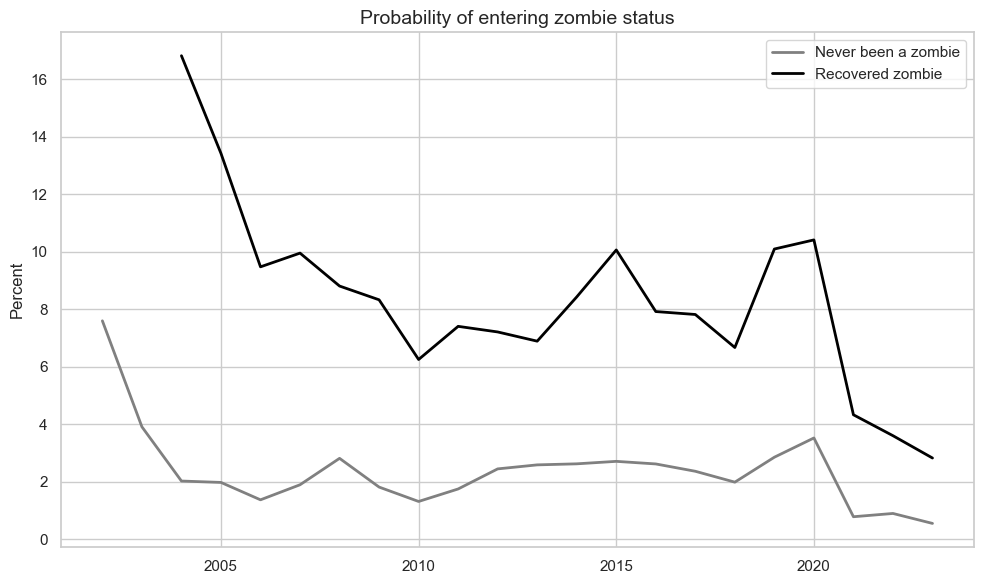

In [173]:
plt.figure(figsize=(10, 6))

# Plot lines
sns.lineplot(data=prob_df, x='Year', y='P_new_zombie', label='Never been a zombie', color='grey', linewidth=2)
sns.lineplot(data=prob_df, x='Year', y='P_rezombie', label='Recovered zombie', color='black', linewidth=2)

# Labels and styling
plt.title("Probability of entering zombie status", fontsize=14)
plt.ylabel("Percent")
plt.xlabel("")
plt.legend()
plt.grid(True)
plt.savefig('Images/Probability of Entering Zombie status.tiff', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

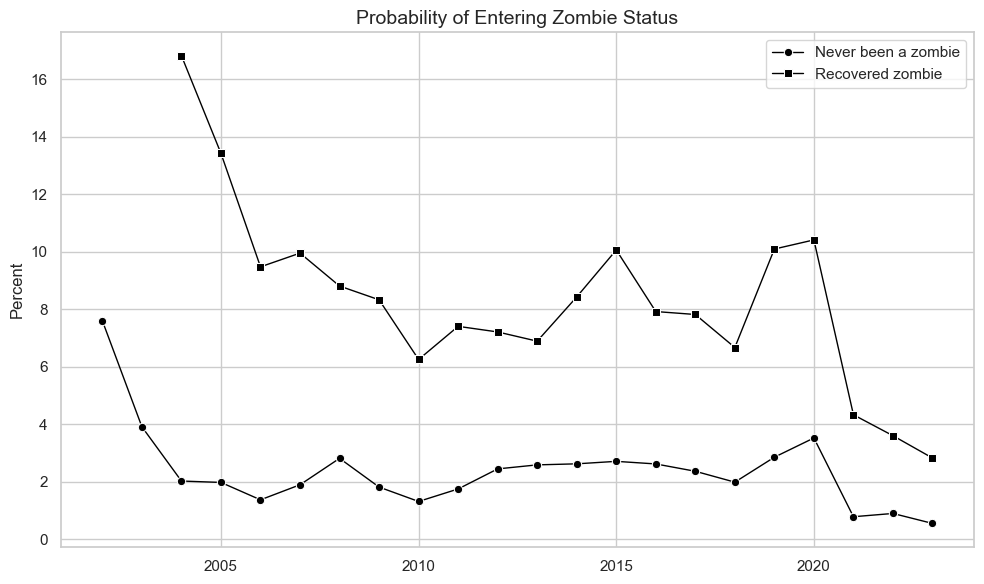

In [174]:
plt.figure(figsize=(10, 6))

# Lineplot with black and gray, plus distinct markers
sns.lineplot(data=prob_df, x='Year', y='P_new_zombie', label='Never been a zombie', color='black', linewidth=1, marker='o')
sns.lineplot(data=prob_df, x='Year', y='P_rezombie', label='Recovered zombie', color='black', linewidth=1, marker='s')

plt.title("Probability of Entering Zombie Status", fontsize=14)
plt.ylabel("Percent")
plt.xlabel("")
plt.legend()
plt.grid(True)
plt.savefig('Images/Probability_of_Entering_Zombie_Status_bw.tiff', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


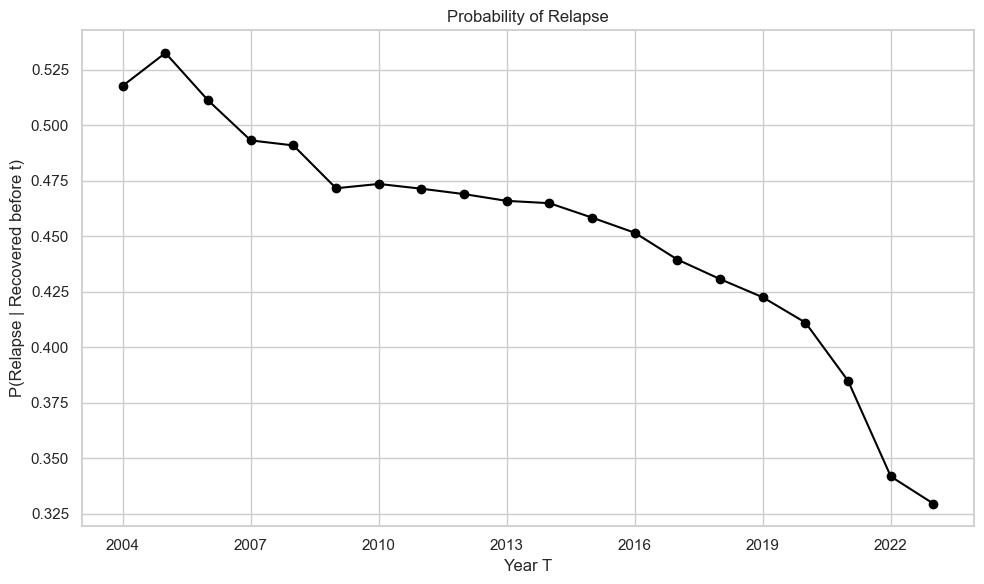

In [175]:
# Assuming spells_df already exists
years = sorted(spells_df['recovery_year'].dropna().unique())
probabilities = []

for T in years:
    subset = spells_df[spells_df['recovery_year'] < T]
    total = len(subset)
    if total > 0:
        relapsed = (subset['Event'] == 1).sum()
        prob = relapsed / total
        probabilities.append({'Year': T, 'Relapse_Probability': prob})
    else:
        probabilities.append({'Year': T, 'Relapse_Probability': None})

# Convert to DataFrame
prob_df = pd.DataFrame(probabilities)
# Ensure Year is integer
prob_df['Year'] = prob_df['Year'].astype(int)
prob_df = prob_df[prob_df['Year']>2003]

min_year = prob_df['Year'].min()
max_year = prob_df['Year'].max()

plt.figure(figsize=(10, 6))
plt.plot(prob_df['Year'], prob_df['Relapse_Probability'], marker='o', linestyle='-',color='black')
plt.title('Probability of Relapse')
plt.xlabel('Year T')
plt.ylabel('P(Relapse | Recovered before t)')
plt.grid(True)

# Set x-axis ticks every 3 years
plt.xticks(range(min_year, max_year + 1, 3))

plt.tight_layout()
plt.savefig('Images/relapse Probability.tiff', dpi=1000, bbox_inches='tight')
plt.show()

In [176]:
# Analysis_data['Asset Disposal'].fillna(0,inplace=True)
# Analysis_data.loc[Analysis_data['listed firm'] == 0, 'ROE'] = Analysis_data.loc[Analysis_data['listed firm'] == 0, 'ROE'].fillna(0)
# Analysis_data['log Number of Banks'] = np.log(1+Analysis_data['Number of Banks'])
# Analysis_data['High Banking rel'] = (Analysis_data['Number of Banks'] > 1).astype(int)
# Analysis_data = Analysis_data.sort_values(by=['Company Name', 'Year']).reset_index(drop=True)
# Analysis_data[Analysis_data['Year']>2001].to_excel('data for logit regression.xlsx',index=False)